# **Proyecto STS: Similitud Semántica de Textos**

## Instalación y carga de datos

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Instalación de las librerías

Primro, Instalamos las librerías que necesitaremos.
- `datasets`: Para cargar el dataset STS-B desde Hugging Face.
- `transformers`: Para cargar los modelos base (lo usaremos en Z2).
- `sentence-transformers`: Para los modelos de embeddings (lo usaremos en Z1).
- `evaluate`: Para calcular la métrica de Correlación de Pearson.
- `accelerate` y `transformers[torch]`*texto en cursiva* son necesarios para usar el Trainer de H.

In [2]:
!pip install datasets -q transformers sentence-transformers evaluate
!pip install accelerate -U
!pip install sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.6 MB/s eta 0:00:00


### Carga de librerías

Ahora importamos las librerías que acabamos de instalar.

In [3]:
from datasets import load_dataset, concatenate_datasets
import evaluate
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sentence_transformers import SentenceTransformer, InputExample, losses, evaluation, util
from torch.utils.data import DataLoader
import math
import os
import joblib
from transformers import EarlyStoppingCallback
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import shutil

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\n========================================================")
if device == "cuda":
    gpu_name = torch.cuda.get_device_name(0)
    print(f" GPU DETECTADA: {gpu_name}")
else:
    print(" ¡ATENCIÓN! Estás usando CPU.")
print("========================================================\n")


 GPU DETECTADA: Tesla T4



### Carpeta para guardar los modelos que creemos

In [5]:
base_path = "/content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos"
os.makedirs(base_path, exist_ok=True)

### Carga y análisis del dataset (mteb/stsbenchmark-sts)

Cargamos el dataset 'mteb/stsbenchmark-sts' (especificando la versión en inglés) y miramos
su estructura.
Este dataset ya viene dividido en 'train', 'validation' y 'test'.

In [6]:
dataset = load_dataset("mteb/stsbenchmark-sts", download_mode="force_redownload")
print("\nEstructura del Dataset:")
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.jsonl.gz:   0%|          | 0.00/278k [00:00<?, ?B/s]

validation.jsonl.gz:   0%|          | 0.00/86.4k [00:00<?, ?B/s]

test.jsonl.gz:   0%|          | 0.00/63.2k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5749 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1379 [00:00<?, ? examples/s]


Estructura del Dataset:
DatasetDict({
    train: Dataset({
        features: ['split', 'genre', 'dataset', 'year', 'sid', 'score', 'sentence1', 'sentence2'],
        num_rows: 5749
    })
    validation: Dataset({
        features: ['split', 'genre', 'dataset', 'year', 'sid', 'score', 'sentence1', 'sentence2'],
        num_rows: 1500
    })
    test: Dataset({
        features: ['split', 'genre', 'dataset', 'year', 'sid', 'score', 'sentence1', 'sentence2'],
        num_rows: 1379
    })
})


El conjunto de datos está dividido en tres particiones o splits:

- train (Entrenamiento): Contiene 5749 pares de oraciones. Esta partición se utiliza para entrenar nuestros modelos.

- validation (Validación): Contiene 1500 pares de oraciones. Esta partición se usa para monitorizar el proceso de entrenamiento y ajustar los hiperparámetros.

- test (Prueba): Contiene 1379 pares de oraciones. Esta partición se reserva exclusivamente para la evaluación final de los modelos.

De cada ejemplo en estas particiones, la parte de su estructura que nos interesa es:

- sentence1: La primera oración del par (en formato de texto).

- sentence2: La segunda oración del par (en formato de texto).

- score: La puntuación de similitud semántica asignada por anotadores humanos. Esta puntuación es un valor numérico (un float) que va de 0.0 a 5.0, donde 0.0 significa que las oraciones son completamente diferentes y 5.0 que son semánticamente equivalentes .

Rango y media de las puntuaciones ('score'):

(Convertimos los datos en un DataFrame de pandas para facilitar los cálculos)

In [7]:
train_df = pd.DataFrame(dataset['train'])
validation_df = pd.DataFrame(dataset['validation'])
test_df = pd.DataFrame(dataset['test'])

# Combinamos todos los scores para un análisis general
all_scores = pd.concat([train_df['score'], validation_df['score'], test_df['score']])

print("\n--- Estadísticas de 'score' (Todos los datos) ---")
print(all_scores.describe())

print("\nEstadísticas detalladas (train):")
print(train_df['score'].describe())

print("\n--- Ejemplo de datos (Train) ---")
# Mostramos los primeros 5 ejemplos para ver cómo son
print(train_df.head())


--- Estadísticas de 'score' (Todos los datos) ---
count    8628.000000
mean        2.627518
std         1.485762
min         0.000000
25%         1.400000
50%         2.800000
75%         3.800000
max         5.000000
Name: score, dtype: float64

Estadísticas detalladas (train):
count    5749.000000
mean        2.700999
std         1.464398
min         0.000000
25%         1.500000
50%         3.000000
75%         3.800000
max         5.000000
Name: score, dtype: float64

--- Ejemplo de datos (Train) ---
   split          genre dataset      year   sid  score  \
0  train  main-captions  MSRvid  2012test  0001   5.00   
1  train  main-captions  MSRvid  2012test  0004   3.80   
2  train  main-captions  MSRvid  2012test  0005   3.80   
3  train  main-captions  MSRvid  2012test  0006   2.60   
4  train  main-captions  MSRvid  2012test  0009   4.25   

                                       sentence1  \
0                         A plane is taking off.   
1                A man is playing a 

### Carga de la métrica de evaluación

Cargamos la métrica 'pearsonr' (Correlación de Pearson) que usaremos para evaluar nuestros modelos.

In [8]:
pearson_metric = evaluate.load("pearsonr")
print("\nMétrica de Correlación de Pearson cargada.")

# Ejemplo de cómo usar la métrica:
scores_reales = [1.0, 2.5, 3.0, 4.0, 5.0]
predicciones = [1.2, 2.3, 2.9, 3.5, 4.8]

calculo = pearson_metric.compute(predictions=predicciones, references=scores_reales)
print(f"\nEjemplo de cálculo de Pearson: {calculo}")


Métrica de Correlación de Pearson cargada.

Ejemplo de cálculo de Pearson: {'pearsonr': 0.9919495511005902}


In [9]:
resultados_val_cast = []
resultados_val_ing = []

## Z1: Similitud semántica no supervisada

El primer objetivo del proyecto (Z1) consiste en establecer una base de referencia para la tarea. El propósito de este objetivo es medir la similitud entre oraciones utilizando métodos no supervisados, es decir, sin realizar un entrenamiento (fine-tuning) específico en los pares de oraciones y sus puntuaciones.


Esto se realiza mediante una arquitectura "Bi-Encoder", donde cada oración se procesa de forma independiente, por separado, y luego se comparan sus resultados (en este caso calculando su similitud mediante el coseno).

Para esto, utilizamos dos formas de representar las oraciones:

### Representación basada en n-grams

Representa las oraciones como vectores basados en el conteo de palabras.

In [ ]:
corpus_train = (list(dataset['train']['sentence1']) + list(dataset['train']['sentence2']))

def calcular_similitud_ngram(dataset_split, ngram_vectorizer):
    """
    Transforma las oraciones de un split del dataset
    en vectores de n-gramas y calcula la similitud
    del coseno entre los pares de vectores generados.
    """
    # Usamos .transform() para convertir las oraciones en vectores a partir del vocabulario aprendido
    vectores_s1 = ngram_vectorizer.transform(dataset_split['sentence1'])
    vectores_s2 = ngram_vectorizer.transform(dataset_split['sentence2'])

    # Calculamos las similitudes entre los pares de oraciones de la diagonal (que son los pares relevantes)
    similitudes = cosine_similarity(vectores_s1, vectores_s2).diagonal()

    return similitudes

def ejecutar_experimento_ngram(ngram_range_a_probar):
    """
    Entrena un CountVectorizer con un ngram_range específico,
    calcula la similitud del coseno en el set de o test,
    y devuelve la correlación de Pearson.
    """
    # Preparamos el vectorizador
    ngram_vectorizer = CountVectorizer(ngram_range=ngram_range_a_probar)
    # Ajustamos el vectorizador a los datos de entrenamiento
    ngram_vectorizer.fit(corpus_train)
    print(f"  Vocabulario aprendido con {len(ngram_vectorizer.get_feature_names_out())} n-gramas.")

    # Obtenemos las predicciones para el conjunto especificado (validation or test)
    predicciones_ngram = calcular_similitud_ngram(dataset['validation'], ngram_vectorizer)

    # Obtenemos las referencias (scores) correspondientes al conjunto que se está evaluando
    current_references = dataset['validation']['score']

    # Evaluamos con la Correlación de Pearson
    resultado = pearson_metric.compute(predictions=predicciones_ngram, references=current_references)

    print(f"  Resultado de Correlación: {resultado['pearsonr']:.4f}")

    return resultado['pearsonr'], ngram_vectorizer

In [ ]:
print("\n===============================================")
print("Resultados - Representación basada en n-gramas")
print("=================================================")

resultados = {}

print("Experimento 1: Unigramas")
corr_unigram, unigram_vectorizer = ejecutar_experimento_ngram(ngram_range_a_probar=(1, 1))
resultados['Unigramas (1,1)'] = corr_unigram

print("Experimento 2: Bigramas")
corr_bigram, bigram_vectorizer = ejecutar_experimento_ngram(ngram_range_a_probar=(2, 2))
resultados['Bigramas (2,2)'] = corr_bigram

print("Experimento 3: Trigramas")
corr_trigram, trigram_vectorizer = ejecutar_experimento_ngram(ngram_range_a_probar=(3, 3))
resultados['Trigramas (3,3)'] = corr_trigram

print("Experimento 4: Global (Unigramas + Bigramas + Trigramas)")
corr_global, global_vectorizer = ejecutar_experimento_ngram(ngram_range_a_probar=(1, 3))
resultados['Global (1,3)'] = corr_global


Resultados - Representación basada en n-gramas
Experimento 1: Unigramas
  Vocabulario aprendido con 11397 n-gramas.
  Resultado de Correlación: 0.6306
Experimento 2: Bigramas
  Vocabulario aprendido con 49883 n-gramas.
  Resultado de Correlación: 0.4488
Experimento 3: Trigramas
  Vocabulario aprendido con 62932 n-gramas.
  Resultado de Correlación: 0.2577
Experimento 4: Global (Unigramas + Bigramas + Trigramas)
  Vocabulario aprendido con 124212 n-gramas.
  Resultado de Correlación: 0.6156


In [ ]:
resultados_val_ing.append({"Modelo": "Unigramas", "Pearson (Val)": 0.6306})

Como podemos observar, el modelo de unigramas (palabras sueltas) obtiene la mejor puntuación (correlación de Pearson de 0.6306). Esto indica que la coincidencia de palabras clave sueltas es lo que mejor funciona para n-gramas.

Problema de Escasez (Sparsity): El rendimiento cae al usar bigramas (correlación de Pearson de 0.4488) y trigramas  (correlación de Pearson de 0.2577). Esto se debe a que estos n-gramas son demasiado específicos, ya que dos oraciones necesitan compartir pares o tríos de palabras exactos para ser consideradas similares, lo cual es muy poco frecuente. Por eso, al aumentar el número de palabras a compartir la correlación de Pearson cae cada vez más.

El modelo que combina unigramas, bigramas y trigramas, en el que los unigramas se complementan con información contextual de bigramas y trigramas, también obtiene una buena puntuación (correlación de Pearson de 0.6156). Aún así seguimos obteniendo una mejor puntuación únicamente con los unigramas.

Guardamos el modelo en la carpeta.

In [ ]:
path_z1_ngrams = f"{base_path}/z1_ngrams"
os.makedirs(path_z1_ngrams, exist_ok=True)

joblib.dump(unigram_vectorizer, f"{path_z1_ngrams}/vectorizer.pkl")
print(f"Modelo Z1 (N-Gramas) guardado en: {path_z1_ngrams}")

Modelo Z1 (N-Gramas) guardado en: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z1_ngrams


Ahora usaremos la representación basada en embeddings para ver si nuestros resultados mejoran.

### Representación basada en sentence embeddings

Utiliza un modelo Transformer pre-entrenado para convertir una oración completa en un único vector que captura su significado semántico.

In [ ]:
# Cargamos el modelo de Sentence Transformers, específicamente entrenado para crear embeddings de oraciones.
sbert_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# Función para calcular la similitud en un split. Usamos el modelo .encode() (encoder)
def calcular_similitud_sbert(dataset_split):
    # Obtenemos las listas de oraciones
    oraciones1 = dataset_split['sentence1']
    oraciones2 = dataset_split['sentence2']

    # Convertimos las oraciones en vectores (embeddings)
    embeddings1 = sbert_model.encode(oraciones1)
    embeddings2 = sbert_model.encode(oraciones2)
    # devuelve los embeddings como tensores de PyTorch

    # Calculamos la similitud del coseno, esta vez con la función óptima para trabajar con tensores
    similitudes = util.cos_sim(embeddings1, embeddings2).diagonal()

    # El modelo de SBERT devuelve valores de -1 a 1 y el dataset tiene scores de 0 a 5.
    # Para comparar, re-escalamos nuestras predicciones al rango [0, 5].

    # Escalado Min-Max: (valor - min_antiguo) / (max_antiguo - min_antiguo) * (max_nuevo - min_nuevo) + min_nuevo
    predicciones_escaladas = (similitudes + 1) / 2 * 5

    return predicciones_escaladas

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# Obtener predicciones para el conjunto de validación
predicciones_sbert_dev = calcular_similitud_sbert(dataset['validation'])

# Evaluar con Correlación de Pearson
referencias_dev = dataset['validation']['score']

resultado_sbert_dev = pearson_metric.compute(predictions=predicciones_sbert_dev, references=referencias_dev)

print("\n========================================================")
print("Resultados VALIDACION - Representación basada en sentence embeddings")
print(f"Correlación de Pearson: {resultado_sbert_dev['pearsonr']:.4f}")
print("========================================================")


Resultados VALIDACION - Representación basada en sentence embeddings
Correlación de Pearson: 0.8696


In [ ]:
resultados_val_ing.append({"Modelo": "Sentence embeddings", "Pearson (Val)": 0.8696})

Esta vez hemos obtenido un resultado mucho mejor (correlación de Pearson de 0.8696), muy bueno para un aprendizaje no supervisado.

Esto demuestra que la representación basada en sentence embeddings funciona mucho mejor que la basada en n-gramas, y que sí entiende el significado de las oraciones.

Guardamos el modelo.

In [ ]:
path_z1_st = f"{base_path}/z1_sentence_transformer"
sbert_model.save(path_z1_st)
print(f"Modelo Z1 (ST Base) guardado en: {path_z1_st}")

Modelo Z1 (ST Base) guardado en: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z1_sentence_transformer


## Z2: Fine-Tunning Supervisado (Cross-Encoder)

### Ajuste fino de un modelo preentrenado de tipo BERT

#### distilBERT

Primero, vamos a hacer una serie de pruebas o experimentos con un modelo DistilBERT, que es más ligero que un BERT y funciona bastante bien.

In [ ]:
model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

# Función de preprocesamiento: Tokeniza las dos oraciones JUNTAS
def preprocess_function(examples):
    # El tokenizador de BERT añade automáticamente los tokens especiales:
    # [CLS] sentence1 [SEP] sentence2 [SEP]
    return tokenizer(examples['sentence1'], examples['sentence2'], truncation=True)

# Aplicamos la tokenización a todo el dataset
encoded_dataset = dataset.map(preprocess_function, batched=True)

# ¡IMPORTANTE! El 'Trainer' de Hugging Face espera que la etiqueta objetivo se llame 'labels'
# Renombramos la columna 'score' a 'labels'
encoded_dataset = encoded_dataset.rename_column("score", "labels")

# Eliminamos las columnas de texto originales para que no molesten al modelo
encoded_dataset = encoded_dataset.remove_columns(["sentence1", "sentence2", "genre", "dataset", "year", "sid", "split"])
encoded_dataset.set_format("torch")

print("Datos procesados. Ejemplo de entrada:", encoded_dataset['train'][0])

pearson = evaluate.load("pearsonr")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    # El modelo devuelve una tupla, nos quedamos con el primer elemento (las predicciones)
    predictions = predictions[:, 0]
    return pearson.compute(predictions=predictions, references=labels)

# Lista para guardar resultados en memoria
resultados_globales_distil = []

# --- Configuración de rutas ---
# Carpeta en Drive donde SIEMPRE estará el mejor modelo encontrado hasta el momento
ruta_mejor_modelo_drive = f"{base_path}/z2_finetunning_distil"

def ejecutar_experimento_distil(lr, bs, wd, ep):
    print(f"\n Iniciando Experimento: LR={lr} | BS={bs} | WD={wd} | EP={ep}")

    # 1. Configuración de Rutas
    run_name = f"z2distil_lr{lr}_bs{bs}_wd{wd}_ep{ep}"

    # GUARDA AQUÍ TEMPORALMENTE (Disco local de Colab, muy rápido, se borra al reiniciar)
    output_dir_temp = f"/content/temp_experiments/{run_name}"

    # 2. Reiniciar modelo
    model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=1).to(device)

    args = TrainingArguments(
        output_dir=output_dir_temp,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        learning_rate=lr,
        per_device_train_batch_size=bs,
        per_device_eval_batch_size=bs,
        num_train_epochs=ep,
        weight_decay=wd,
        load_best_model_at_end=True,
        metric_for_best_model="pearsonr",
        save_total_limit=1,
        report_to="none",
        fp16=True if device == "cuda" else False,
        overwrite_output_dir=True,
        dataloader_num_workers=0,
        dataloader_pin_memory=False
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=encoded_dataset["train"],
        eval_dataset=encoded_dataset["validation"],
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    # 3. Entrenar
    trainer.train()

    # Guardamos explícitamente el modelo final en la carpeta temporal
    trainer.save_model(output_dir_temp)

    # 4. Evaluar
    eval_metrics = trainer.evaluate()
    nota = eval_metrics["eval_pearsonr"]
    print(f">>> Resultado Experimento: {nota:.4f}")

    # --- 5. LÓGICA DE "REY DE LA COLINA" ---
    # Buscamos cuál es la mejor nota que hemos conseguido hasta ahora en experimentos anteriores
    mejor_nota_historica = -1.0
    if resultados_globales_distil:
        mejor_nota_historica = max(r["Pearson (Val)"] for r in resultados_globales_distil)

    estado = ""
    if nota > mejor_nota_historica:
        print(f" ¡NUEVO RÉCORD! ({nota:.4f} supera a {mejor_nota_historica:.4f})")
        print(f" Guardando copia de seguridad en Drive: {ruta_mejor_modelo_drive}...")

        # Borramos el anterior campeón del Drive si existe para no ocupar espacio
        if os.path.exists(ruta_mejor_modelo_drive):
            shutil.rmtree(ruta_mejor_modelo_drive)


        # Copiamos el nuevo campeón de Temp -> Drive
        shutil.copytree(output_dir_temp, ruta_mejor_modelo_drive)
        estado = " Récord (Guardado en Drive)"
    else:
        print(f" No supera el récord ({nota:.4f} vs {mejor_nota_historica:.4f}).")
        print(" Descartando archivos de este modelo...")
        estado = "Descartado"

    # 6. Limpieza: Borramos SIEMPRE la carpeta temporal local para no llenar Colab
    if os.path.exists(output_dir_temp):
        shutil.rmtree(output_dir_temp)

    # 7. Guardar resultados en la tabla (Esto sí lo guardamos siempre)
    resultados_globales_distil.append({
        "LR": lr, "Batch Size": bs, "Weight Decay": wd, "Epochs": ep,
        "Pearson (Val)": nota, "Estado": estado
    })

    return nota


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/5749 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1379 [00:00<?, ? examples/s]

Datos procesados. Ejemplo de entrada: {'labels': tensor(5.), 'input_ids': tensor([ 101, 1037, 4946, 2003, 2635, 2125, 1012,  102, 2019, 2250, 4946, 2003,
        2635, 2125, 1012,  102]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])}


##### Experimentos

In [ ]:
#Experimento 1 (LR=1e-5, BS=16, WD=0.01, EP=10)
nota = ejecutar_experimento_distil(lr=1e-5, bs=16, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



 Iniciando Experimento: LR=1e-05 | BS=16 | WD=0.01 | EP=10


/tmp/ipython-input-4048484051.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.667100,0.642914,0.849713
2,0.596400,0.740882,0.853870
3,0.449800,0.626030,0.862228
4,0.346100,0.616361,0.856513
5,0.279000,0.607417,0.857689


>>> Resultado Experimento: 0.8622
 ¡NUEVO RÉCORD! (0.8622 supera a -1.0000)
 Guardando copia de seguridad en Drive: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z2_finetunning_distil...
Nota obtenida: 0.8622279842772966


In [ ]:
#Experimento 2 (LR=1e-5, BS=32, WD=0.01, EP=10)
nota = ejecutar_experimento_distil(lr=1e-5, bs=32, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=1e-05 | BS=32 | WD=0.01 | EP=10


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4048484051.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,2.248400,0.670921,0.841485
2,0.675300,0.611207,0.856909
3,0.527300,0.569380,0.864282
4,0.428900,0.564865,0.865683
5,0.373500,0.609162,0.865407
6,0.314200,0.593920,0.865574


>>> Resultado Experimento: 0.8657
 ¡NUEVO RÉCORD! (0.8657 supera a 0.8622)
 Guardando copia de seguridad en Drive: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z2_finetunning_distil...
Nota obtenida: 0.8656834691890134


In [ ]:
#Experimento 3 (LR=1e-5, BS=16, WD=0.1, EP=10)
nota = ejecutar_experimento_distil(lr=1e-5, bs=16, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



 Iniciando Experimento: LR=1e-05 | BS=16 | WD=0.1 | EP=10


/tmp/ipython-input-4048484051.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.539800,0.617140,0.855487
2,0.601200,0.660938,0.859714
3,0.454500,0.559165,0.869593
4,0.345900,0.564424,0.865972
5,0.277500,0.562647,0.866869


>>> Resultado Experimento: 0.8696
 ¡NUEVO RÉCORD! (0.8696 supera a 0.8657)
 Guardando copia de seguridad en Drive: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z2_finetunning_distil...
Nota obtenida: 0.869593331692808


In [ ]:
#Experimento 4 (LR=1e-5, BS=32, WD=0.1, EP=10)
nota = ejecutar_experimento_distil(lr=1e-5, bs=32, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



 Iniciando Experimento: LR=1e-05 | BS=32 | WD=0.1 | EP=10


/tmp/ipython-input-4048484051.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,2.247300,0.669520,0.841809
2,0.674300,0.610445,0.857029
3,0.526900,0.569117,0.864349
4,0.428600,0.564542,0.865766
5,0.373200,0.609136,0.865470
6,0.314100,0.594362,0.865611


>>> Resultado Experimento: 0.8658
 No supera el récord (0.8658 vs 0.8696).
 Descartando archivos de este modelo...
Nota obtenida: 0.8657662292267018


In [ ]:
#Experimento 5 (LR=2e-5, BS=16, WD=0.01, EP=10)
nota = ejecutar_experimento_distil(lr=2e-5, bs=16, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=2e-05 | BS=16 | WD=0.01 | EP=10


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4048484051.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.253100,0.705130,0.862498
2,0.497700,0.672144,0.865473
3,0.331500,0.557469,0.868532
4,0.225000,0.554667,0.870202
5,0.165800,0.548470,0.870905
6,0.128700,0.581473,0.870224
7,0.106500,0.557294,0.872711
8,0.091300,0.558200,0.871827
9,0.077500,0.558433,0.871825


>>> Resultado Experimento: 0.8727
 ¡NUEVO RÉCORD! (0.8727 supera a 0.8696)
 Guardando copia de seguridad en Drive: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z2_finetunning_distil...
Nota obtenida: 0.8727108533783735


In [ ]:
#Experimento 6 (LR=2e-5, BS=32, WD=0.01, EP=10)
nota = ejecutar_experimento_distil(lr=2e-5, bs=32, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



 Iniciando Experimento: LR=2e-05 | BS=32 | WD=0.01 | EP=10


/tmp/ipython-input-4048484051.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.662600,0.635941,0.850363
2,0.561700,0.613421,0.861304
3,0.395700,0.613602,0.865496
4,0.303700,0.577727,0.862633
5,0.236300,0.570998,0.865626
6,0.183100,0.578653,0.864987
7,0.150100,0.577094,0.862571


>>> Resultado Experimento: 0.8656
 No supera el récord (0.8656 vs 0.8727).
 Descartando archivos de este modelo...
Nota obtenida: 0.8656259897983297


In [ ]:
#Experimento 7 (LR=2e-5, BS=16, WD=0.1, EP=10)
nota = ejecutar_experimento_distil(lr=2e-5, bs=16, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=2e-05 | BS=16 | WD=0.1 | EP=10


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4048484051.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.268200,0.884834,0.857631
2,0.494000,0.645357,0.867321
3,0.325100,0.564479,0.869692
4,0.225300,0.561064,0.869984
5,0.166400,0.559109,0.869585
6,0.128600,0.589779,0.870385
7,0.107000,0.601135,0.867851
8,0.089900,0.559396,0.869826


>>> Resultado Experimento: 0.8704
 No supera el récord (0.8704 vs 0.8727).
 Descartando archivos de este modelo...
Nota obtenida: 0.8703847068348922


In [ ]:
#Experimento 8 (LR=2e-5, BS=32, WD=0.1, EP=10)
nota = ejecutar_experimento_distil(lr=2e-5, bs=32, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=2e-05 | BS=32 | WD=0.1 | EP=10


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4048484051.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.669200,0.653222,0.849384
2,0.567100,0.577337,0.863389
3,0.397100,0.574100,0.868137
4,0.290900,0.555337,0.868848
5,0.225100,0.549043,0.871614
6,0.175300,0.571301,0.869148
7,0.149900,0.550029,0.870253


>>> Resultado Experimento: 0.8716
 No supera el récord (0.8716 vs 0.8727).
 Descartando archivos de este modelo...
Nota obtenida: 0.871613981055272


In [ ]:
#Experimento 9 (LR=3e-5, BS=16, WD=0.01, EP=10)
nota = ejecutar_experimento_distil(lr=3e-5, bs=16, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=3e-05 | BS=16 | WD=0.01 | EP=10


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4048484051.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.168000,0.880659,0.864585
2,0.457600,0.587674,0.869352
3,0.287100,0.576889,0.866834
4,0.191000,0.560244,0.871765
5,0.136700,0.558637,0.868401
6,0.101000,0.573573,0.871252


>>> Resultado Experimento: 0.8718
 No supera el récord (0.8718 vs 0.8727).
 Descartando archivos de este modelo...
Nota obtenida: 0.8717648994754332


In [ ]:
#Experimento 10 (LR=3e-5, BS=32, WD=0.01, EP=10)
nota = ejecutar_experimento_distil(lr=3e-5, bs=32, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=3e-05 | BS=32 | WD=0.01 | EP=10


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4048484051.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.466300,0.594589,0.858493
2,0.513200,0.691453,0.863489
3,0.337500,0.559614,0.870232
4,0.227600,0.571786,0.863895
5,0.163200,0.554900,0.868523


>>> Resultado Experimento: 0.8702
 No supera el récord (0.8702 vs 0.8727).
 Descartando archivos de este modelo...
Nota obtenida: 0.8702323399826193


In [ ]:
#Experimento 11 (LR=3e-5, BS=16, WD=0.1, EP=10)
nota = ejecutar_experimento_distil(lr=3e-5, bs=16, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=3e-05 | BS=16 | WD=0.1 | EP=10


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4048484051.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.198800,0.896413,0.864235
2,0.471100,0.630264,0.869479
3,0.286900,0.621300,0.865814
4,0.190300,0.567392,0.866968


>>> Resultado Experimento: 0.8695
 No supera el récord (0.8695 vs 0.8727).
 Descartando archivos de este modelo...
Nota obtenida: 0.8694794351231935


In [ ]:
#Experimento 12 (LR=3e-5, BS=32, WD=0.1, EP=10)
nota = ejecutar_experimento_distil(lr=3e-5, bs=32, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=3e-05 | BS=32 | WD=0.1 | EP=10


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4048484051.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.527500,0.601678,0.859883
2,0.513700,0.621024,0.867827
3,0.339000,0.613133,0.867843
4,0.235500,0.562936,0.866727
5,0.169700,0.589580,0.867591


>>> Resultado Experimento: 0.8678
 No supera el récord (0.8678 vs 0.8727).
 Descartando archivos de este modelo...
Nota obtenida: 0.8678430767274156


In [ ]:
#Experimento 13 (LR=4e-5, BS=16, WD=0.01, EP=10)
nota = ejecutar_experimento_distil(lr=4e-5, bs=16, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=4e-05 | BS=16 | WD=0.01 | EP=10


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4048484051.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.136200,1.057736,0.866547
2,0.458700,0.605267,0.872809
3,0.272600,0.626288,0.868589
4,0.180300,0.545150,0.871543


>>> Resultado Experimento: 0.8728
 ¡NUEVO RÉCORD! (0.8728 supera a 0.8727)
 Guardando copia de seguridad en Drive: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z2_finetunning_distil...
Nota obtenida: 0.8728089125447483


In [ ]:
#Experimento 14 (LR=4e-5, BS=32, WD=0.01, EP=10)
nota = ejecutar_experimento_distil(lr=4e-5, bs=32, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



 Iniciando Experimento: LR=4e-05 | BS=32 | WD=0.01 | EP=10


/tmp/ipython-input-4048484051.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.369000,0.595702,0.866111
2,0.488300,0.579646,0.868732
3,0.307400,0.589231,0.869865
4,0.203500,0.549455,0.869508
5,0.145900,0.545599,0.873032
6,0.115400,0.551353,0.871449
7,0.087600,0.537866,0.872819


>>> Resultado Experimento: 0.8730
 ¡NUEVO RÉCORD! (0.8730 supera a 0.8728)
 Guardando copia de seguridad en Drive: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z2_finetunning_distil...
Nota obtenida: 0.8730318437249108


In [ ]:
#Experimento 15 (LR=4e-5, BS=16, WD=0.1, EP=10)
nota = ejecutar_experimento_distil(lr=4e-5, bs=16, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



 Iniciando Experimento: LR=4e-05 | BS=16 | WD=0.1 | EP=10


/tmp/ipython-input-4048484051.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.141500,1.032390,0.860195
2,0.462800,0.577130,0.873689
3,0.273400,0.572290,0.870414
4,0.175900,0.564355,0.870775


>>> Resultado Experimento: 0.8737
 ¡NUEVO RÉCORD! (0.8737 supera a 0.8730)
 Guardando copia de seguridad en Drive: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z2_finetunning_distil...
Nota obtenida: 0.8736888703915244


In [ ]:
#Experimento 16 (LR=4e-5, BS=32, WD=0.1, EP=10)
nota = ejecutar_experimento_distil(lr=4e-5, bs=32, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=4e-05 | BS=32 | WD=0.1 | EP=10


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4048484051.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.369400,0.593948,0.866403
2,0.490000,0.577391,0.869007
3,0.307400,0.587548,0.870262
4,0.202300,0.550769,0.869209
5,0.145900,0.546881,0.872799
6,0.114600,0.551754,0.871395
7,0.088200,0.537237,0.873115
8,0.073500,0.554416,0.872924
9,0.065000,0.542743,0.871775


>>> Resultado Experimento: 0.8731
 No supera el récord (0.8731 vs 0.8737).
 Descartando archivos de este modelo...
Nota obtenida: 0.8731148246947626


In [ ]:
#Experimento 17 (LR=5e-5, BS=16, WD=0.01, EP=10)
nota = ejecutar_experimento_distil(lr=5e-5, bs=16, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=5e-05 | BS=16 | WD=0.01 | EP=10


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4048484051.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.110800,0.924902,0.866609
2,0.450500,0.644131,0.875254
3,0.268900,0.589739,0.866475
4,0.178700,0.560493,0.872122


>>> Resultado Experimento: 0.8753
 ¡NUEVO RÉCORD! (0.8753 supera a 0.8737)
 Guardando copia de seguridad en Drive: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z2_finetunning_distil...
Nota obtenida: 0.8752538147840727


In [ ]:
#Experimento 18 (LR=5e-5, BS=32, WD=0.01, EP=10)
nota = ejecutar_experimento_distil(lr=5e-5, bs=32, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=5e-05 | BS=32 | WD=0.01 | EP=10


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4048484051.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.320700,0.650058,0.867652
2,0.476100,0.658706,0.866025
3,0.297900,0.563546,0.870591
4,0.189000,0.563650,0.868155
5,0.135300,0.556797,0.872088
6,0.106200,0.542907,0.872254
7,0.081700,0.530503,0.874348
8,0.067200,0.547196,0.874377
9,0.057000,0.530420,0.874568
10,0.048900,0.531418,0.875432


>>> Resultado Experimento: 0.8754
 ¡NUEVO RÉCORD! (0.8754 supera a 0.8753)
 Guardando copia de seguridad en Drive: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z2_finetunning_distil...
Nota obtenida: 0.8754315821701891


In [ ]:
#Experimento 19 (LR=5e-5, BS=16, WD=0.1, EP=10)
nota = ejecutar_experimento_distil(lr=5e-5, bs=16, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



 Iniciando Experimento: LR=5e-05 | BS=16 | WD=0.1 | EP=10


/tmp/ipython-input-4048484051.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.076700,1.046901,0.850780
2,0.460700,0.634516,0.870354
3,0.269100,0.552569,0.874687
4,0.177800,0.552844,0.868973
5,0.126500,0.536181,0.873153


>>> Resultado Experimento: 0.8747
 No supera el récord (0.8747 vs 0.8754).
 Descartando archivos de este modelo...
Nota obtenida: 0.8746872209265504


In [ ]:
#Experimento 20 (LR=5e-5, BS=32, WD=0.1, EP=10)
nota = ejecutar_experimento_distil(lr=5e-5, bs=32, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=5e-05 | BS=32 | WD=0.1 | EP=10


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4048484051.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.289200,0.666633,0.863070
2,0.468400,0.565058,0.872528
3,0.286900,0.543055,0.875075
4,0.185800,0.548460,0.870354
5,0.135900,0.530299,0.875276
6,0.101300,0.534105,0.874170
7,0.083300,0.532871,0.874484


>>> Resultado Experimento: 0.8753
 No supera el récord (0.8753 vs 0.8754).
 Descartando archivos de este modelo...
Nota obtenida: 0.8752756429317089


In [ ]:
#Experimento 21 (LR=6e-5, BS=16, WD=0.01, EP=10)
nota = ejecutar_experimento_distil(lr=6e-5, bs=16, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=6e-05 | BS=16 | WD=0.01 | EP=10


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4048484051.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.105600,1.036350,0.861779
2,0.463400,0.593947,0.865894
3,0.269000,0.685100,0.863663
4,0.179800,0.578005,0.868286
5,0.128400,0.562686,0.867789
6,0.092500,0.542230,0.872967
7,0.074400,0.532326,0.875882
8,0.055900,0.548198,0.873578
9,0.045100,0.551095,0.873491


>>> Resultado Experimento: 0.8759
 ¡NUEVO RÉCORD! (0.8759 supera a 0.8754)
 Guardando copia de seguridad en Drive: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z2_finetunning_distil...
Nota obtenida: 0.8758821355959693


In [ ]:
#Experimento 22 (LR=6e-5, BS=32, WD=0.01, EP=10)
nota = ejecutar_experimento_distil(lr=6e-5, bs=32, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



 Iniciando Experimento: LR=6e-05 | BS=32 | WD=0.01 | EP=10


/tmp/ipython-input-4048484051.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.283500,0.594651,0.869306
2,0.453100,0.690908,0.870342
3,0.283400,0.596713,0.867184
4,0.177400,0.534913,0.873571
5,0.128700,0.539338,0.873849
6,0.099800,0.541889,0.871763
7,0.077400,0.553411,0.872908


>>> Resultado Experimento: 0.8738
 No supera el récord (0.8738 vs 0.8759).
 Descartando archivos de este modelo...
Nota obtenida: 0.8738488543266577


In [ ]:
#Experimento 23 (LR=6e-5, BS=16, WD=0.1, EP=10)
nota = ejecutar_experimento_distil(lr=6e-5, bs=16, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



 Iniciando Experimento: LR=6e-05 | BS=16 | WD=0.1 | EP=10


/tmp/ipython-input-4048484051.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.098300,1.089555,0.858549
2,0.461100,0.598611,0.869225
3,0.269600,0.625023,0.868127
4,0.179100,0.597752,0.868738


>>> Resultado Experimento: 0.8692
 No supera el récord (0.8692 vs 0.8759).
 Descartando archivos de este modelo...
Nota obtenida: 0.869224813260694


In [ ]:
#Experimento 24 (LR=6e-5, BS=32, WD=0.1, EP=10)
nota = ejecutar_experimento_distil(lr=6e-5, bs=32, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=6e-05 | BS=32 | WD=0.1 | EP=10


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4048484051.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.299900,0.575874,0.869129
2,0.457500,0.584819,0.869114
3,0.274600,0.697875,0.859865


>>> Resultado Experimento: 0.8691
 No supera el récord (0.8691 vs 0.8759).
 Descartando archivos de este modelo...
Nota obtenida: 0.8691285001935195


##### Resultados

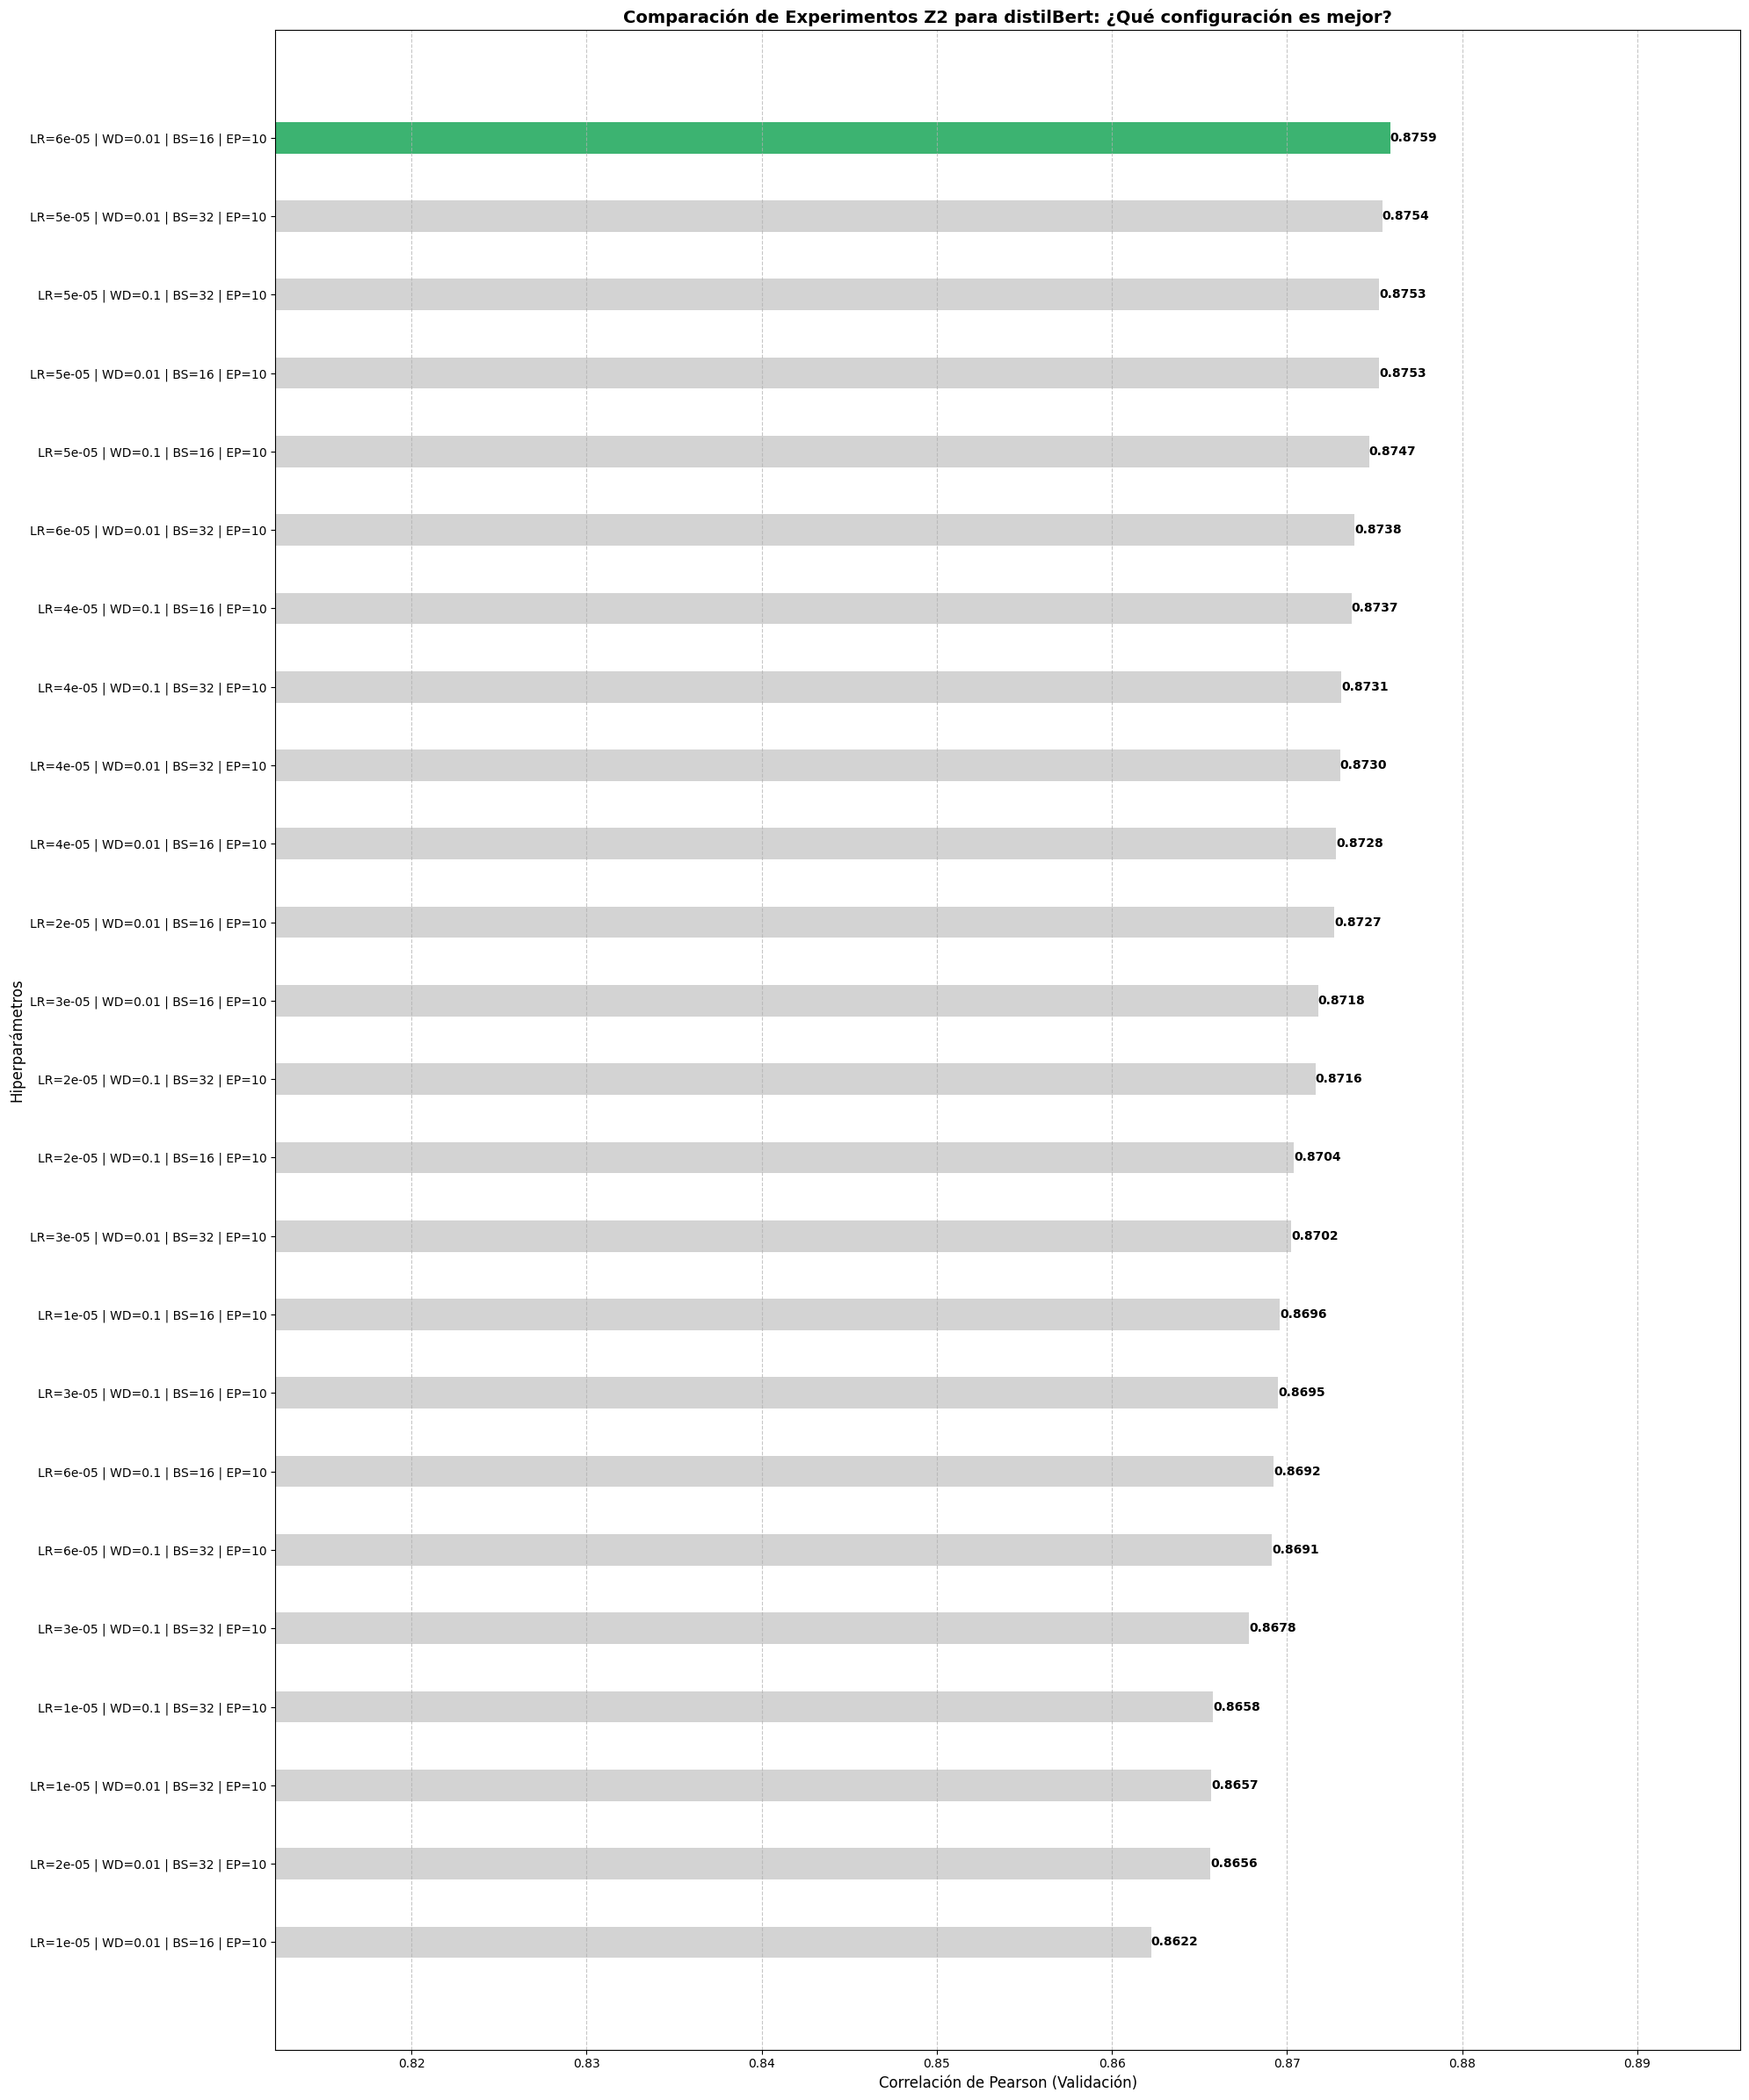

Gráfica guardada como 'grafica_grid_search_z2_distil.png'


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Recuperamos los datos (si existen)
if 'resultados_globales_distil' in globals() and resultados_globales_distil:
    df_plot = pd.DataFrame(resultados_globales_distil)

    # Creamos una etiqueta legible para cada barra
    df_plot['Config'] = df_plot.apply(lambda x: f"LR={x['LR']} | WD={x['Weight Decay']} | BS={x['Batch Size']} | EP={x['Epochs']}", axis=1)

    # Ordenamos de mejor a peor
    df_plot = df_plot.sort_values('Pearson (Val)', ascending=True)

    # 2. Configuración del Gráfico
    plt.figure(figsize=(20, 25))

    # Colores: Destacamos el mejor en verde, los demás en gris
    colores = ['lightgray'] * (len(df_plot) - 1) + ['mediumseagreen']

    barras = plt.barh(df_plot['Config'], df_plot['Pearson (Val)'], color=colores,height=0.4)

    # 3. Estética
    plt.xlabel('Correlación de Pearson (Validación)', fontsize=12)
    plt.ylabel('Hiperparámetros', fontsize=12)
    plt.title('Comparación de Experimentos Z2 para distilBert: ¿Qué configuración es mejor?', fontsize=14, fontweight='bold')

    # Ajustamos los límites del eje X para que se aprecien las diferencias
    # (Como todos estarán cerca de 0.8, empezamos en 0.7 para hacer "zoom")
    min_score = df_plot['Pearson (Val)'].min()
    plt.xlim(min_score - 0.05, df_plot['Pearson (Val)'].max() + 0.02)

    # 4. Añadir el valor exacto en cada barra
    for barra in barras:
        width = barra.get_width()
        plt.text(width, barra.get_y() + barra.get_height()/2,
                 f'{width:.4f}',
                 ha='left', va='center', fontweight='bold') # Removed padding=5

    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Mostrar y Guardar (para el informe)
    plt.savefig("grafica_grid_search_z2_distil.png", dpi=300) # Se guarda en la carpeta de archivos
    plt.show()
    print("Gráfica guardada como 'grafica_grid_search_z2_distil.png'")

else:
    print("No hay resultados en memoria. Ejecuta primero el entrenamiento (Grid Search).")

In [ ]:
resultados_val_ing.append({"Modelo": "distilBERT", "Pearson (Val)": 0.8759})

Como podemos observar, los mejores hiperparámetros que hemos encontrado para DistilBERT son: learning-rate de 6e-05, weight decay de 0.01, batch size de 16 y lo hemos entrenado durante 10 epoch, aunque hemos utilizado early-stopping, ya que suele obtener mejores resultados en los primeros epochs (en este caso del mejor resultado, ha parado en el epoch 9, obteniendo el mejor resultado en el 7º epoch).

El aspecto más importante a destacar es que este modelo pequeño funciona mejor con tasas de aprendizaje altas y, generalmente, con decaimiento de pesos de 0.01.

#### roBERTa

In [ ]:
model_checkpoint = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

# Función de preprocesamiento: Tokeniza las dos oraciones JUNTAS
def preprocess_function(examples):
    # El tokenizador de BERT añade automáticamente los tokens especiales:
    # [CLS] sentence1 [SEP] sentence2 [SEP]
    return tokenizer(examples['sentence1'], examples['sentence2'], truncation=True)

# Aplicamos la tokenización a todo el dataset
encoded_dataset = dataset.map(preprocess_function, batched=True)

# ¡IMPORTANTE! El 'Trainer' de Hugging Face espera que la etiqueta objetivo se llame 'labels'
# Renombramos la columna 'score' a 'labels'
encoded_dataset = encoded_dataset.rename_column("score", "labels")

# Eliminamos las columnas de texto originales para que no molesten al modelo
encoded_dataset = encoded_dataset.remove_columns(["sentence1", "sentence2", "genre", "dataset", "year", "sid", "split"])
encoded_dataset.set_format("torch")

print("Datos procesados. Ejemplo de entrada:", encoded_dataset['train'][0])

pearson = evaluate.load("pearsonr")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    # El modelo devuelve una tupla, nos quedamos con el primer elemento (las predicciones)
    predictions = predictions[:, 0]
    return pearson.compute(predictions=predictions, references=labels)

# Lista para guardar resultados en memoria
resultados_globales_roberta = []

# --- Configuración de rutas ---
# Carpeta en Drive donde SIEMPRE estará el mejor modelo encontrado hasta el momento
ruta_mejor_modelo_drive = f"{base_path}/z2_finetunning_roberta"

def ejecutar_experimento_roberta(lr, bs, wd, ep):
    torch.cuda.empty_cache()
    print(f"\n Iniciando Experimento: LR={lr} | BS={bs} | WD={wd} | EP={ep}")

    # 1. Configuración de Rutas
    run_name = f"z2roberta_lr{lr}_bs{bs}_wd{wd}_ep{ep}"

    # GUARDA AQUÍ TEMPORALMENTE (Disco local de Colab, muy rápido, se borra al reiniciar)
    output_dir_temp = f"/content/temp_experiments/experiments/{run_name}"

    # 2. Reiniciar modelo
    model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=1).to(device)

    args = TrainingArguments(
        output_dir=output_dir_temp,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        learning_rate=lr,
        per_device_train_batch_size=bs,
        per_device_eval_batch_size=bs,
        num_train_epochs=ep,
        weight_decay=wd,
        load_best_model_at_end=True,
        metric_for_best_model="pearsonr",
        save_total_limit=1,
        report_to="none",
        fp16=True if device == "cuda" else False,
        overwrite_output_dir=True,
        dataloader_num_workers=0,
        dataloader_pin_memory=False
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=encoded_dataset["train"],
        eval_dataset=encoded_dataset["validation"],
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    # 3. Entrenar
    trainer.train()

    # Guardamos explícitamente el modelo final en la carpeta temporal
    trainer.save_model(output_dir_temp)

    # 4. Evaluar
    eval_metrics = trainer.evaluate()
    nota = eval_metrics["eval_pearsonr"]
    print(f">>> Resultado Experimento: {nota:.4f}")

    # --- 5. LÓGICA DE "REY DE LA COLINA" ---
    # Buscamos cuál es la mejor nota que hemos conseguido hasta ahora en experimentos anteriores
    mejor_nota_historica = -1.0
    if resultados_globales_roberta:
        mejor_nota_historica = max(r["Pearson (Val)"] for r in resultados_globales_roberta)

    estado = ""
    if nota > mejor_nota_historica:
        print(f" ¡NUEVO RÉCORD! ({nota:.4f} supera a {mejor_nota_historica:.4f})")
        print(f" Guardando copia de seguridad en Drive: {ruta_mejor_modelo_drive}...")

        # Borramos el anterior campeón del Drive si existe para no ocupar espacio
        if os.path.exists(ruta_mejor_modelo_drive):
            shutil.rmtree(ruta_mejor_modelo_drive)

        # Copiamos el nuevo campeón de Temp -> Drive
        shutil.copytree(output_dir_temp, ruta_mejor_modelo_drive)
        estado = " Récord (Guardado en Drive)"
    else:
        print(f" No supera el récord ({nota:.4f} vs {mejor_nota_historica:.4f}).")
        print(" Descartando archivos de este modelo...")
        estado = "Descartado"

    # 6. Limpieza: Borramos SIEMPRE la carpeta temporal local para no llenar Colab
    if os.path.exists(output_dir_temp):
        shutil.rmtree(output_dir_temp)

    # 7. Guardar resultados en la tabla (Esto sí lo guardamos siempre)
    resultados_globales_roberta.append({
        "LR": lr, "Batch Size": bs, "Weight Decay": wd, "Epochs": ep,
        "Pearson (Val)": nota, "Estado": estado
    })

    return nota


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Map:   0%|          | 0/5749 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1379 [00:00<?, ? examples/s]

Datos procesados. Ejemplo de entrada: {'labels': tensor(5.), 'input_ids': tensor([    0,    62, 47880,    83, 35971,  5773,     5,     2,     2,   893,
         1831, 47880,    83, 35971,  5773,     5,     2]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])}


##### Experimentos

In [ ]:
#Experimento 1 (LR=1e-5, BS=32, WD=0.01, EP=10)
nota = ejecutar_experimento_roberta(lr=1e-5, bs=32, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=1e-05 | BS=32 | WD=0.01 | EP=10


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-256376278.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,2.589800,0.876045,0.805678
2,0.919600,0.668402,0.850779
3,0.665700,0.609004,0.867545
4,0.538800,0.581639,0.874782
5,0.470700,0.530259,0.875469
6,0.402500,0.544249,0.880943
7,0.352600,0.507703,0.882330
8,0.323500,0.520473,0.881918
9,0.308200,0.519946,0.880737


>>> Resultado Experimento: 0.8823
 ¡NUEVO RÉCORD! (0.8823 supera a -1.0000)
 Guardando copia de seguridad en Drive: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z2_finetunning_roberta...
Nota obtenida: 0.8823300652857475


In [ ]:
#Experimento 2 (LR=1e-5, BS=16, WD=0.01, EP=10)
nota = ejecutar_experimento_roberta(lr=1e-5, bs=16, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=1e-05 | BS=16 | WD=0.01 | EP=10


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-256376278.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.936400,0.733831,0.846321
2,0.683200,0.588329,0.866920
3,0.525500,0.525631,0.881025
4,0.413700,0.516955,0.884203
5,0.357600,0.504949,0.890330
6,0.289700,0.530666,0.883466
7,0.252100,0.533746,0.887293


>>> Resultado Experimento: 0.8903
 ¡NUEVO RÉCORD! (0.8903 supera a 0.8823)
 Guardando copia de seguridad en Drive: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z2_finetunning_roberta...
Nota obtenida: 0.890329829256987


In [ ]:
#Experimento 3 (LR=1e-5, BS=16, WD=0.1, EP=10)
nota = ejecutar_experimento_roberta(lr=1e-5, bs=16, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=1e-05 | BS=16 | WD=0.1 | EP=10


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-256376278.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,2.039700,1.044177,0.820554
2,0.729400,0.690258,0.861977
3,0.534800,0.540871,0.873816
4,0.428300,0.560438,0.873456
5,0.366600,0.543842,0.875695
6,0.309500,0.595740,0.876000
7,0.261200,0.653885,0.872094
8,0.231600,0.591720,0.874019


>>> Resultado Experimento: 0.8760
 No supera el récord (0.8760 vs 0.8903).
 Descartando archivos de este modelo...
Nota obtenida: 0.8760000207478985


In [ ]:
#Experimento 4 (LR=1e-5, BS=32, WD=0.1, EP=10)
nota = ejecutar_experimento_roberta(lr=1e-5, bs=32, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=1e-05 | BS=32 | WD=0.1 | EP=10


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-256376278.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,2.579900,0.747806,0.821416
2,0.839300,0.687713,0.862791
3,0.608100,0.692746,0.874439
4,0.488400,0.522953,0.877754
5,0.419300,0.525571,0.880169
6,0.369600,0.543674,0.886209
7,0.323600,0.496574,0.885719
8,0.292300,0.519277,0.885256


>>> Resultado Experimento: 0.8862
 No supera el récord (0.8862 vs 0.8903).
 Descartando archivos de este modelo...
Nota obtenida: 0.8862094727675475


In [ ]:
#Experimento 5 (LR=2e-5, BS=16, WD=0.01, EP=10)
nota = ejecutar_experimento_roberta(lr=2e-5, bs=16, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=2e-05 | BS=16 | WD=0.01 | EP=10


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-256376278.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.562200,0.736018,0.860144
2,0.627000,0.527057,0.876125
3,0.464600,0.505250,0.884479
4,0.349400,0.569272,0.881114
5,0.279900,0.510022,0.882063


>>> Resultado Experimento: 0.8845
 No supera el récord (0.8845 vs 0.8903).
 Descartando archivos de este modelo...
Nota obtenida: 0.8844787306894529


In [ ]:
#Experimento 6 (LR=2e-5, BS=32, WD=0.01, EP=10)
nota = ejecutar_experimento_roberta(lr=2e-5, bs=32, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=2e-05 | BS=32 | WD=0.01 | EP=10


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-256376278.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,2.140100,0.762835,0.850397
2,0.656800,0.637258,0.863413
3,0.515800,0.603478,0.879176
4,0.402900,0.525714,0.878323
5,0.316900,0.523674,0.883384
6,0.265300,0.540369,0.884406
7,0.226200,0.516664,0.882962
8,0.188000,0.528808,0.883354


>>> Resultado Experimento: 0.8844
 No supera el récord (0.8844 vs 0.8903).
 Descartando archivos de este modelo...
Nota obtenida: 0.8844062649940652


In [ ]:
#Experimento 7 (LR=2e-5, BS=16, WD=0.1, EP=10)
nota = ejecutar_experimento_roberta(lr=2e-5, bs=16, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=2e-05 | BS=16 | WD=0.1 | EP=10


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-256376278.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.578800,1.130689,0.846585
2,0.661400,0.571972,0.865033
3,0.478000,0.632123,0.872675
4,0.362900,0.584292,0.878814
5,0.278000,0.534378,0.879808
6,0.220900,0.579261,0.882426
7,0.181600,0.537321,0.881262
8,0.148100,0.529868,0.878128


>>> Resultado Experimento: 0.8824
 No supera el récord (0.8824 vs 0.8903).
 Descartando archivos de este modelo...
Nota obtenida: 0.8824256371773227


In [ ]:
#Experimento 8 (LR=2e-5, BS=32, WD=0.1, EP=10)
nota = ejecutar_experimento_roberta(lr=2e-5, bs=32, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=2e-05 | BS=32 | WD=0.1 | EP=10


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-256376278.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,2.009600,0.650984,0.847161
2,0.685900,0.639509,0.868203
3,0.513500,0.564704,0.881619
4,0.406500,0.516281,0.879919
5,0.320200,0.529639,0.881717
6,0.273800,0.541165,0.886711
7,0.225600,0.510952,0.886097
8,0.191100,0.507684,0.884497


>>> Resultado Experimento: 0.8867
 No supera el récord (0.8867 vs 0.8903).
 Descartando archivos de este modelo...
Nota obtenida: 0.8867109602199699


La configuración que mejor a funcionado ha sido lr = 1e-5, bs=16, wd=0.01 y para lr = 2e-5 también han funcionado bien bs=16 y wd=0.01, aunque algo peor que con lr=1e-5. Por lo tanto primero probamos la tasa de aprendizaje intermedia con el resto de parámetros que han obtenido los mejores resultados (bs=16, wd=0.01) para ver si el óptimo está ahí.

In [ ]:
#Experimento 9 (LR=1.5e-5, BS=16, WD=0.01, EP=10)
nota = ejecutar_experimento_roberta(lr=1.5e-5, bs=16, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=1.5e-05 | BS=16 | WD=0.01 | EP=10


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-256376278.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.822200,0.952230,0.848475
2,0.708500,0.578015,0.870435
3,0.514900,0.538897,0.876565
4,0.405000,0.595767,0.882673
5,0.322600,0.498201,0.883788
6,0.265900,0.539845,0.884830
7,0.217200,0.533676,0.881546
8,0.184100,0.537745,0.879633


>>> Resultado Experimento: 0.8848
 No supera el récord (0.8848 vs 0.8903).
 Descartando archivos de este modelo...
Nota obtenida: 0.8848297306487101


Hemos observado que el modelo funciona mejor con learning rates bajos, así que probamos con la mejor configuración bajando el learning rate.

In [ ]:
#Experimento 10 (LR=8e-6, BS=16, WD=0.01, EP=10)
nota = ejecutar_experimento_roberta(lr=8e-6, bs=16, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=8e-06 | BS=16 | WD=0.01 | EP=10


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-256376278.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,2.152100,0.647510,0.846300
2,0.702700,0.693647,0.860827
3,0.557900,0.534253,0.877897
4,0.435700,0.508692,0.881266
5,0.377700,0.528694,0.884303
6,0.319100,0.512884,0.884691
7,0.279300,0.499429,0.886638
8,0.252000,0.533211,0.882676
9,0.231300,0.517615,0.886360


>>> Resultado Experimento: 0.8866
 No supera el récord (0.8866 vs 0.8903).
 Descartando archivos de este modelo...
Nota obtenida: 0.8866383955287068


No mejora, así que nos quedamos con el que habíamos obtenido.

##### Resultados


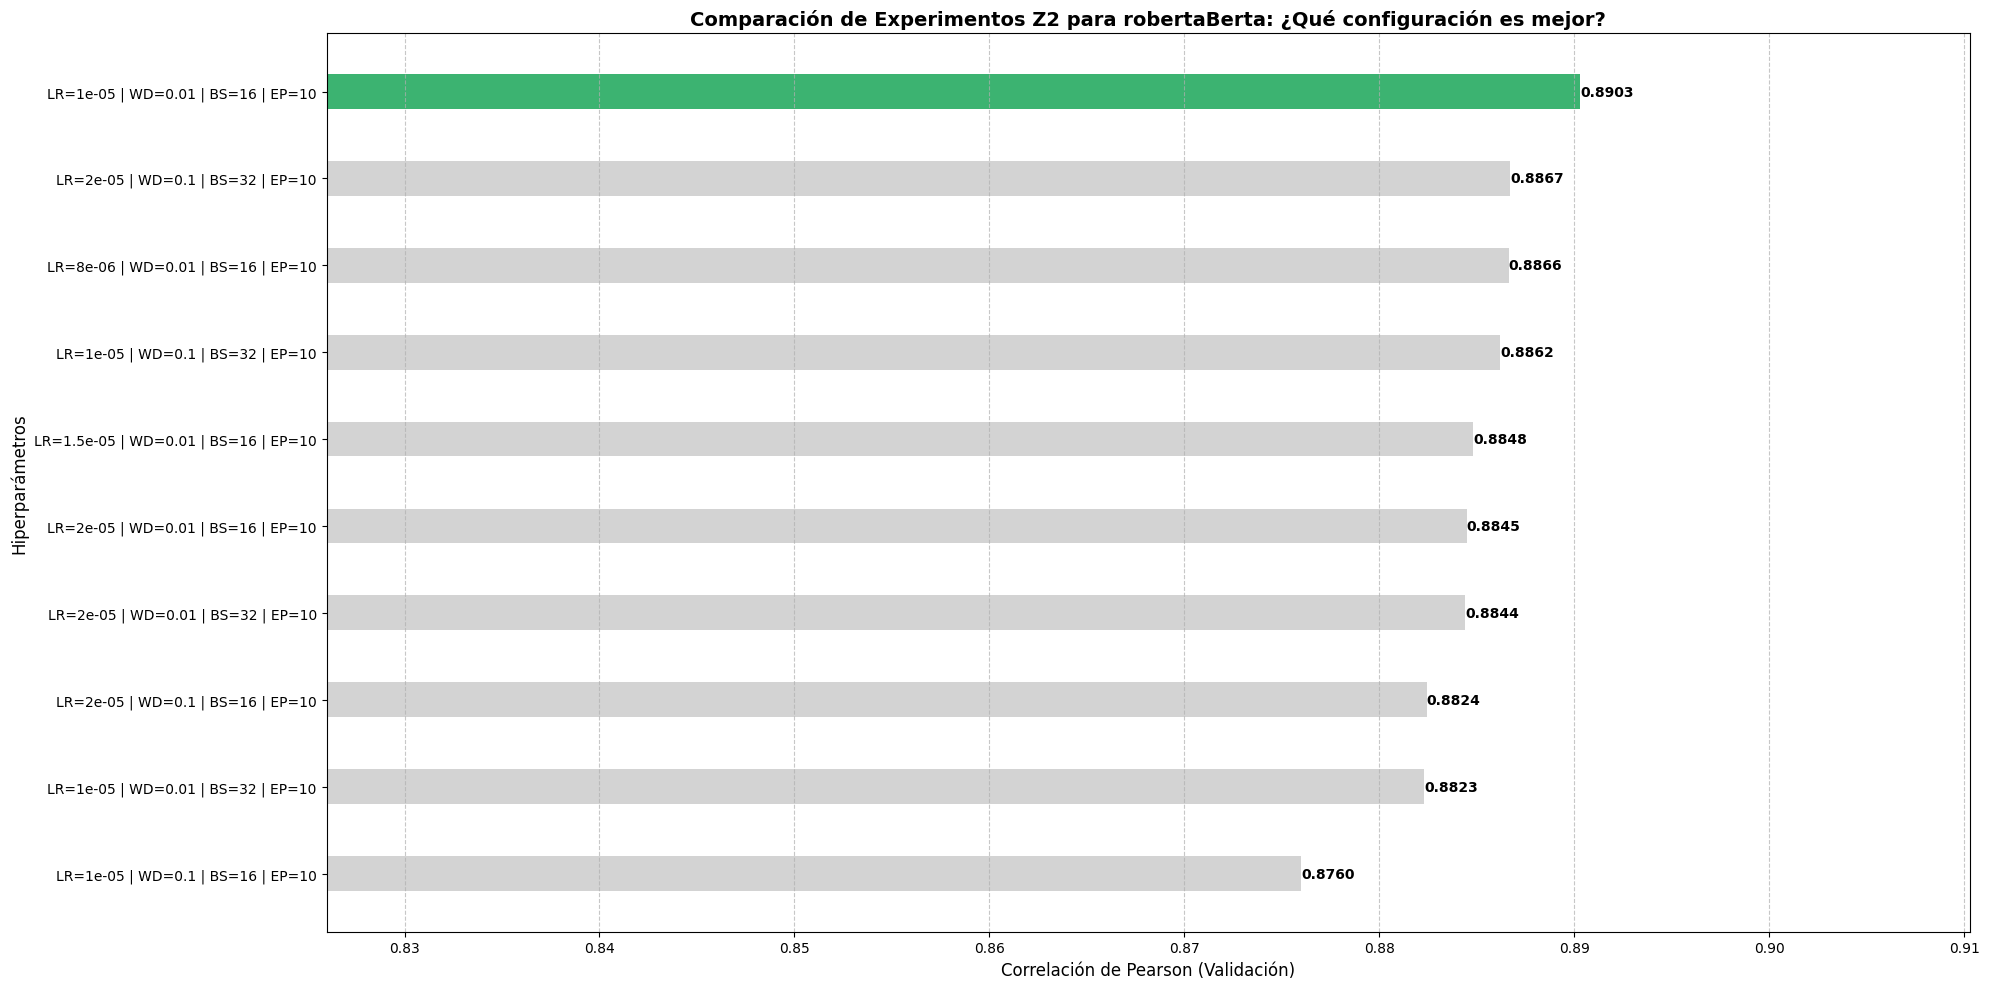

Gráfica guardada como 'grafica_grid_search_z2_roberta.png'


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Recuperamos los datos (si existen)
if 'resultados_globales_roberta' in globals() and resultados_globales_roberta:
    df_plot = pd.DataFrame(resultados_globales_roberta)

    # Creamos una etiqueta legible para cada barra
    df_plot['Config'] = df_plot.apply(lambda x: f"LR={x['LR']} | WD={x['Weight Decay']} | BS={x['Batch Size']} | EP={x['Epochs']}", axis=1)

    # Ordenamos de mejor a peor
    df_plot = df_plot.sort_values('Pearson (Val)', ascending=True)

    # 2. Configuración del Gráfico
    plt.figure(figsize=(20, 10))

    # Colores: Destacamos el mejor en verde, los demás en gris
    colores = ['lightgray'] * (len(df_plot) - 1) + ['mediumseagreen']

    barras = plt.barh(df_plot['Config'], df_plot['Pearson (Val)'], color=colores,height=0.4)

    # 3. Estética
    plt.xlabel('Correlación de Pearson (Validación)', fontsize=12)
    plt.ylabel('Hiperparámetros', fontsize=12)
    plt.title('Comparación de Experimentos Z2 para robertaBerta: ¿Qué configuración es mejor?', fontsize=14, fontweight='bold')

    # Ajustamos los límites del eje X para que se aprecien las diferencias
    # (Como todos estarán cerca de 0.8, empezamos en 0.7 para hacer "zoom")
    min_score = df_plot['Pearson (Val)'].min()
    plt.xlim(min_score - 0.05, df_plot['Pearson (Val)'].max() + 0.02)

    # 4. Añadir el valor exacto en cada barra
    for barra in barras:
        width = barra.get_width()
        plt.text(width, barra.get_y() + barra.get_height()/2,
                 f'{width:.4f}',
                 ha='left', va='center', fontweight='bold') # Removed padding=5

    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Mostrar y Guardar (para el informe)
    plt.savefig("grafica_grid_search_z2_roberta.png", dpi=300) # Se guarda en la carpeta de archivos
    plt.show()
    print("Gráfica guardada como 'grafica_grid_search_z2_roberta.png'")

else:
    print("No hay resultados en memoria. Ejecuta primero el entrenamiento (Grid Search).")

In [ ]:
resultados_val_ing.append({"Modelo": "xmlRoBERTa", "Pearson (Val)": 0.8903})

Como podemos ver en estos pocos experimentos que hemos realizado con roBERTa, los resultados son bastante peores que con distilBERT, por lo que lo descartamos.

#### BERT

In [ ]:
model_checkpoint = "bert-base-cased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

# Función de preprocesamiento: Tokeniza las dos oraciones JUNTAS
def preprocess_function(examples):
    # El tokenizador de BERT añade automáticamente los tokens especiales:
    # [CLS] sentence1 [SEP] sentence2 [SEP]
    return tokenizer(examples['sentence1'], examples['sentence2'], truncation=True)

# Aplicamos la tokenización a todo el dataset
encoded_dataset = dataset.map(preprocess_function, batched=True)

# ¡IMPORTANTE! El 'Trainer' de Hugging Face espera que la etiqueta objetivo se llame 'labels'
# Renombramos la columna 'score' a 'labels'
encoded_dataset = encoded_dataset.rename_column("score", "labels")

# Eliminamos las columnas de texto originales para que no molesten al modelo
encoded_dataset = encoded_dataset.remove_columns(["sentence1", "sentence2", "genre", "dataset", "year", "sid", "split"])
encoded_dataset.set_format("torch")

print("Datos procesados. Ejemplo de entrada:", encoded_dataset['train'][0])

pearson = evaluate.load("pearsonr")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    # El modelo devuelve una tupla, nos quedamos con el primer elemento (las predicciones)
    predictions = predictions[:, 0]
    return pearson.compute(predictions=predictions, references=labels)

# Lista para guardar resultados en memoria
resultados_globales_bert = []

# --- Configuración de rutas ---
# Carpeta en Drive donde SIEMPRE estará el mejor modelo encontrado hasta el momento
ruta_mejor_modelo_drive = f"{base_path}/z2_finetunning_bert"

def ejecutar_experimento_bert(lr, bs, wd, ep):
    print(f"\n Iniciando Experimento: LR={lr} | BS={bs} | WD={wd} | EP={ep}")

    # 1. Configuración de Rutas
    run_name = f"z2bert_lr{lr}_bs{bs}_wd{wd}_ep{ep}"

    # GUARDA AQUÍ TEMPORALMENTE (Disco local de Colab, muy rápido, se borra al reiniciar)
    output_dir_temp = f"/content/temp_experiments/experiments/{run_name}"

    # 2. Reiniciar modelo
    model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=1).to(device)

    args = TrainingArguments(
        output_dir=output_dir_temp,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        learning_rate=lr,
        per_device_train_batch_size=bs,
        per_device_eval_batch_size=bs,
        num_train_epochs=ep,
        weight_decay=wd,
        load_best_model_at_end=True,
        metric_for_best_model="pearsonr",
        save_total_limit=1,
        report_to="none",
        fp16=True if device == "cuda" else False,
        overwrite_output_dir=True,
        dataloader_num_workers=0,
        dataloader_pin_memory=False
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=encoded_dataset["train"],
        eval_dataset=encoded_dataset["validation"],
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    # 3. Entrenar
    trainer.train()

    # Guardamos explícitamente el modelo final en la carpeta temporal
    trainer.save_model(output_dir_temp)

    # 4. Evaluar
    eval_metrics = trainer.evaluate()
    nota = eval_metrics["eval_pearsonr"]
    print(f">>> Resultado Experimento: {nota:.4f}")

    # --- 5. LÓGICA DE "REY DE LA COLINA" ---
    # Buscamos cuál es la mejor nota que hemos conseguido hasta ahora en experimentos anteriores
    mejor_nota_historica = -1.0
    if resultados_globales_bert:
        mejor_nota_historica = max(r["Pearson (Val)"] for r in resultados_globales_bert)

    estado = ""
    if nota > mejor_nota_historica:
        print(f" ¡NUEVO RÉCORD! ({nota:.4f} supera a {mejor_nota_historica:.4f})")
        print(f" Guardando copia de seguridad en Drive: {ruta_mejor_modelo_drive}...")

        # Borramos el anterior campeón del Drive si existe para no ocupar espacio
        if os.path.exists(ruta_mejor_modelo_drive):
            shutil.rmtree(ruta_mejor_modelo_drive)

        # Copiamos el nuevo campeón de Temp -> Drive
        shutil.copytree(output_dir_temp, ruta_mejor_modelo_drive)
        estado = " Récord (Guardado en Drive)"
    else:
        print(f" No supera el récord ({nota:.4f} vs {mejor_nota_historica:.4f}).")
        print(" Descartando archivos de este modelo...")
        estado = "Descartado"

    # 6. Limpieza: Borramos SIEMPRE la carpeta temporal local para no llenar Colab
    if os.path.exists(output_dir_temp):
        shutil.rmtree(output_dir_temp)

    # 7. Guardar resultados en la tabla (Esto sí lo guardamos siempre)
    resultados_globales_bert.append({
        "LR": lr, "Batch Size": bs, "Weight Decay": wd, "Epochs": ep,
        "Pearson (Val)": nota, "Estado": estado
    })

    return nota


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

Map:   0%|          | 0/5749 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1379 [00:00<?, ? examples/s]

Datos procesados. Ejemplo de entrada: {'labels': tensor(5.), 'input_ids': tensor([ 101,  138, 4261, 1110, 1781, 1228,  119,  102, 1760, 1586, 4261, 1110,
        1781, 1228,  119,  102]), 'token_type_ids': tensor([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])}


##### Experimentos

In [ ]:
#Experimento 1 (LR=1e-5, BS=16, WD=0.01, EP=10)
nota = ejecutar_experimento_bert(lr=1e-5, bs=16, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=1e-05 | BS=16 | WD=0.01 | EP=10


model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4090676564.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,2.095400,0.565276,0.865519
2,0.562500,0.549638,0.872634
3,0.397900,0.549581,0.877142
4,0.292900,0.519141,0.879881
5,0.226800,0.526609,0.879815
6,0.190200,0.529821,0.882505
7,0.156900,0.513058,0.882109
8,0.137100,0.518664,0.883310
9,0.122800,0.516458,0.883180
10,0.114100,0.511797,0.883811


>>> Resultado Experimento: 0.8838
 ¡NUEVO RÉCORD! (0.8838 supera a -1.0000)
 Guardando copia de seguridad en Drive: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z2_finetunning_bert...
Nota obtenida: 0.883810991760947


In [ ]:
#Experimento 2 (LR=1e-5, BS=32, WD=0.01, EP=10)
nota = ejecutar_experimento_bert(lr=1e-5, bs=32, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=1e-05 | BS=32 | WD=0.01 | EP=10


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4090676564.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.846900,0.618992,0.859136
2,0.550700,0.540368,0.876740
3,0.389700,0.547692,0.881319
4,0.311100,0.487748,0.885697
5,0.250200,0.513119,0.887442
6,0.211100,0.519372,0.888143
7,0.186700,0.490590,0.889623
8,0.165300,0.506017,0.889051
9,0.155300,0.496039,0.890518
10,0.145000,0.488911,0.890714


>>> Resultado Experimento: 0.8907
 ¡NUEVO RÉCORD! (0.8907 supera a 0.8838)
 Guardando copia de seguridad en Drive: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z2_finetunning_bert...
Nota obtenida: 0.8907138366539019


In [ ]:
#Experimento 3 (LR=1e-5, BS=16, WD=0.1, EP=10)
nota = ejecutar_experimento_bert(lr=1e-5, bs=16, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=1e-05 | BS=16 | WD=0.1 | EP=10


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4090676564.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.400400,0.532132,0.874154
2,0.490500,0.612198,0.880591
3,0.334400,0.548242,0.884778
4,0.248300,0.484178,0.890370
5,0.193100,0.498552,0.890782
6,0.162700,0.497697,0.893640
7,0.143100,0.473984,0.892810
8,0.122700,0.470116,0.892890


>>> Resultado Experimento: 0.8936
 ¡NUEVO RÉCORD! (0.8936 supera a 0.8907)
 Guardando copia de seguridad en Drive: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z2_finetunning_bert...
Nota obtenida: 0.8936400120305117


In [ ]:
#Experimento 4 (LR=1e-5, BS=32, WD=0.1, EP=10)
nota = ejecutar_experimento_bert(lr=1e-5, bs=32, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=1e-05 | BS=32 | WD=0.1 | EP=10


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4090676564.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,2.107900,0.754809,0.831449
2,0.667800,0.578453,0.863544
3,0.508000,0.551627,0.872754
4,0.381800,0.518695,0.878420
5,0.311400,0.548507,0.878729
6,0.263800,0.572865,0.879023
7,0.226800,0.545261,0.880197
8,0.200900,0.560605,0.881374
9,0.186500,0.533363,0.881753
10,0.172800,0.528600,0.882196


>>> Resultado Experimento: 0.8822
 No supera el récord (0.8822 vs 0.8936).
 Descartando archivos de este modelo...
Nota obtenida: 0.8821964150420166


In [ ]:
#Experimento 5 (LR=2e-5, BS=16, WD=0.01, EP=10)
nota = ejecutar_experimento_bert(lr=2e-5, bs=16, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=2e-05 | BS=16 | WD=0.01 | EP=10


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4090676564.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.170300,0.552901,0.878720
2,0.411900,0.616171,0.885466
3,0.250100,0.509235,0.891362
4,0.175100,0.460302,0.894707
5,0.130600,0.458377,0.897255
6,0.110200,0.443804,0.897992
7,0.093800,0.440468,0.898727
8,0.078800,0.442062,0.897533
9,0.071800,0.439418,0.898517


>>> Resultado Experimento: 0.8987
 ¡NUEVO RÉCORD! (0.8987 supera a 0.8936)
 Guardando copia de seguridad en Drive: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z2_finetunning_bert...
Nota obtenida: 0.8987272421868308


In [ ]:
#Experimento 6 (LR=2e-5, BS=32, WD=0.01, EP=10)
nota = ejecutar_experimento_bert(lr=2e-5, bs=32, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=2e-05 | BS=32 | WD=0.01 | EP=10


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4090676564.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,2.350000,0.615938,0.856525
2,0.540500,0.580987,0.873734
3,0.364300,0.534019,0.882303
4,0.249800,0.489835,0.887331
5,0.182300,0.495013,0.887642
6,0.143600,0.493053,0.888267
7,0.120100,0.494815,0.889507
8,0.099900,0.489845,0.890696
9,0.087200,0.479694,0.891223
10,0.081400,0.478524,0.891426


>>> Resultado Experimento: 0.8914
 No supera el récord (0.8914 vs 0.8987).
 Descartando archivos de este modelo...
Nota obtenida: 0.8914263259233004


In [ ]:
#Experimento 7 (LR=2e-5, BS=16, WD=0.1, EP=10)
nota = ejecutar_experimento_bert(lr=2e-5, bs=16, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=2e-05 | BS=16 | WD=0.1 | EP=10


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4090676564.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.173300,0.560501,0.876727
2,0.412700,0.633870,0.884688
3,0.253700,0.483100,0.891384
4,0.175100,0.463346,0.893068
5,0.131500,0.455625,0.897641
6,0.110600,0.452097,0.897361
7,0.093900,0.443764,0.898040
8,0.077300,0.443362,0.897209
9,0.071200,0.440634,0.898124
10,0.061400,0.439507,0.898588


>>> Resultado Experimento: 0.8986
 No supera el récord (0.8986 vs 0.8987).
 Descartando archivos de este modelo...
Nota obtenida: 0.8985881479707055


In [ ]:
#Experimento 8 (LR=2e-5, BS=32, WD=0.1, EP=10)
nota = ejecutar_experimento_bert(lr=2e-5, bs=32, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=2e-05 | BS=32 | WD=0.1 | EP=10


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4090676564.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.443700,0.522640,0.876356
2,0.446300,0.569045,0.882472
3,0.274100,0.530508,0.885490
4,0.197800,0.480747,0.891740
5,0.156500,0.465407,0.893073
6,0.127400,0.477718,0.893462
7,0.108900,0.454963,0.895210
8,0.097400,0.463023,0.895615
9,0.086600,0.458559,0.896335
10,0.081400,0.455058,0.896504


>>> Resultado Experimento: 0.8965
 No supera el récord (0.8965 vs 0.8987).
 Descartando archivos de este modelo...
Nota obtenida: 0.8965039086802928


In [ ]:
#Experimento 9 (LR=3e-5, BS=16, WD=0.01, EP=10)
nota = ejecutar_experimento_bert(lr=3e-5, bs=16, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=3e-05 | BS=16 | WD=0.01 | EP=10


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4090676564.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.065100,0.553466,0.878418
2,0.386500,0.648764,0.883744
3,0.230300,0.492684,0.889593
4,0.166600,0.465005,0.891518
5,0.126900,0.443587,0.896887
6,0.102000,0.447272,0.896547
7,0.086200,0.441397,0.898317
8,0.068600,0.450552,0.897356
9,0.062100,0.434434,0.898954
10,0.054200,0.433723,0.899602


>>> Resultado Experimento: 0.8996
 ¡NUEVO RÉCORD! (0.8996 supera a 0.8987)
 Guardando copia de seguridad en Drive: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z2_finetunning_bert...
Nota obtenida: 0.8996023643682811


In [ ]:
#Experimento 10 (LR=3e-5, BS=32, WD=0.01, EP=10)
nota = ejecutar_experimento_bert(lr=3e-5, bs=32, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=3e-05 | BS=32 | WD=0.01 | EP=10


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4090676564.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.350700,0.522604,0.876549
2,0.416400,0.530889,0.885918
3,0.235600,0.470703,0.890968
4,0.171000,0.480066,0.893682
5,0.130100,0.444259,0.897388
6,0.104000,0.452296,0.897354
7,0.088500,0.438293,0.899002
8,0.079000,0.437289,0.899764
9,0.067900,0.441307,0.899816
10,0.063700,0.435252,0.900233


>>> Resultado Experimento: 0.9002
 ¡NUEVO RÉCORD! (0.9002 supera a 0.8996)
 Guardando copia de seguridad en Drive: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z2_finetunning_bert...
Nota obtenida: 0.9002333695947627


In [ ]:
#Experimento 11 (LR=3e-5, BS=16, WD=0.1, EP=10)
nota = ejecutar_experimento_bert(lr=3e-5, bs=16, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=3e-05 | BS=16 | WD=0.1 | EP=10


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4090676564.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.069800,0.569333,0.878393
2,0.387000,0.635141,0.884696
3,0.229600,0.490685,0.889441
4,0.168500,0.474480,0.891200
5,0.125400,0.451334,0.895160
6,0.101900,0.451651,0.896096
7,0.084500,0.442228,0.897294
8,0.068200,0.454403,0.896225
9,0.062200,0.438346,0.898070
10,0.052800,0.438056,0.898324


>>> Resultado Experimento: 0.8983
 No supera el récord (0.8983 vs 0.9002).
 Descartando archivos de este modelo...
Nota obtenida: 0.8983238007696164


In [ ]:
#Experimento 12 (LR=3e-5, BS=32, WD=0.1, EP=10)
nota = ejecutar_experimento_bert(lr=3e-5, bs=32, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=3e-05 | BS=32 | WD=0.1 | EP=10


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4090676564.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.351600,0.523872,0.876163
2,0.416200,0.534225,0.885862
3,0.235800,0.470706,0.890846
4,0.170400,0.481141,0.893410
5,0.130000,0.445673,0.896895
6,0.103400,0.454267,0.896643
7,0.088400,0.441222,0.898768
8,0.078700,0.439334,0.899196
9,0.067800,0.441112,0.899518
10,0.063400,0.435773,0.899973


>>> Resultado Experimento: 0.9000
 No supera el récord (0.9000 vs 0.9002).
 Descartando archivos de este modelo...
Nota obtenida: 0.8999729486662333


In [ ]:
#Experimento 13 (LR=4e-5, BS=16, WD=0.01, EP=10)
nota = ejecutar_experimento_bert(lr=4e-5, bs=16, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=4e-05 | BS=16 | WD=0.01 | EP=10


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4090676564.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,0.984500,0.784601,0.866606
2,0.374600,0.695705,0.884497
3,0.232500,0.468064,0.892042
4,0.161400,0.467578,0.890877
5,0.123300,0.440701,0.897278
6,0.097600,0.438025,0.897798
7,0.082100,0.443104,0.896671
8,0.064900,0.446517,0.896887


>>> Resultado Experimento: 0.8978
 No supera el récord (0.8978 vs 0.9002).
 Descartando archivos de este modelo...
Nota obtenida: 0.8977977782677211


In [ ]:
#Experimento 14 (LR=4e-5, BS=32, WD=0.01, EP=10)
nota = ejecutar_experimento_bert(lr=4e-5, bs=32, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=4e-05 | BS=32 | WD=0.01 | EP=10


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4090676564.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.386900,0.525916,0.875541
2,0.447800,0.541427,0.878223
3,0.270600,0.500153,0.888233
4,0.170800,0.489104,0.890138
5,0.125100,0.463074,0.891761
6,0.099800,0.472885,0.891951
7,0.077400,0.490227,0.891100
8,0.062400,0.463956,0.893044
9,0.054700,0.458999,0.892896
10,0.045800,0.466998,0.892862


>>> Resultado Experimento: 0.8930
 No supera el récord (0.8930 vs 0.9002).
 Descartando archivos de este modelo...
Nota obtenida: 0.8930442809785798


In [ ]:
#Experimento 15 (LR=4e-5, BS=16, WD=0.1, EP=10)
nota = ejecutar_experimento_bert(lr=4e-5, bs=16, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=4e-05 | BS=16 | WD=0.1 | EP=10


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4090676564.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,0.984700,0.801121,0.868028
2,0.377800,0.648613,0.886111
3,0.228000,0.462274,0.892418
4,0.166500,0.469634,0.891483
5,0.121700,0.434856,0.898484
6,0.096700,0.432700,0.899869
7,0.079200,0.445964,0.897883
8,0.064400,0.451392,0.896875


>>> Resultado Experimento: 0.8999
 No supera el récord (0.8999 vs 0.9002).
 Descartando archivos de este modelo...
Nota obtenida: 0.899869220497729


In [ ]:
#Experimento 16 (LR=4e-5, BS=32, WD=0.1, EP=10)
nota = ejecutar_experimento_bert(lr=4e-5, bs=32, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=4e-05 | BS=32 | WD=0.1 | EP=10


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4090676564.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.384700,0.534761,0.875266
2,0.448400,0.540606,0.878319
3,0.269900,0.506082,0.884926
4,0.171000,0.479444,0.889968
5,0.123000,0.465564,0.890669
6,0.099100,0.464313,0.891794
7,0.075800,0.475730,0.891685
8,0.062600,0.463724,0.892585
9,0.053900,0.462145,0.892258
10,0.046200,0.468740,0.892422


>>> Resultado Experimento: 0.8926
 No supera el récord (0.8926 vs 0.9002).
 Descartando archivos de este modelo...
Nota obtenida: 0.8925848582281498


In [ ]:
#Experimento 17 (LR=5e-5, BS=16, WD=0.01, EP=10)
nota = ejecutar_experimento_bert(lr=5e-5, bs=16, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=5e-05 | BS=16 | WD=0.01 | EP=10


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4090676564.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,0.975600,0.773235,0.854652
2,0.369500,0.554842,0.885443
3,0.228500,0.490294,0.890489
4,0.171100,0.483318,0.887576
5,0.126200,0.439569,0.897108
6,0.099800,0.437035,0.898049
7,0.080300,0.436228,0.898597
8,0.063300,0.438412,0.897584
9,0.053200,0.434356,0.898495


>>> Resultado Experimento: 0.8986
 No supera el récord (0.8986 vs 0.9002).
 Descartando archivos de este modelo...
Nota obtenida: 0.898596681320839


In [ ]:
#Experimento 18 (LR=5e-5, BS=32, WD=0.01, EP=10)
nota = ejecutar_experimento_bert(lr=5e-5, bs=32, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=5e-05 | BS=32 | WD=0.01 | EP=10


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4090676564.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.777900,0.520825,0.876712
2,0.430300,0.568626,0.874779
3,0.258800,0.498628,0.885431
4,0.169300,0.474428,0.889949
5,0.121500,0.459575,0.892053
6,0.093800,0.465068,0.891218
7,0.074400,0.471744,0.891232


>>> Resultado Experimento: 0.8921
 No supera el récord (0.8921 vs 0.9002).
 Descartando archivos de este modelo...
Nota obtenida: 0.8920530974341371


In [ ]:
#Experimento 19 (LR=5e-5, BS=16, WD=0.1, EP=10)
nota = ejecutar_experimento_bert(lr=5e-5, bs=16, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=5e-05 | BS=16 | WD=0.1 | EP=10


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4090676564.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.233800,0.850488,0.873201
2,0.423400,0.564004,0.877840
3,0.236800,0.523365,0.881844
4,0.158000,0.490746,0.885914
5,0.116400,0.501165,0.888970
6,0.085200,0.465933,0.891770
7,0.066500,0.469288,0.891666
8,0.051700,0.457647,0.892959
9,0.038700,0.462668,0.892218
10,0.031100,0.460229,0.892767


>>> Resultado Experimento: 0.8930
 No supera el récord (0.8930 vs 0.9002).
 Descartando archivos de este modelo...
Nota obtenida: 0.8929589849540709


In [ ]:
#Experimento 20 (LR=5e-5, BS=32, WD=0.1, EP=10)
nota = ejecutar_experimento_bert(lr=5e-5, bs=32, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=5e-05 | BS=32 | WD=0.1 | EP=10


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4090676564.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.132400,0.559811,0.877450
2,0.369700,0.538572,0.880773
3,0.225600,0.460333,0.892751
4,0.160400,0.501473,0.889457
5,0.123400,0.449030,0.895442
6,0.100600,0.458090,0.894251
7,0.081200,0.448121,0.895385


>>> Resultado Experimento: 0.8954
 No supera el récord (0.8954 vs 0.9002).
 Descartando archivos de este modelo...
Nota obtenida: 0.8954420411351843


In [ ]:
#Experimento 21 (LR=6e-5, BS=16, WD=0.01, EP=10)
nota = ejecutar_experimento_bert(lr=6e-5, bs=16, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=6e-05 | BS=16 | WD=0.01 | EP=10


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4090676564.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.212200,0.988477,0.859108
2,0.433200,0.544681,0.878651
3,0.257700,0.547305,0.874517
4,0.173700,0.527485,0.876675


>>> Resultado Experimento: 0.8787
 No supera el récord (0.8787 vs 0.9002).
 Descartando archivos de este modelo...
Nota obtenida: 0.8786513343888865


In [ ]:
#Experimento 22 (LR=6e-5, BS=32, WD=0.01, EP=10)
nota = ejecutar_experimento_bert(lr=6e-5, bs=32, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=6e-05 | BS=32 | WD=0.01 | EP=10


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4090676564.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.503600,0.780381,0.856583
2,0.475400,0.540980,0.872342
3,0.282600,0.539555,0.875984
4,0.186000,0.560100,0.877302
5,0.131500,0.508533,0.881156
6,0.098700,0.504999,0.883310
7,0.077700,0.527133,0.880902
8,0.058100,0.507740,0.882458


>>> Resultado Experimento: 0.8833
 No supera el récord (0.8833 vs 0.9002).
 Descartando archivos de este modelo...
Nota obtenida: 0.883310100997752


In [ ]:
#Experimento 23 (LR=6e-5, BS=16, WD=0.1, EP=10)
nota = ejecutar_experimento_bert(lr=6e-5, bs=16, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=6e-05 | BS=16 | WD=0.1 | EP=10


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4090676564.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.041500,0.976395,0.853248
2,0.398600,0.605974,0.874001
3,0.232700,0.480340,0.887399
4,0.168700,0.480275,0.888787
5,0.126200,0.492083,0.894043
6,0.092000,0.449516,0.895138
7,0.071200,0.450658,0.894344
8,0.054400,0.452462,0.896689
9,0.040900,0.453677,0.897000
10,0.032400,0.446279,0.897194


>>> Resultado Experimento: 0.8972
 No supera el récord (0.8972 vs 0.9002).
 Descartando archivos de este modelo...
Nota obtenida: 0.8971944804009648


In [ ]:
#Experimento 24 (LR=6e-5, BS=32, WD=0.1, EP=10)
nota = ejecutar_experimento_bert(lr=6e-5, bs=32, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=6e-05 | BS=32 | WD=0.1 | EP=10


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4090676564.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.176000,0.534284,0.873811
2,0.386200,0.532713,0.879675
3,0.226100,0.478090,0.890575
4,0.164500,0.499507,0.890234
5,0.124900,0.452925,0.894270
6,0.099500,0.454957,0.894620
7,0.080500,0.451999,0.895535
8,0.067600,0.446378,0.896056
9,0.057100,0.450990,0.895895
10,0.049200,0.445599,0.896714


>>> Resultado Experimento: 0.8967
 No supera el récord (0.8967 vs 0.9002).
 Descartando archivos de este modelo...
Nota obtenida: 0.8967138007926069


##### Resultados

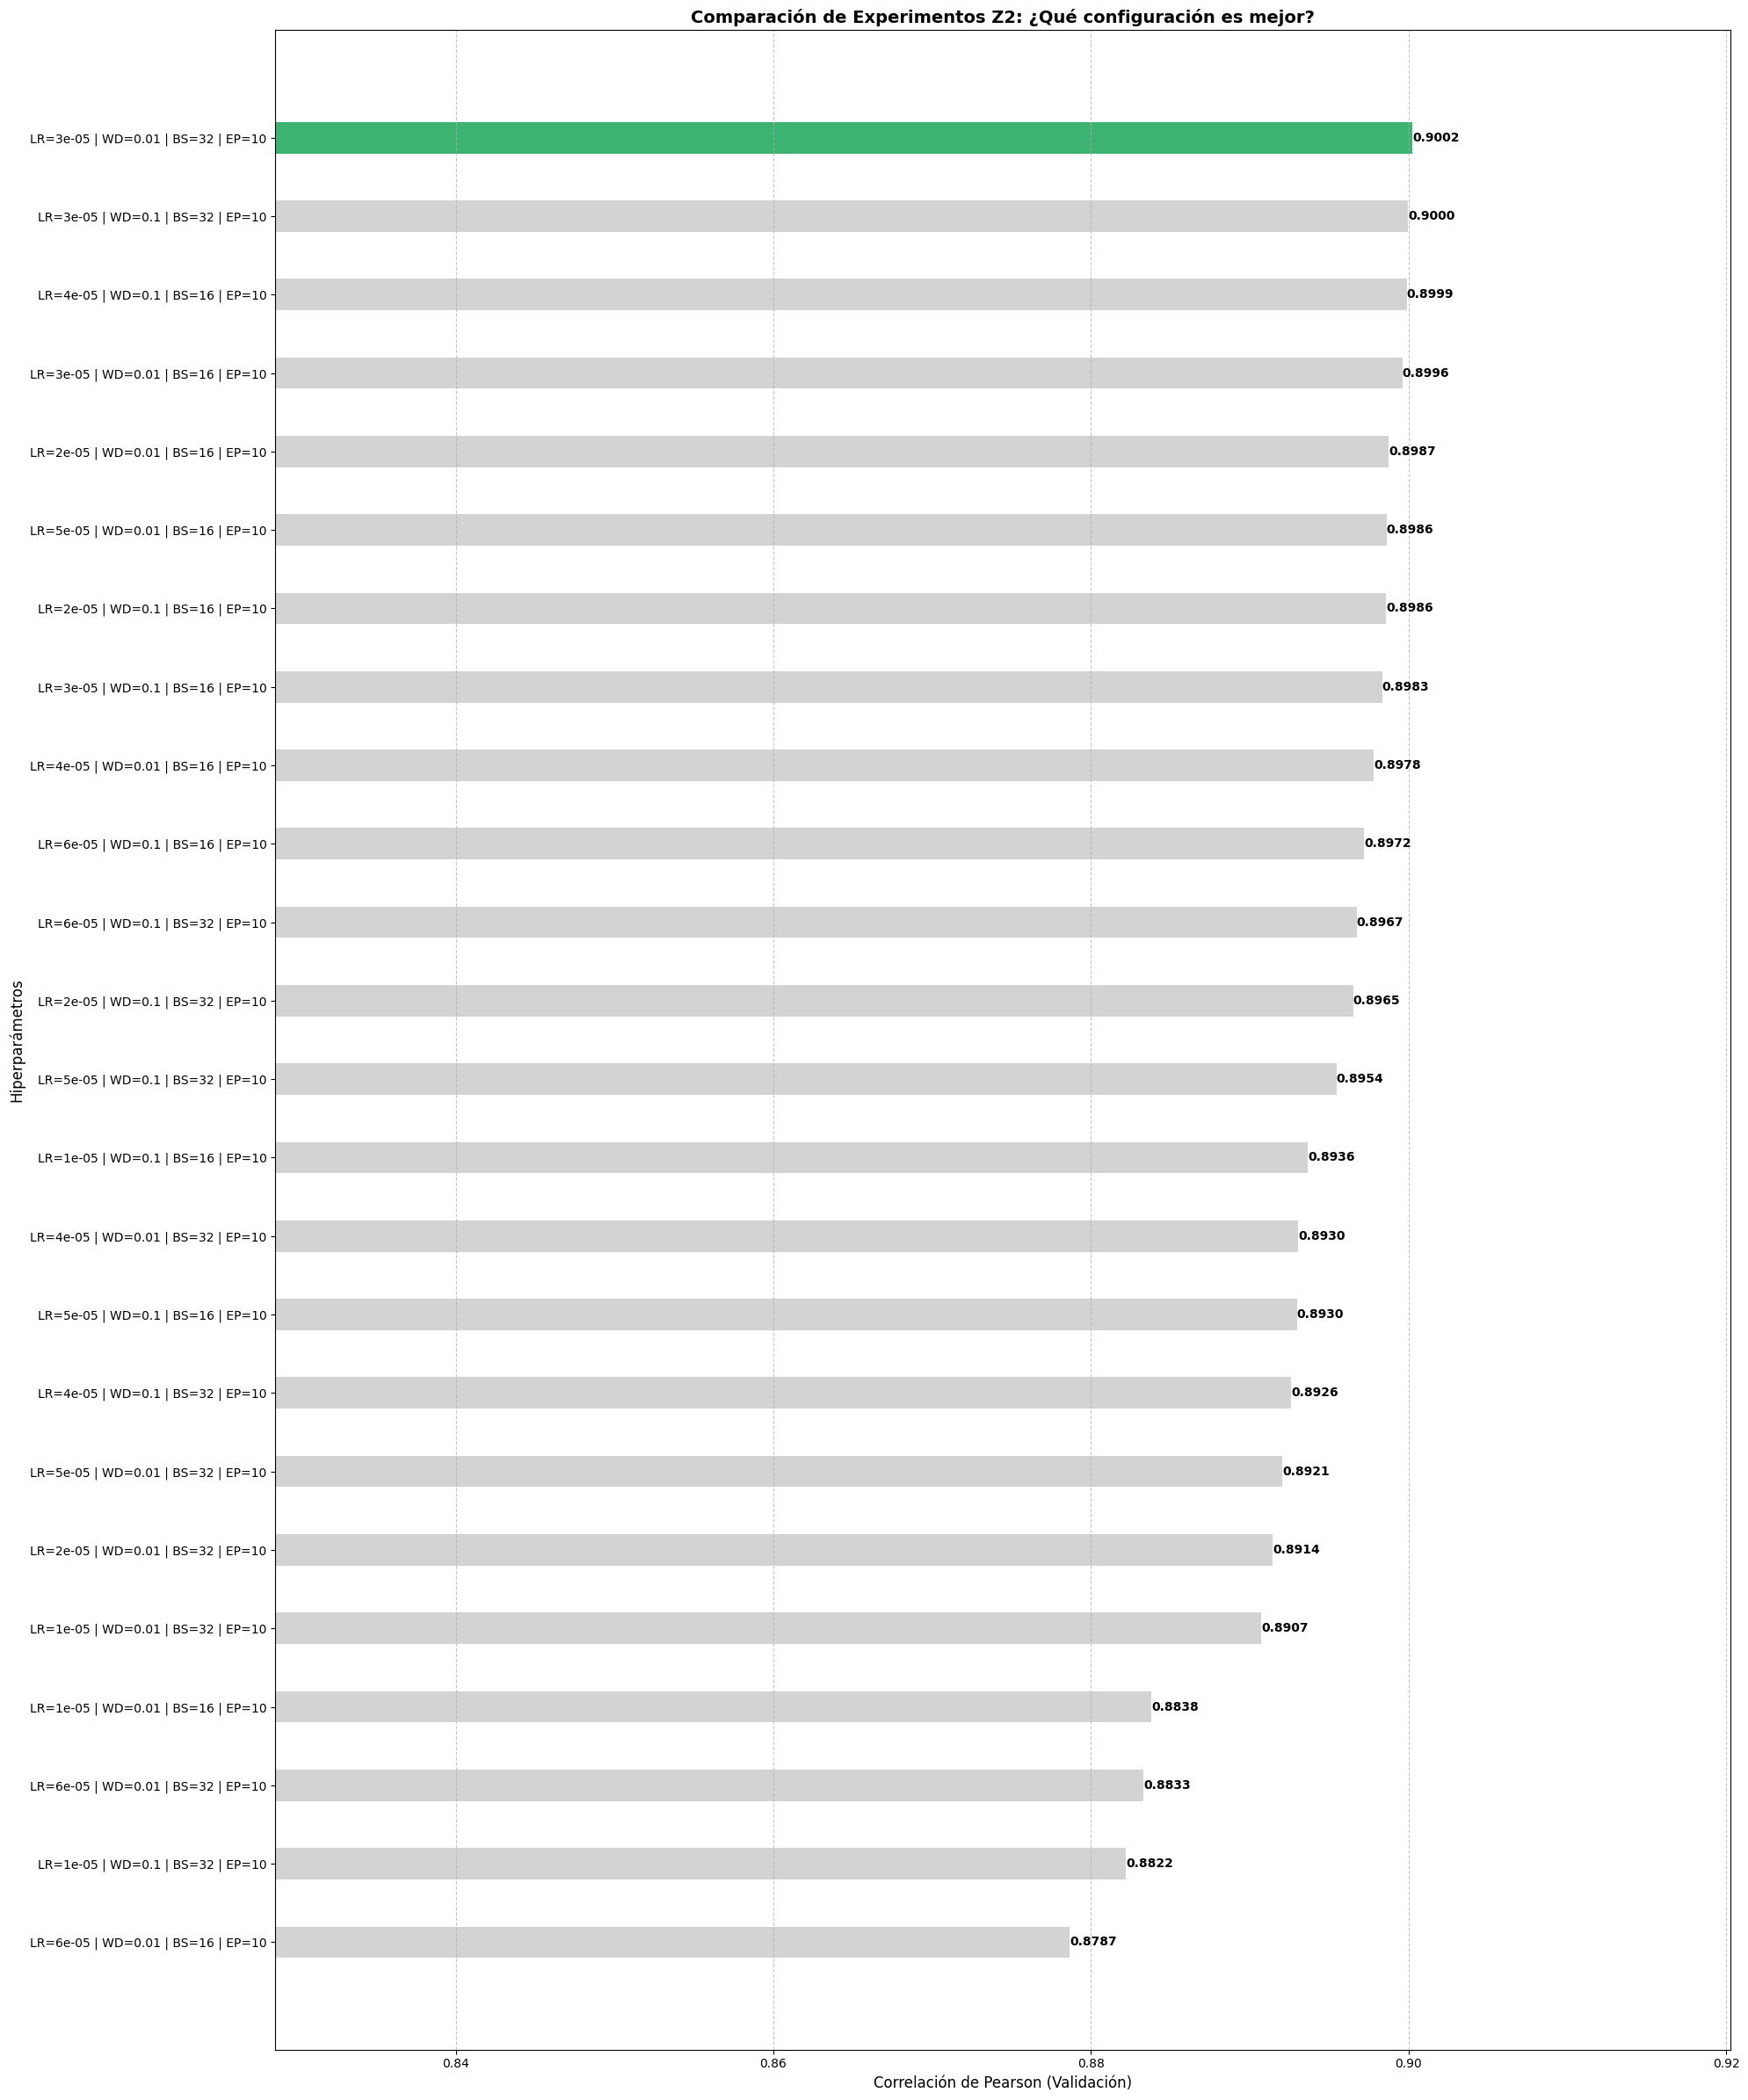

Gráfica guardada como 'grafica_grid_search_z2_bert.png'


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Recuperamos los datos (si existen)
if 'resultados_globales_bert' in globals() and resultados_globales_bert:
    df_plot = pd.DataFrame(resultados_globales_bert)

    # Creamos una etiqueta legible para cada barra
    df_plot['Config'] = df_plot.apply(lambda x: f"LR={x['LR']} | WD={x['Weight Decay']} | BS={x['Batch Size']} | EP={x['Epochs']}", axis=1)

    # Ordenamos de mejor a peor
    df_plot = df_plot.sort_values('Pearson (Val)', ascending=True)

    # 2. Configuración del Gráfico
    plt.figure(figsize=(20, 24))

    # Colores: Destacamos el mejor en verde, los demás en gris
    colores = ['lightgray'] * (len(df_plot) - 1) + ['mediumseagreen']

    barras = plt.barh(df_plot['Config'], df_plot['Pearson (Val)'], color=colores,height=0.4)

    # 3. Estética
    plt.xlabel('Correlación de Pearson (Validación)', fontsize=12)
    plt.ylabel('Hiperparámetros', fontsize=12)
    plt.title('Comparación de Experimentos Z2: ¿Qué configuración es mejor?', fontsize=14, fontweight='bold')

    # Ajustamos los límites del eje X para que se aprecien las diferencias
    # (Como todos estarán cerca de 0.8, empezamos en 0.7 para hacer "zoom")
    min_score = df_plot['Pearson (Val)'].min()
    plt.xlim(min_score - 0.05, df_plot['Pearson (Val)'].max() + 0.02)

    # 4. Añadir el valor exacto en cada barra
    for barra in barras:
        width = barra.get_width()
        plt.text(width, barra.get_y() + barra.get_height()/2,
                 f'{width:.4f}',
                 ha='left', va='center', fontweight='bold') # Removed padding=5

    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Mostrar y Guardar (para el informe)
    plt.savefig("grafica_grid_search_z2_bert.png", dpi=300) # Se guarda en la carpeta de archivos
    plt.show()
    print("Gráfica guardada como 'grafica_grid_search_z2_bert.png'")

else:
    print("No hay resultados en memoria. Ejecuta primero el entrenamiento (Grid Search).")

In [ ]:
resultados_val_ing.append({"Modelo": "BERT", "Pearson (Val)": 0.9002})

Hemos encontrado una tasa de acierto de 0.9002 con el modelo de tipo BERT con hiperparámetros lr=3e-5 (que ha demostrado ser el mejor generalmente para este modelo), bs=32 y wd=0.01 (que han sido generalmente buenos para todos los bert que hemos probado). Para Z2 nos quedamos con este modelo que es el que mejores resultados nos ha dado para el conjunto de validación.

#### Comparación de modelos para los resultados de validación del dataset en inglés

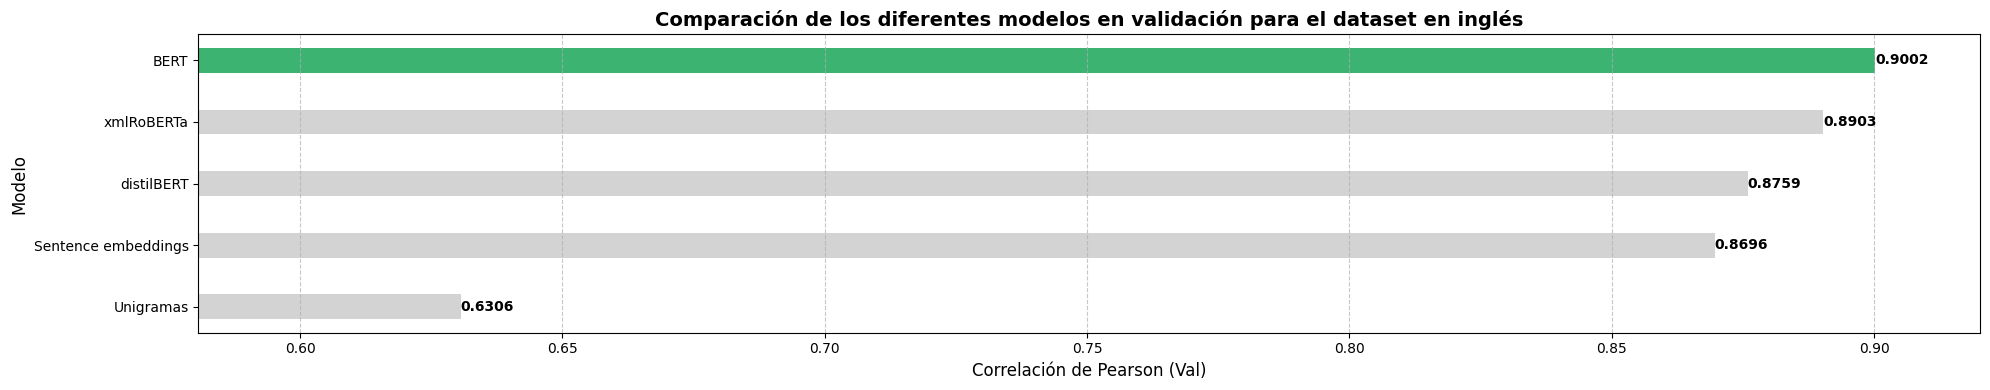

Gráfica guardada como 'grafica_resultados_val_ing.png'


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Recuperamos los datos (si existen)
if 'resultados_val_ing' in globals() and resultados_val_ing:
    df_plot = pd.DataFrame(resultados_val_ing)

    # Creamos una etiqueta legible para cada barra
    df_plot['Config'] = df_plot.apply(lambda x: f"{x['Modelo']}", axis=1)

    # Ordenamos de mejor a peor
    df_plot = df_plot.sort_values('Pearson (Val)', ascending=True)

    # 2. Configuración del Gráfico
    plt.figure(figsize=(20, 4))

    # Colores: Destacamos el mejor en verde, los demás en gris
    colores = ['lightgray'] * (len(df_plot) - 1) + ['mediumseagreen']

    barras = plt.barh(df_plot['Config'], df_plot['Pearson (Val)'], color=colores,height=0.4)

    # 3. Estética
    plt.xlabel('Correlación de Pearson (Val)', fontsize=12)
    plt.ylabel('Modelo', fontsize=12)
    plt.title('Comparación de los diferentes modelos en validación para el dataset en inglés', fontsize=14, fontweight='bold')

    # Ajustamos los límites del eje X para que se aprecien las diferencias
    # (Como todos estarán cerca de 0.8, empezamos en 0.7 para hacer "zoom")
    min_score = df_plot['Pearson (Val)'].min()
    plt.xlim(min_score - 0.05, df_plot['Pearson (Val)'].max() + 0.02)

    # 4. Añadir el valor exacto en cada barra
    for barra in barras:
        width = barra.get_width()
        plt.text(width, barra.get_y() + barra.get_height()/2,
                 f'{width:.4f}',
                 ha='left', va='center', fontweight='bold') # Removed padding=5

    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Mostrar y Guardar (para el informe)
    plt.savefig("grafica_resultados_val_ing.png", dpi=300) # Se guarda en la carpeta de archivos
    plt.show()
    print("Gráfica guardada como 'grafica_resultados_val_ing.png'")

else:
    print("No hay resultados en memoria. Ejecuta primero la validación.")

## Z3: Transferencia entre lenguas

### Carga y análisis del dataset en castellano.

In [10]:
dataset_cast = load_dataset("mteb/stsb_multi_mt", name="es", download_mode="force_redownload")
print("\nEstructura del Dataset en Castellano:")
print(dataset_cast)

train_df_cast = pd.DataFrame(dataset_cast['train'])
validation_df_cast = pd.DataFrame(dataset_cast['dev'])
test_df_cast = pd.DataFrame(dataset_cast['test'])

# Combinamos todos los scores para un análisis general
all_scores_cast = pd.concat([train_df_cast['similarity_score'], validation_df_cast['similarity_score'], test_df_cast['similarity_score']])

print("\n--- Estadísticas de 'similarity_score' (Todos los datos en castellano) ---")
print(all_scores_cast.describe())

print("\nEstadísticas detalladas (train en castellano):")
print(train_df_cast['similarity_score'].describe())

print("\n--- Ejemplo de datos (Train en castellano) ---")
# Mostramos los primeros 5 ejemplos para ver cómo son
print(train_df_cast.head())

README.md: 0.00B [00:00, ?B/s]

test/es.parquet:   0%|          | 0.00/77.7k [00:00<?, ?B/s]

train/es.parquet:   0%|          | 0.00/312k [00:00<?, ?B/s]

dev/es.parquet:   0%|          | 0.00/101k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/1379 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/5749 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/1500 [00:00<?, ? examples/s]


Estructura del Dataset en Castellano:
DatasetDict({
    test: Dataset({
        features: ['sentence1', 'sentence2', 'similarity_score', 'lang'],
        num_rows: 1379
    })
    train: Dataset({
        features: ['sentence1', 'sentence2', 'similarity_score', 'lang'],
        num_rows: 5749
    })
    dev: Dataset({
        features: ['sentence1', 'sentence2', 'similarity_score', 'lang'],
        num_rows: 1500
    })
})

--- Estadísticas de 'similarity_score' (Todos los datos en castellano) ---
count    8628.000000
mean        2.627518
std         1.485762
min         0.000000
25%         1.400000
50%         2.800000
75%         3.800000
max         5.000000
Name: similarity_score, dtype: float64

Estadísticas detalladas (train en castellano):
count    5749.000000
mean        2.700999
std         1.464398
min         0.000000
25%         1.500000
50%         3.000000
75%         3.800000
max         5.000000
Name: similarity_score, dtype: float64

--- Ejemplo de datos (Train en ca

### Prueba del funcionamiento de los modelos entrenados en inglés para el dataset en castellano.

In [ ]:
model_path = "/content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z1_ngrams/vectorizer.pkl"

# Cargar el modelo guardado
loaded_vectorizer = joblib.load(model_path)
print(f"Modelo cargado desde: {model_path}")

# Generar vectores para el conjunto de TEST
# IMPORTANTE: Usamos .transform(), NO .fit() o .fit_transform()
# Esto usa el vocabulario que el modelo ya aprendió durante el entrenamiento.
vectores_val_cast_s1 = loaded_vectorizer.transform(validation_df_cast['sentence1'])
vectores_val_cast_s2 = loaded_vectorizer.transform(validation_df_cast['sentence2'])

# Calcular Similitud del Coseno
# cosine_similarity devuelve una matriz, tomamos la diagonal para comparar pares (s1[0] con s2[0], s1[1] con s2[1]...)
similitudes_test = cosine_similarity(vectores_val_cast_s1, vectores_val_cast_s2).diagonal()

# Evaluar con Pearson
# Los scores originales están en el rango 0-5. La correlación de Pearson no se ve afectada por la escala,
# así que podemos comparar directamente nuestras similitudes (0-1) con los scores (0-5).
referencias_val = validation_df_cast['similarity_score']
pearson_score = pearson_metric.compute(predictions=similitudes_test, references=referencias_val)

print(f"RESULTADO FINAL EN VALIDACIÓN PARA EL CONJUNTO EN CASTELLANO (Z1 - N-Gramas)")
print(f"Correlación de Pearson: {pearson_score['pearsonr']:.4f}")

Modelo cargado desde: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z1_ngrams/vectorizer.pkl
RESULTADO FINAL EN VALIDACIÓN PARA EL CONJUNTO EN CASTELLANO (Z1 - N-Gramas)
Correlación de Pearson: 0.3429


In [ ]:
path_z1_st = "/content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z1_sentence_transformer"

# Cargar el modelo
model_st = SentenceTransformer(path_z1_st)
print(f"Modelo cargado desde {path_z1_st}")

# Generar Embeddings para el conjunto de TEST
# (Asumimos que ya tienes cargado el dataframe 'df_test' de la celda anterior.
#  Si no, vuelve a ejecutar la carga del dataset test con pandas).

# .encode() convierte automáticamente la lista de textos a vectores (numpy arrays)
embeddings_val_cast_s1 = model_st.encode(validation_df_cast['sentence1'].tolist(), show_progress_bar=True)
embeddings_val_cast_s2 = model_st.encode(validation_df_cast['sentence2'].tolist(), show_progress_bar=True)

# 4. Calcular Similitud del Coseno
# Igual que antes, usamos la diagonal para comparar pares correspondientes
similitudes_val_cast_st = cosine_similarity(embeddings_val_cast_s1, embeddings_val_cast_s2).diagonal()

# 5. Evaluar con Pearson
# La métrica de Pearson evalúa la correlación lineal, por lo que no importa que
# tus predicciones vayan de -1 a 1 y los labels de 0 a 5.
pearson_score_st_cast = pearson_metric.compute(predictions=similitudes_val_cast_st, references=validation_df_cast['similarity_score'])

print(f"RESULTADO FINAL EN VALIDACIÓN PARA EL CONJUNTO EN CASTELLANO (Z1 - Sentence Transformer)")
print(f"Correlación de Pearson: {pearson_score_st_cast['pearsonr']:.4f}")

Modelo cargado desde /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z1_sentence_transformer


Batches:   0%|          | 0/47 [00:00<?, ?it/s]

Batches:   0%|          | 0/47 [00:00<?, ?it/s]

RESULTADO FINAL EN VALIDACIÓN PARA EL CONJUNTO EN CASTELLANO (Z1 - Sentence Transformer)
Correlación de Pearson: 0.6921


In [ ]:
path_z2_bert = "/content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z2_finetunning_bert"
# Load the model and tokenizer from the final output_dir for evaluation
model_z2_bert = AutoModelForSequenceClassification.from_pretrained(path_z2_bert)
tokenizer_z2_bert = AutoTokenizer.from_pretrained(path_z2_bert)

#  Preprocesar datos en Español
# Usamos el tokenizador cargado (el de Z2 Bert) para procesar el texto en español.
def preprocess_function(examples):
    return tokenizer_z2_bert(examples['sentence1'], examples['sentence2'], truncation=True, max_length=128)

encoded_dataset_cast = dataset_cast.map(preprocess_function, batched=True)

# Renombramos la columna 'similarity_score' a 'labels'
encoded_dataset_cast = encoded_dataset_cast.rename_column("similarity_score", "labels")
encoded_dataset_cast.set_format("torch") # Ensure format is set after renaming

# Configurar Evaluador
pearson_metric = evaluate.load("pearsonr")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    # En regresión, las predicciones pueden tener forma (N, 1), aplanamos a (N,)
    predictions = predictions[:, 0]
    return pearson_metric.compute(predictions=predictions, references=labels)

# Create minimal TrainingArguments for evaluation to ensure metrics are computed
eval_args = TrainingArguments(
    output_dir="/tmp/eval_output_z3", # Temporary directory for evaluation logs
    do_train=False,
    do_eval=True,
    per_device_eval_batch_size=32, # Use a reasonable batch size for evaluation
    metric_for_best_model="pearsonr", # Explicitly state the metric
    report_to="none", # Disable reporting to external services like Weights & Biases
    dataloader_num_workers=0,
    dataloader_pin_memory=False
)

trainer_eval = Trainer(
    model=model_z2_bert,
    args=eval_args, # Pass the evaluation arguments
    tokenizer=tokenizer_z2_bert,
    compute_metrics=compute_metrics,
)

# Ejecutar Evaluación y Predicciones
predicciones = trainer_eval.predict(encoded_dataset_cast['dev']).predictions[:, 0]

referencias = encoded_dataset_cast['dev']['labels']
computed_pearson_score = pearson_metric.compute(predictions=predicciones, references=referencias)

print(f"RESULTADO FINAL EN VALIDACIÓN PARA EL CONJUNTO EN CASTELLANO (Z2 - BERT)")

print(f" Correlación de Pearson: {computed_pearson_score['pearsonr']:.4f}")

# Análisis Cualitativo: Ver ejemplos concretos
print("\n Análisis de Ejemplos (Predicción vs Realidad):")
for i in range(5):
    print(f"Par #{i+1}:")
    print(f"  Oración 1: {dataset_cast['dev'][i]['sentence1']}")
    print(f"  Oración 2: {dataset_cast['dev'][i]['sentence2']}")
    # Access score from the 'labels' column in the encoded dataset
    print(f"  Score Real: {encoded_dataset_cast['dev'][i]['labels']:.2f}")
    print(f"  Predicción Z2: {predicciones[i]:.2f}")
    # Calculate difference using the 'labels' column
    diff = abs(encoded_dataset_cast['dev'][i]['labels'] - predicciones[i])
    print(f"  Diferencia: {diff:.2f}")
    print("-" * 40)


Map:   0%|          | 0/1379 [00:00<?, ? examples/s]

Map:   0%|          | 0/5749 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

/tmp/ipython-input-4210738766.py:38: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_eval = Trainer(


RESULTADO FINAL EN VALIDACIÓN PARA EL CONJUNTO EN CASTELLANO (Z2 - BERT)
 Correlación de Pearson: 0.7246

 Análisis de Ejemplos (Predicción vs Realidad):
Par #1:
  Oración 1: Un hombre con un casco está bailando.
  Oración 2: Un hombre con un casco está bailando.
  Score Real: 5.00
  Predicción Z2: 4.95
  Diferencia: 0.05
----------------------------------------
Par #2:
  Oración 1: Un niño pequeño está montando a caballo.
  Oración 2: Un niño está montando a caballo.
  Score Real: 4.75
  Predicción Z2: 4.46
  Diferencia: 0.29
----------------------------------------
Par #3:
  Oración 1: Un hombre está alimentando a una serpiente con un ratón.
  Oración 2: El hombre está alimentando a la serpiente con un ratón.
  Score Real: 5.00
  Predicción Z2: 4.48
  Diferencia: 0.52
----------------------------------------
Par #4:
  Oración 1: Una mujer está tocando la guitarra.
  Oración 2: Un hombre está tocando la guitarra.
  Score Real: 2.40
  Predicción Z2: 3.18
  Diferencia: 0.78
------------

In [ ]:
resultados_val_cast.append({"Modelo": "BERT (entrenado en inglés)", "Pearson (Val)": 0.7246})

In [ ]:
path_z2_roberta = "/content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z2_finetunning_roberta"
# Load the model and tokenizer from the final output_dir for evaluation
model_z2_roberta = AutoModelForSequenceClassification.from_pretrained(path_z2_roberta)
tokenizer_z2_roberta = AutoTokenizer.from_pretrained(path_z2_roberta)

#  Preprocesar datos en Español
# Usamos el tokenizador cargado (el de Z2 Bert) para procesar el texto en español.
def preprocess_function(examples):
    return tokenizer_z2_roberta(examples['sentence1'], examples['sentence2'], truncation=True, max_length=128)

encoded_dataset_cast = dataset_cast.map(preprocess_function, batched=True)

# Renombramos la columna 'similarity_score' a 'labels'
encoded_dataset_cast = encoded_dataset_cast.rename_column("similarity_score", "labels")
encoded_dataset_cast.set_format("torch") # Ensure format is set after renaming

# Configurar Evaluador
pearson_metric = evaluate.load("pearsonr")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    # En regresión, las predicciones pueden tener forma (N, 1), aplanamos a (N,)
    predictions = predictions[:, 0]
    return pearson_metric.compute(predictions=predictions, references=labels)

# Create minimal TrainingArguments for evaluation to ensure metrics are computed
eval_args = TrainingArguments(
    output_dir="/tmp/eval_output_z3", # Temporary directory for evaluation logs
    do_train=False,
    do_eval=True,
    per_device_eval_batch_size=32, # Use a reasonable batch size for evaluation
    metric_for_best_model="pearsonr", # Explicitly state the metric
    report_to="none", # Disable reporting to external services like Weights & Biases
    dataloader_num_workers=0,
    dataloader_pin_memory=False
)

trainer_eval = Trainer(
    model=model_z2_roberta,
    args=eval_args, # Pass the evaluation arguments
    tokenizer=tokenizer_z2_roberta,
    compute_metrics=compute_metrics,
)

# Ejecutar Evaluación y Predicciones
predicciones = trainer_eval.predict(encoded_dataset_cast['dev']).predictions[:, 0]

referencias = encoded_dataset_cast['dev']['labels']
computed_pearson_score = pearson_metric.compute(predictions=predicciones, references=referencias)

print(f"RESULTADO FINAL EN VALIDACIÓN PARA EL CONJUNTO EN CASTELLANO (Z2 - BERT)")

print(f" Correlación de Pearson: {computed_pearson_score['pearsonr']:.4f}")

# Análisis Cualitativo: Ver ejemplos concretos
print("\n Análisis de Ejemplos (Predicción vs Realidad):")
for i in range(5):
    print(f"Par #{i+1}:")
    print(f"  Oración 1: {dataset_cast['dev'][i]['sentence1']}")
    print(f"  Oración 2: {dataset_cast['dev'][i]['sentence2']}")
    # Access score from the 'labels' column in the encoded dataset
    print(f"  Score Real: {encoded_dataset_cast['dev'][i]['labels']:.2f}")
    print(f"  Predicción Z2: {predicciones[i]:.2f}")
    # Calculate difference using the 'labels' column
    diff = abs(encoded_dataset_cast['dev'][i]['labels'] - predicciones[i])
    print(f"  Diferencia: {diff:.2f}")
    print("-" * 40)


Map:   0%|          | 0/1379 [00:00<?, ? examples/s]

Map:   0%|          | 0/5749 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

/tmp/ipython-input-49927650.py:38: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_eval = Trainer(


RESULTADO FINAL EN VALIDACIÓN PARA EL CONJUNTO EN CASTELLANO (Z2 - BERT)
 Correlación de Pearson: 0.8608

 Análisis de Ejemplos (Predicción vs Realidad):
Par #1:
  Oración 1: Un hombre con un casco está bailando.
  Oración 2: Un hombre con un casco está bailando.
  Score Real: 5.00
  Predicción Z2: 4.88
  Diferencia: 0.12
----------------------------------------
Par #2:
  Oración 1: Un niño pequeño está montando a caballo.
  Oración 2: Un niño está montando a caballo.
  Score Real: 4.75
  Predicción Z2: 4.84
  Diferencia: 0.09
----------------------------------------
Par #3:
  Oración 1: Un hombre está alimentando a una serpiente con un ratón.
  Oración 2: El hombre está alimentando a la serpiente con un ratón.
  Score Real: 5.00
  Predicción Z2: 4.91
  Diferencia: 0.09
----------------------------------------
Par #4:
  Oración 1: Una mujer está tocando la guitarra.
  Oración 2: Un hombre está tocando la guitarra.
  Score Real: 2.40
  Predicción Z2: 2.80
  Diferencia: 0.40
------------

In [ ]:
resultados_val_cast.append({"Modelo": "RoBERTa (entrenado en inglés)", "Pearson (Val)": 0.8608})

### Entrenamiento de un modelo multilingüe

#### Representación basada en sentence embeddings con un modelo multilingüe

In [ ]:
# Cargamos el modelo de Sentence Transformers, específicamente entrenado para crear embeddings de oraciones.
sdistil_model = SentenceTransformer('distiluse-base-multilingual-cased-v2')

# Función para calcular la similitud en un split. Usamos el modelo .encode() (encoder)
def calcular_similitud_sdistil(dataset_split):
    # Obtenemos las listas de oraciones
    oraciones1 = dataset_split['sentence1']
    oraciones2 = dataset_split['sentence2']

    # Convertimos las oraciones en vectores (embeddings)
    embeddings1 = sdistil_model.encode(oraciones1)
    embeddings2 = sdistil_model.encode(oraciones2)
    # devuelve los embeddings como tensores de PyTorch

    # Calculamos la similitud del coseno, esta vez con la función óptima para trabajar con tensores
    similitudes = util.cos_sim(embeddings1, embeddings2).diagonal()

    # El modelo de SBERT devuelve valores de -1 a 1 y el dataset tiene scores de 0 a 5.
    # Para comparar, re-escalamos nuestras predicciones al rango [0, 5].

    # Escalado Min-Max: (valor - min_antiguo) / (max_antiguo - min_antiguo) * (max_nuevo - min_nuevo) + min_nuevo
    predicciones_escaladas = (similitudes + 1) / 2 * 5

    return predicciones_escaladas


# Obtener predicciones para el conjunto de validación
predicciones_sdistil_dev = calcular_similitud_sdistil(dataset_cast['dev'])

# Evaluar con Correlación de Pearson
referencias_dev = dataset_cast['dev']['similarity_score']

resultado_sdistil_dev = pearson_metric.compute(predictions=predicciones_sdistil_dev, references=referencias_dev)

print("\n========================================================")
print("Resultados VALIDACION - Representación basada en sentence embeddings")
print(f"Correlación de Pearson: {resultado_sdistil_dev['pearsonr']:.4f}")
print("========================================================")

modules.json:   0%|          | 0.00/341 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/610 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/1.58M [00:00<?, ?B/s]


Resultados VALIDACION - Representación basada en sentence embeddings
Correlación de Pearson: 0.7936


In [ ]:
path_z3_st_distil = f"{base_path}/z3_st_distil_cast"
sdistil_model.save(path_z3_st_distil)
print(f"Modelo Z3 (ST Distil) guardado en: {path_z3_st_distil}")

Modelo Z3 (ST Distil) guardado en: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z3_st_distil_cast


In [ ]:
resultados_val_cast.append({"Modelo": "Sentence embeddings (entrenado en castellano)", "Pearson (Val)": 0.7936})

In [ ]:
# Cargamos el modelo de Sentence Transformers, específicamente entrenado para crear embeddings de oraciones.
slabse_model = SentenceTransformer('LaBSE')

# Función para calcular la similitud en un split. Usamos el modelo .encode() (encoder)
def calcular_similitud_slabse(dataset_split):
    # Obtenemos las listas de oraciones
    oraciones1 = dataset_split['sentence1']
    oraciones2 = dataset_split['sentence2']

    # Convertimos las oraciones en vectores (embeddings)
    embeddings1 = slabse_model.encode(oraciones1)
    embeddings2 = slabse_model.encode(oraciones2)
    # devuelve los embeddings como tensores de PyTorch

    # Calculamos la similitud del coseno, esta vez con la función óptima para trabajar con tensores
    similitudes = util.cos_sim(embeddings1, embeddings2).diagonal()

    # El modelo de SBERT devuelve valores de -1 a 1 y el dataset tiene scores de 0 a 5.
    # Para comparar, re-escalamos nuestras predicciones al rango [0, 5].

    # Escalado Min-Max: (valor - min_antiguo) / (max_antiguo - min_antiguo) * (max_nuevo - min_nuevo) + min_nuevo
    predicciones_escaladas = (similitudes + 1) / 2 * 5

    return predicciones_escaladas


# Obtener predicciones para el conjunto de validación
predicciones_slabse_dev = calcular_similitud_slabse(dataset_cast['dev'])

# Evaluar con Correlación de Pearson
referencias_dev = dataset_cast['dev']['similarity_score']

resultado_slabse_dev = pearson_metric.compute(predictions=predicciones_slabse_dev, references=referencias_dev)

print("\n========================================================")
print("Resultados VALIDACION - Representación basada en sentence embeddings")
print(f"Correlación de Pearson: {resultado_slabse_dev['pearsonr']:.4f}")
print("========================================================")

modules.json:   0%|          | 0.00/461 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/804 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/2.36M [00:00<?, ?B/s]


Resultados VALIDACION - Representación basada en sentence embeddings
Correlación de Pearson: 0.7291


In [ ]:
path_z3_st_slabse = f"{base_path}/z3_st_labse_cast"
slabse_model.save(path_z3_st_slabse)
print(f"Modelo Z3 (ST LaBSE) guardado en: {path_z3_st_slabse}")

Modelo Z3 (ST LaBSE) guardado en: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z3_st_labse_cast


#### Ajuste fino de un modelo multilingüe xmlRoBERTa

In [ ]:
model_checkpoint = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

# Función de preprocesamiento: Tokeniza las dos oraciones JUNTAS
def preprocess_function(examples):
    # El tokenizador de BERT añade automáticamente los tokens especiales:
    # [CLS] sentence1 [SEP] sentence2 [SEP]
    return tokenizer(examples['sentence1'], examples['sentence2'], truncation=True)

# Aplicamos la tokenización a todo el dataset
encoded_dataset_cast = dataset_cast.map(preprocess_function, batched=True)

# ¡IMPORTANTE! El 'Trainer' de Hugging Face espera que la etiqueta objetivo se llame 'labels'
# Renombramos la columna 'score' a 'labels'
encoded_dataset_cast = encoded_dataset_cast.rename_column("similarity_score", "labels")

# Eliminamos las columnas de texto originales para que no molesten al modelo
encoded_dataset_cast = encoded_dataset_cast.remove_columns(["sentence1", "sentence2", "lang"])
encoded_dataset_cast.set_format("torch")

print("Datos procesados. Ejemplo de entrada:", encoded_dataset_cast['train'][0])

pearson = evaluate.load("pearsonr")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    # El modelo devuelve una tupla, nos quedamos con el primer elemento (las predicciones)
    predictions = predictions[:, 0]
    return pearson.compute(predictions=predictions, references=labels)

# Lista para guardar resultados en memoria
resultados_globales_roberta_cast = []

# --- Configuración de rutas ---
# Carpeta en Drive donde SIEMPRE estará el mejor modelo encontrado hasta el momento
ruta_mejor_modelo_drive = f"{base_path}/z3_finetunning_roberta_cast"

def ejecutar_experimento_roberta_cast(lr, bs, wd, ep):
    torch.cuda.empty_cache()
    print(f"\n Iniciando Experimento: LR={lr} | BS={bs} | WD={wd} | EP={ep}")

    # 1. Configuración de Rutas
    run_name = f"z3robertacast_lr{lr}_bs{bs}_wd{wd}_ep{ep}"

    # GUARDA AQUÍ TEMPORALMENTE (Disco local de Colab, muy rápido, se borra al reiniciar)
    output_dir_temp = f"/content/temp_experiments/experiments/{run_name}"

    # 2. Reiniciar modelo
    model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=1).to(device)

    args = TrainingArguments(
        output_dir=output_dir_temp,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        learning_rate=lr,
        per_device_train_batch_size=bs,
        per_device_eval_batch_size=bs,
        num_train_epochs=ep,
        weight_decay=wd,
        load_best_model_at_end=True,
        metric_for_best_model="pearsonr",
        save_total_limit=1,
        report_to="none",
        fp16=True if device == "cuda" else False,
        overwrite_output_dir=True,
        dataloader_num_workers=0,
        dataloader_pin_memory=False
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=encoded_dataset_cast["train"],
        eval_dataset=encoded_dataset_cast["dev"],
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    # 3. Entrenar
    trainer.train()

    # Guardamos explícitamente el modelo final en la carpeta temporal
    trainer.save_model(output_dir_temp)

    # 4. Evaluar
    eval_metrics = trainer.evaluate()
    nota = eval_metrics["eval_pearsonr"]
    print(f">>> Resultado Experimento: {nota:.4f}")

    # --- 5. LÓGICA DE "REY DE LA COLINA" ---
    # Buscamos cuál es la mejor nota que hemos conseguido hasta ahora en experimentos anteriores
    mejor_nota_historica = -1.0
    if resultados_globales_roberta_cast:
        mejor_nota_historica = max(r["Pearson (Val)"] for r in resultados_globales_roberta_cast)

    estado = ""
    if nota > mejor_nota_historica:
        print(f" ¡NUEVO RÉCORD! ({nota:.4f} supera a {mejor_nota_historica:.4f})")
        print(f" Guardando copia de seguridad en Drive: {ruta_mejor_modelo_drive}...")

        # Borramos el anterior campeón del Drive si existe para no ocupar espacio
        if os.path.exists(ruta_mejor_modelo_drive):
            shutil.rmtree(ruta_mejor_modelo_drive)

        # Copiamos el nuevo campeón de Temp -> Drive
        shutil.copytree(output_dir_temp, ruta_mejor_modelo_drive)
        estado = " Récord (Guardado en Drive)"
    else:
        print(f" No supera el récord ({nota:.4f} vs {mejor_nota_historica:.4f}).")
        print(" Descartando archivos de este modelo...")
        estado = "Descartado"

    # 6. Limpieza: Borramos SIEMPRE la carpeta temporal local para no llenar Colab
    if os.path.exists(output_dir_temp):
        shutil.rmtree(output_dir_temp)

    # 7. Guardar resultados en la tabla (Esto sí lo guardamos siempre)
    resultados_globales_roberta_cast.append({
        "LR": lr, "Batch Size": bs, "Weight Decay": wd, "Epochs": ep,
        "Pearson (Val)": nota, "Estado": estado
    })

    return nota


Map:   0%|          | 0/1379 [00:00<?, ? examples/s]

Map:   0%|          | 0/5749 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Datos procesados. Ejemplo de entrada: {'labels': tensor(5.), 'input_ids': tensor([     0,    992, 176243,   1570,  45483,  62734,      5,      2,      2,
           992, 176243,   1570,  45483,  62734,      5,      2]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])}


##### Experimentos

In [ ]:
#Experimento 1 (LR=1e-5, BS=32, WD=0.01, EP=10)
nota = ejecutar_experimento_roberta_cast(lr=1e-5, bs=32, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=1e-05 | BS=32 | WD=0.01 | EP=10


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1019012764.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,2.651800,1.003272,0.760263
2,1.087100,0.827594,0.819386
3,0.794100,0.750293,0.843451
4,0.646400,0.660078,0.847928
5,0.561000,0.629191,0.854477
6,0.497100,0.719982,0.858594
7,0.450800,0.628855,0.859873
8,0.404600,0.653597,0.860628
9,0.389800,0.636001,0.859762
10,0.368500,0.640548,0.862148


>>> Resultado Experimento: 0.8621
 ¡NUEVO RÉCORD! (0.8621 supera a -1.0000)
 Guardando copia de seguridad en Drive: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z3_finetunning_roberta_cast...
Nota obtenida: 0.8621476741345189


In [ ]:
#Experimento 2 (LR=1e-5, BS=16, WD=0.01, EP=10)
nota = ejecutar_experimento_roberta_cast(lr=1e-5, bs=16, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=1e-05 | BS=16 | WD=0.01 | EP=10


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1019012764.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,2.151500,0.960944,0.794856
2,0.867100,0.723553,0.844000
3,0.646600,0.660937,0.845105
4,0.521200,0.660730,0.852773
5,0.427900,0.626526,0.860001
6,0.373300,0.703019,0.858485
7,0.318200,0.622649,0.866108
8,0.289100,0.641668,0.865865
9,0.258000,0.621897,0.865594


>>> Resultado Experimento: 0.8661
 ¡NUEVO RÉCORD! (0.8661 supera a 0.8621)
 Guardando copia de seguridad en Drive: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z3_finetunning_roberta_cast...
Nota obtenida: 0.8661082549809344


In [ ]:
#Experimento 3 (LR=1e-5, BS=16, WD=0.1, EP=10)
nota = ejecutar_experimento_roberta_cast(lr=1e-5, bs=16, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=1e-05 | BS=16 | WD=0.1 | EP=10


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1019012764.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,2.196300,0.940445,0.817601
2,0.800700,0.635736,0.850544
3,0.595000,0.643849,0.852184
4,0.487800,0.587221,0.860901
5,0.393100,0.604931,0.865175
6,0.345700,0.651287,0.869236
7,0.287000,0.566535,0.872523
8,0.257900,0.571526,0.869561
9,0.228400,0.598913,0.869323


>>> Resultado Experimento: 0.8725
 ¡NUEVO RÉCORD! (0.8725 supera a 0.8661)
 Guardando copia de seguridad en Drive: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z3_finetunning_roberta_cast...
Nota obtenida: 0.8725226939721521


In [ ]:
#Experimento 4 (LR=1e-5, BS=32, WD=0.1, EP=10)
nota = ejecutar_experimento_roberta_cast(lr=1e-5, bs=32, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=1e-05 | BS=32 | WD=0.1 | EP=10


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1019012764.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,2.885300,1.031367,0.783671
2,0.981300,0.751392,0.834601
3,0.735400,0.724072,0.850706
4,0.598800,0.627684,0.855974
5,0.533900,0.578809,0.862135
6,0.463900,0.627830,0.862925
7,0.406900,0.588454,0.867631
8,0.367200,0.588387,0.867374
9,0.347400,0.594601,0.866424


>>> Resultado Experimento: 0.8676
 No supera el récord (0.8676 vs 0.8725).
 Descartando archivos de este modelo...
Nota obtenida: 0.86763091028255


In [ ]:
#Experimento 5 (LR=2e-5, BS=16, WD=0.01, EP=10)
nota = ejecutar_experimento_roberta_cast(lr=2e-5, bs=16, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=2e-05 | BS=16 | WD=0.01 | EP=10


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1019012764.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.713200,1.371382,0.826177
2,0.721500,0.649245,0.853317
3,0.527100,0.682087,0.851202
4,0.408200,0.697115,0.851275


>>> Resultado Experimento: 0.8533
 No supera el récord (0.8533 vs 0.8725).
 Descartando archivos de este modelo...
Nota obtenida: 0.8533170991592779


In [ ]:
#Experimento 6 (LR=2e-5, BS=32, WD=0.01, EP=10)
nota = ejecutar_experimento_roberta_cast(lr=2e-5, bs=32, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=2e-05 | BS=32 | WD=0.01 | EP=10


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1019012764.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,2.203300,1.313183,0.783178
2,0.814900,0.902777,0.812419
3,0.652800,0.797995,0.833475
4,0.514100,0.697594,0.833558
5,0.413300,0.799470,0.845087
6,0.337000,0.740253,0.842657
7,0.286500,0.721502,0.848836
8,0.249800,0.657897,0.845268
9,0.225700,0.681252,0.840493


>>> Resultado Experimento: 0.8488
 No supera el récord (0.8488 vs 0.8725).
 Descartando archivos de este modelo...
Nota obtenida: 0.848836340940611


In [ ]:
#Experimento 7 (LR=2e-5, BS=16, WD=0.1, EP=10)
nota = ejecutar_experimento_roberta_cast(lr=2e-5, bs=16, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=2e-05 | BS=16 | WD=0.1 | EP=10


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1019012764.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.665700,1.086000,0.816129
2,0.733900,0.666375,0.853891
3,0.537500,0.653557,0.855352
4,0.423300,0.634472,0.856748
5,0.318300,0.618877,0.856246
6,0.250200,0.645098,0.865562
7,0.199800,0.596107,0.866620
8,0.167700,0.602203,0.862009
9,0.145000,0.613352,0.864814


>>> Resultado Experimento: 0.8666
 No supera el récord (0.8666 vs 0.8725).
 Descartando archivos de este modelo...
Nota obtenida: 0.8666196975119509


In [ ]:
#Experimento 8 (LR=2e-5, BS=32, WD=0.1, EP=10)
nota = ejecutar_experimento_roberta_cast(lr=2e-5, bs=32, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=2e-05 | BS=32 | WD=0.1 | EP=10


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1019012764.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,2.239600,0.928726,0.801975
2,0.789700,0.740468,0.852773
3,0.558100,0.614091,0.864131
4,0.427000,0.605374,0.857549
5,0.343300,0.607784,0.865560
6,0.276400,0.612964,0.865411
7,0.232800,0.606615,0.865698
8,0.203300,0.592792,0.867845
9,0.176600,0.587985,0.867096
10,0.164200,0.581936,0.868713


>>> Resultado Experimento: 0.8687
 No supera el récord (0.8687 vs 0.8725).
 Descartando archivos de este modelo...
Nota obtenida: 0.8687127287619812


In [ ]:
#Experimento 9 (LR=1.5e-5, BS=16, WD=0.01, EP=10)
nota = ejecutar_experimento_roberta_cast(lr=1.5e-5, bs=16, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=1.5e-05 | BS=16 | WD=0.01 | EP=10


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1019012764.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,2.186800,2.335116,0.758531
2,0.895400,0.740389,0.832899
3,0.672700,0.686172,0.838990
4,0.529600,0.750670,0.834515
5,0.424000,0.653454,0.848070
6,0.359100,0.810561,0.844705
7,0.293400,0.723798,0.840262


>>> Resultado Experimento: 0.8481
 No supera el récord (0.8481 vs 0.8725).
 Descartando archivos de este modelo...
Nota obtenida: 0.8480698161078769


In [ ]:
#Experimento 10 (LR=8e-6, BS=16, WD=0.01, EP=10)
nota = ejecutar_experimento_roberta_cast(lr=8e-6, bs=16, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=8e-06 | BS=16 | WD=0.01 | EP=10


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1019012764.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,2.160800,0.742602,0.824680
2,0.864200,0.644960,0.846237
3,0.673100,0.633327,0.850749
4,0.562800,0.659447,0.851414
5,0.482900,0.612720,0.856624
6,0.418900,0.635318,0.859630
7,0.359400,0.628622,0.862820
8,0.324400,0.603360,0.862559
9,0.302900,0.598050,0.862623


>>> Resultado Experimento: 0.8628
 No supera el récord (0.8628 vs 0.8725).
 Descartando archivos de este modelo...
Nota obtenida: 0.8628201915973921


##### Resultados

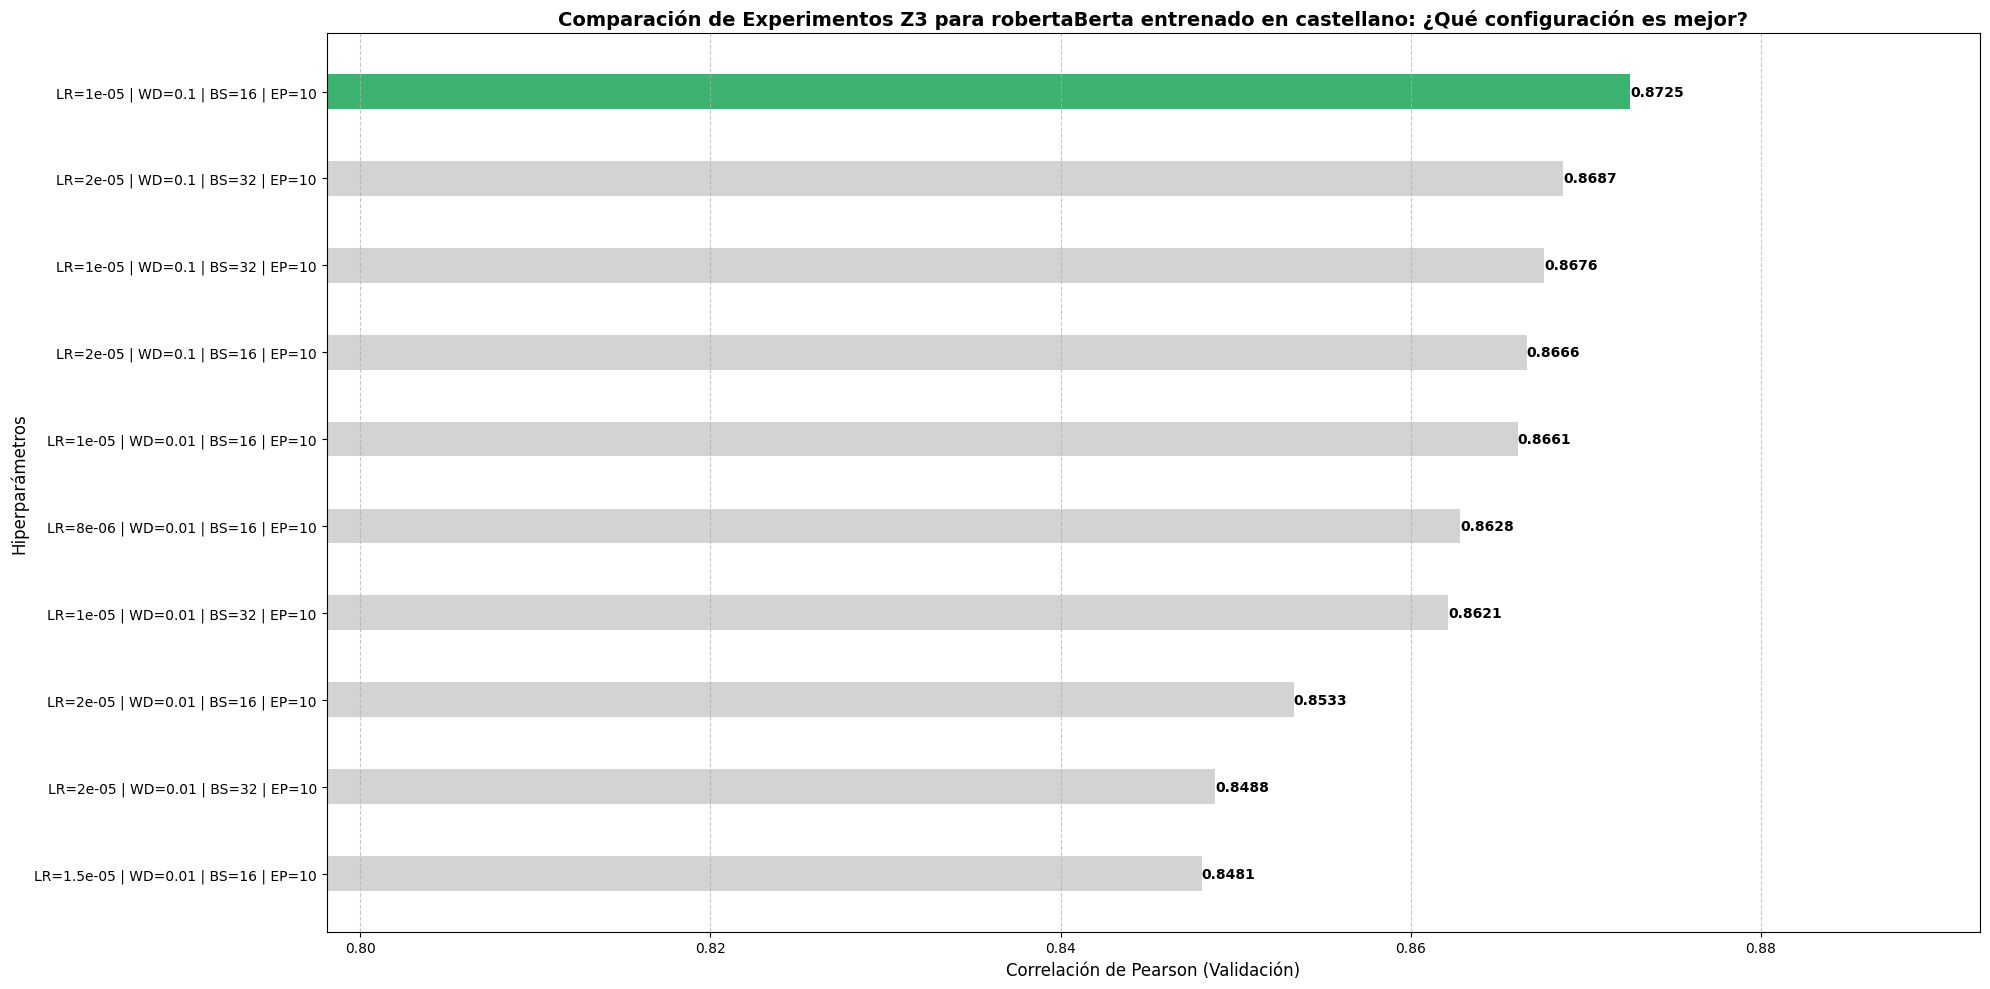

Gráfica guardada como 'grafica_grid_search_z3_roberta_cast.png'


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Recuperamos los datos (si existen)
if 'resultados_globales_roberta_cast' in globals() and resultados_globales_roberta_cast:
    df_plot = pd.DataFrame(resultados_globales_roberta_cast)

    # Creamos una etiqueta legible para cada barra
    df_plot['Config'] = df_plot.apply(lambda x: f"LR={x['LR']} | WD={x['Weight Decay']} | BS={x['Batch Size']} | EP={x['Epochs']}", axis=1)

    # Ordenamos de mejor a peor
    df_plot = df_plot.sort_values('Pearson (Val)', ascending=True)

    # 2. Configuración del Gráfico
    plt.figure(figsize=(20, 10))

    # Colores: Destacamos el mejor en verde, los demás en gris
    colores = ['lightgray'] * (len(df_plot) - 1) + ['mediumseagreen']

    barras = plt.barh(df_plot['Config'], df_plot['Pearson (Val)'], color=colores,height=0.4)

    # 3. Estética
    plt.xlabel('Correlación de Pearson (Validación)', fontsize=12)
    plt.ylabel('Hiperparámetros', fontsize=12)
    plt.title('Comparación de Experimentos Z3 para robertaBerta entrenado en castellano: ¿Qué configuración es mejor?', fontsize=14, fontweight='bold')

    # Ajustamos los límites del eje X para que se aprecien las diferencias
    # (Como todos estarán cerca de 0.8, empezamos en 0.7 para hacer "zoom")
    min_score = df_plot['Pearson (Val)'].min()
    plt.xlim(min_score - 0.05, df_plot['Pearson (Val)'].max() + 0.02)

    # 4. Añadir el valor exacto en cada barra
    for barra in barras:
        width = barra.get_width()
        plt.text(width, barra.get_y() + barra.get_height()/2,
                 f'{width:.4f}',
                 ha='left', va='center', fontweight='bold') # Removed padding=5

    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Mostrar y Guardar (para el informe)
    plt.savefig("grafica_grid_search_z3_roberta_cast.png", dpi=300) # Se guarda en la carpeta de archivos
    plt.show()
    print("Gráfica guardada como 'grafica_grid_search_z3_roberta_cast.png'")

else:
    print("No hay resultados en memoria. Ejecuta primero el entrenamiento (Grid Search).")

In [ ]:
resultados_val_cast.append({"Modelo": "RoBERTa (entrenado en castellano)", "Pearson (Val)": 0.8725})

#### Ajuste fino del modelo ya ajustado con datos del inglés

Ahora vamos a volver a entrenar el modelo xmlRoBERTa pero el que ya hemos entrenado anteriormente con datos del inglés para poder observar si obtenemos resultados mejores que entrenándolo directamente con datos en castellano.

In [ ]:
model_checkpoint = "/content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z2_finetunning_roberta"
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

# Función de preprocesamiento: Tokeniza las dos oraciones JUNTAS
def preprocess_function(examples):
    # El tokenizador de BERT añade automáticamente los tokens especiales:
    # [CLS] sentence1 [SEP] sentence2 [SEP]
    return tokenizer(examples['sentence1'], examples['sentence2'], truncation=True)

# Aplicamos la tokenización a todo el dataset
encoded_dataset_cast = dataset_cast.map(preprocess_function, batched=True)

# ¡IMPORTANTE! El 'Trainer' de Hugging Face espera que la etiqueta objetivo se llame 'labels'
# Renombramos la columna 'score' a 'labels'
encoded_dataset_cast = encoded_dataset_cast.rename_column("similarity_score", "labels")

# Eliminamos las columnas de texto originales para que no molesten al modelo
encoded_dataset_cast = encoded_dataset_cast.remove_columns(["sentence1", "sentence2", "lang"])
encoded_dataset_cast.set_format("torch")

print("Datos procesados. Ejemplo de entrada:", encoded_dataset_cast['train'][0])

pearson = evaluate.load("pearsonr")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    # El modelo devuelve una tupla, nos quedamos con el primer elemento (las predicciones)
    predictions = predictions[:, 0]
    return pearson.compute(predictions=predictions, references=labels)

# Lista para guardar resultados en memoria
resultados_globales_roberta_ingcast = []

# --- Configuración de rutas ---
# Carpeta en Drive donde SIEMPRE estará el mejor modelo encontrado hasta el momento
ruta_mejor_modelo_drive = f"{base_path}/z3_finetunning_roberta_ingcast"

def ejecutar_experimento_roberta_ingcast(lr, bs, wd, ep):
    torch.cuda.empty_cache()
    print(f"\n Iniciando Experimento: LR={lr} | BS={bs} | WD={wd} | EP={ep}")

    # 1. Configuración de Rutas
    run_name = f"z3robertaingcast_lr{lr}_bs{bs}_wd{wd}_ep{ep}"

    # GUARDA AQUÍ TEMPORALMENTE (Disco local de Colab, muy rápido, se borra al reiniciar)
    output_dir_temp = f"/content/temp_experiments/experiments/{run_name}"

    # 2. Reiniciar modelo
    model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=1).to(device)

    args = TrainingArguments(
        output_dir=output_dir_temp,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        learning_rate=lr,
        per_device_train_batch_size=bs,
        per_device_eval_batch_size=bs,
        num_train_epochs=ep,
        weight_decay=wd,
        load_best_model_at_end=True,
        metric_for_best_model="pearsonr",
        save_total_limit=1,
        report_to="none",
        fp16=True if device == "cuda" else False,
        overwrite_output_dir=True,
        dataloader_num_workers=0,
        dataloader_pin_memory=False
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=encoded_dataset_cast["train"],
        eval_dataset=encoded_dataset_cast["dev"],
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    # 3. Entrenar
    trainer.train()

    # Guardamos explícitamente el modelo final en la carpeta temporal
    trainer.save_model(output_dir_temp)

    # 4. Evaluar
    eval_metrics = trainer.evaluate()
    nota = eval_metrics["eval_pearsonr"]
    print(f">>> Resultado Experimento: {nota:.4f}")

    # --- 5. LÓGICA DE "REY DE LA COLINA" ---
    # Buscamos cuál es la mejor nota que hemos conseguido hasta ahora en experimentos anteriores
    mejor_nota_historica = -1.0
    if resultados_globales_roberta_ingcast:
        mejor_nota_historica = max(r["Pearson (Val)"] for r in resultados_globales_roberta_ingcast)

    estado = ""
    if nota > mejor_nota_historica:
        print(f" ¡NUEVO RÉCORD! ({nota:.4f} supera a {mejor_nota_historica:.4f})")
        print(f" Guardando copia de seguridad en Drive: {ruta_mejor_modelo_drive}...")

        # Borramos el anterior campeón del Drive si existe para no ocupar espacio
        if os.path.exists(ruta_mejor_modelo_drive):
            shutil.rmtree(ruta_mejor_modelo_drive)

        # Copiamos el nuevo campeón de Temp -> Drive
        shutil.copytree(output_dir_temp, ruta_mejor_modelo_drive)
        estado = " Récord (Guardado en Drive)"
    else:
        print(f" No supera el récord ({nota:.4f} vs {mejor_nota_historica:.4f}).")
        print(" Descartando archivos de este modelo...")
        estado = "Descartado"

    # 6. Limpieza: Borramos SIEMPRE la carpeta temporal local para no llenar Colab
    if os.path.exists(output_dir_temp):
        shutil.rmtree(output_dir_temp)

    # 7. Guardar resultados en la tabla (Esto sí lo guardamos siempre)
    resultados_globales_roberta_ingcast.append({
        "LR": lr, "Batch Size": bs, "Weight Decay": wd, "Epochs": ep,
        "Pearson (Val)": nota, "Estado": estado
    })

    return nota


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Map:   0%|          | 0/1379 [00:00<?, ? examples/s]

Map:   0%|          | 0/5749 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Datos procesados. Ejemplo de entrada: {'labels': tensor(5.), 'input_ids': tensor([     0,    992, 176243,   1570,  45483,  62734,      5,      2,      2,
           992, 176243,   1570,  45483,  62734,      5,      2]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])}


##### Experimentos

In [ ]:
#Experimento 1 (LR=1e-5, BS=32, WD=0.01, EP=10)
nota = ejecutar_experimento_roberta_ingcast(lr=1e-5, bs=32, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=1e-05 | BS=32 | WD=0.01 | EP=10


/tmp/ipython-input-1455570932.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,0.581900,0.569731,0.868822
2,0.468300,0.557702,0.869496
3,0.384400,0.552131,0.872916
4,0.322100,0.560754,0.873295
5,0.280300,0.545250,0.875422
6,0.243900,0.556058,0.875725
7,0.214900,0.591329,0.873958
8,0.194800,0.600180,0.874974


>>> Resultado Experimento: 0.8757
 ¡NUEVO RÉCORD! (0.8757 supera a -1.0000)
 Guardando copia de seguridad en Drive: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z3_finetunning_roberta_ingcast...
Nota obtenida: 0.8757254758668396


In [ ]:
#Experimento 2 (LR=1e-5, BS=16, WD=0.01, EP=10)
nota = ejecutar_experimento_roberta_ingcast(lr=1e-5, bs=16, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=1e-05 | BS=16 | WD=0.01 | EP=10


/tmp/ipython-input-1455570932.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,0.601300,0.573132,0.868552
2,0.463800,0.555372,0.873622
3,0.369800,0.542335,0.874375
4,0.296400,0.578653,0.866939
5,0.249700,0.538847,0.873609


>>> Resultado Experimento: 0.8744
 No supera el récord (0.8744 vs 0.8757).
 Descartando archivos de este modelo...
Nota obtenida: 0.8743752823130599


In [ ]:
#Experimento 3 (LR=1e-5, BS=16, WD=0.1, EP=10)
nota = ejecutar_experimento_roberta_ingcast(lr=1e-5, bs=16, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=1e-05 | BS=16 | WD=0.1 | EP=10


/tmp/ipython-input-1455570932.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,0.600600,0.571982,0.869894
2,0.457800,0.550355,0.873365
3,0.362900,0.570274,0.873435
4,0.293600,0.568385,0.870411
5,0.244700,0.545066,0.871753


>>> Resultado Experimento: 0.8734
 No supera el récord (0.8734 vs 0.8757).
 Descartando archivos de este modelo...
Nota obtenida: 0.8734350813533582


In [ ]:
#Experimento 4 (LR=1e-5, BS=32, WD=0.1, EP=10)
nota = ejecutar_experimento_roberta_ingcast(lr=1e-5, bs=32, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=1e-05 | BS=32 | WD=0.1 | EP=10


/tmp/ipython-input-1455570932.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,0.582100,0.575053,0.868254
2,0.469400,0.565665,0.867970
3,0.388100,0.549261,0.873317
4,0.326600,0.560821,0.871797
5,0.286500,0.547008,0.875600
6,0.246300,0.566170,0.874388
7,0.219100,0.587419,0.872855


>>> Resultado Experimento: 0.8756
 No supera el récord (0.8756 vs 0.8757).
 Descartando archivos de este modelo...
Nota obtenida: 0.8755995581842944


In [ ]:
#Experimento 5 (LR=2e-5, BS=16, WD=0.01, EP=10)
nota = ejecutar_experimento_roberta_ingcast(lr=2e-5, bs=16, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=2e-05 | BS=16 | WD=0.01 | EP=10


/tmp/ipython-input-1455570932.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,0.675700,0.732697,0.860782
2,0.485900,0.586071,0.870069
3,0.351100,0.581400,0.871617
4,0.265900,0.589484,0.870502
5,0.208700,0.555589,0.870025


>>> Resultado Experimento: 0.8716
 No supera el récord (0.8716 vs 0.8757).
 Descartando archivos de este modelo...
Nota obtenida: 0.8716174164846988


In [ ]:
#Experimento 6 (LR=2e-5, BS=32, WD=0.01, EP=10)
nota = ejecutar_experimento_roberta_ingcast(lr=2e-5, bs=32, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=2e-05 | BS=32 | WD=0.01 | EP=10


/tmp/ipython-input-1455570932.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,0.642200,0.561333,0.869984
2,0.466100,0.594630,0.872930
3,0.354800,0.546757,0.873411
4,0.284200,0.612117,0.872550
5,0.222500,0.557225,0.876527
6,0.177600,0.591064,0.877232
7,0.152900,0.589253,0.873189
8,0.132500,0.563106,0.873025


>>> Resultado Experimento: 0.8772
 ¡NUEVO RÉCORD! (0.8772 supera a 0.8757)
 Guardando copia de seguridad en Drive: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z3_finetunning_roberta_ingcast...
Nota obtenida: 0.8772315028965574


In [ ]:
#Experimento 7 (LR=2e-5, BS=16, WD=0.1, EP=10)
nota = ejecutar_experimento_roberta_ingcast(lr=2e-5, bs=16, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=2e-05 | BS=16 | WD=0.1 | EP=10


/tmp/ipython-input-1455570932.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,0.693600,0.810310,0.856666
2,0.496400,0.572734,0.869107
3,0.367900,0.604096,0.869470
4,0.273800,0.584226,0.868460
5,0.211300,0.554991,0.873017
6,0.176700,0.647784,0.871304
7,0.145700,0.582638,0.873614
8,0.115600,0.561952,0.872575
9,0.098900,0.579459,0.874517
10,0.091400,0.561038,0.874206


>>> Resultado Experimento: 0.8745
 No supera el récord (0.8745 vs 0.8772).
 Descartando archivos de este modelo...
Nota obtenida: 0.8745165832280833


In [ ]:
#Experimento 8 (LR=2e-5, BS=32, WD=0.1, EP=10)
nota = ejecutar_experimento_roberta_ingcast(lr=2e-5, bs=32, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=2e-05 | BS=32 | WD=0.1 | EP=10


/tmp/ipython-input-1455570932.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,0.650900,0.579070,0.871379
2,0.469000,0.609283,0.869426
3,0.355000,0.563684,0.875738
4,0.284000,0.603150,0.871160
5,0.221400,0.592416,0.871782


>>> Resultado Experimento: 0.8757
 No supera el récord (0.8757 vs 0.8772).
 Descartando archivos de este modelo...
Nota obtenida: 0.8757377945299464


In [ ]:
#Experimento 9 (LR=1.5e-5, BS=16, WD=0.01, EP=10)
nota = ejecutar_experimento_roberta_ingcast(lr=1.5e-5, bs=16, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=1.5e-05 | BS=16 | WD=0.01 | EP=10


/tmp/ipython-input-1455570932.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,0.642600,0.640525,0.863824
2,0.461300,0.602870,0.869977
3,0.353100,0.586394,0.870058
4,0.277600,0.600912,0.870524
5,0.226700,0.551982,0.871996
6,0.192300,0.605342,0.874239
7,0.163700,0.596113,0.874927
8,0.137400,0.555977,0.874612
9,0.119800,0.566901,0.876518
10,0.111200,0.555475,0.876481


>>> Resultado Experimento: 0.8765
 No supera el récord (0.8765 vs 0.8772).
 Descartando archivos de este modelo...
Nota obtenida: 0.8765184202240855


In [ ]:
#Experimento 10 (LR=8e-6, BS=16, WD=0.01, EP=10)
nota = ejecutar_experimento_roberta_ingcast(lr=8e-6, bs=16, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=8e-06 | BS=16 | WD=0.01 | EP=10


/tmp/ipython-input-1455570932.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,0.593500,0.554182,0.869450
2,0.463500,0.570029,0.872184
3,0.377700,0.551310,0.874748
4,0.316800,0.568080,0.870429
5,0.265800,0.539064,0.874236


>>> Resultado Experimento: 0.8747
 No supera el récord (0.8747 vs 0.8772).
 Descartando archivos de este modelo...
Nota obtenida: 0.8747482121180373


In [ ]:
resultados_globales_roberta_ingcast.append({
        "LR": 1e-5, "Batch Size": 32, "Weight Decay": 0.01, "Epochs": 10,
        "Pearson (Val)": 0.8757, "Estado": " Récord (Guardado en Drive)"
    })
resultados_globales_roberta_ingcast.append({
        "LR": 1e-5, "Batch Size": 16, "Weight Decay": 0.01, "Epochs": 10,
        "Pearson (Val)": 0.8744, "Estado": "Descartado"
    })
resultados_globales_roberta_ingcast.append({
        "LR": 1e-5, "Batch Size": 16, "Weight Decay": 0.1, "Epochs": 10,
        "Pearson (Val)": 0.8734, "Estado": "Descartado"
    })
resultados_globales_roberta_ingcast.append({
        "LR": 1e-5, "Batch Size": 32, "Weight Decay": 0.1, "Epochs": 10,
        "Pearson (Val)": 0.8756, "Estado": "Descartado"
    })
resultados_globales_roberta_ingcast.append({
        "LR": 2e-5, "Batch Size": 16, "Weight Decay": 0.01, "Epochs": 10,
        "Pearson (Val)": 0.8716, "Estado": "Descartado"
    })
resultados_globales_roberta_ingcast.append({
        "LR": 2e-5, "Batch Size": 32, "Weight Decay": 0.01, "Epochs": 10,
        "Pearson (Val)": 0.8772, "Estado": " Récord (Guardado en Drive)"
    })
resultados_globales_roberta_ingcast.append({
        "LR": 2e-5, "Batch Size": 16, "Weight Decay": 0.1, "Epochs": 10,
        "Pearson (Val)": 0.8745, "Estado": "Descartado"
    })
resultados_globales_roberta_ingcast.append({
        "LR": 2e-5, "Batch Size": 32, "Weight Decay": 0.1, "Epochs": 10,
        "Pearson (Val)": 0.8757, "Estado": "Descartado"
    })
resultados_globales_roberta_ingcast.append({
        "LR": 1.5e-5, "Batch Size": 16, "Weight Decay": 0.01, "Epochs": 10,
        "Pearson (Val)": 0.8765, "Estado": "Descartado"
    })
resultados_globales_roberta_ingcast.append({
        "LR": 8e-5, "Batch Size": 16, "Weight Decay": 0.01, "Epochs": 10,
        "Pearson (Val)": 0.8747, "Estado": "Descartado"
    })
mejor_nota_historica = 0.8772

##### Resultados

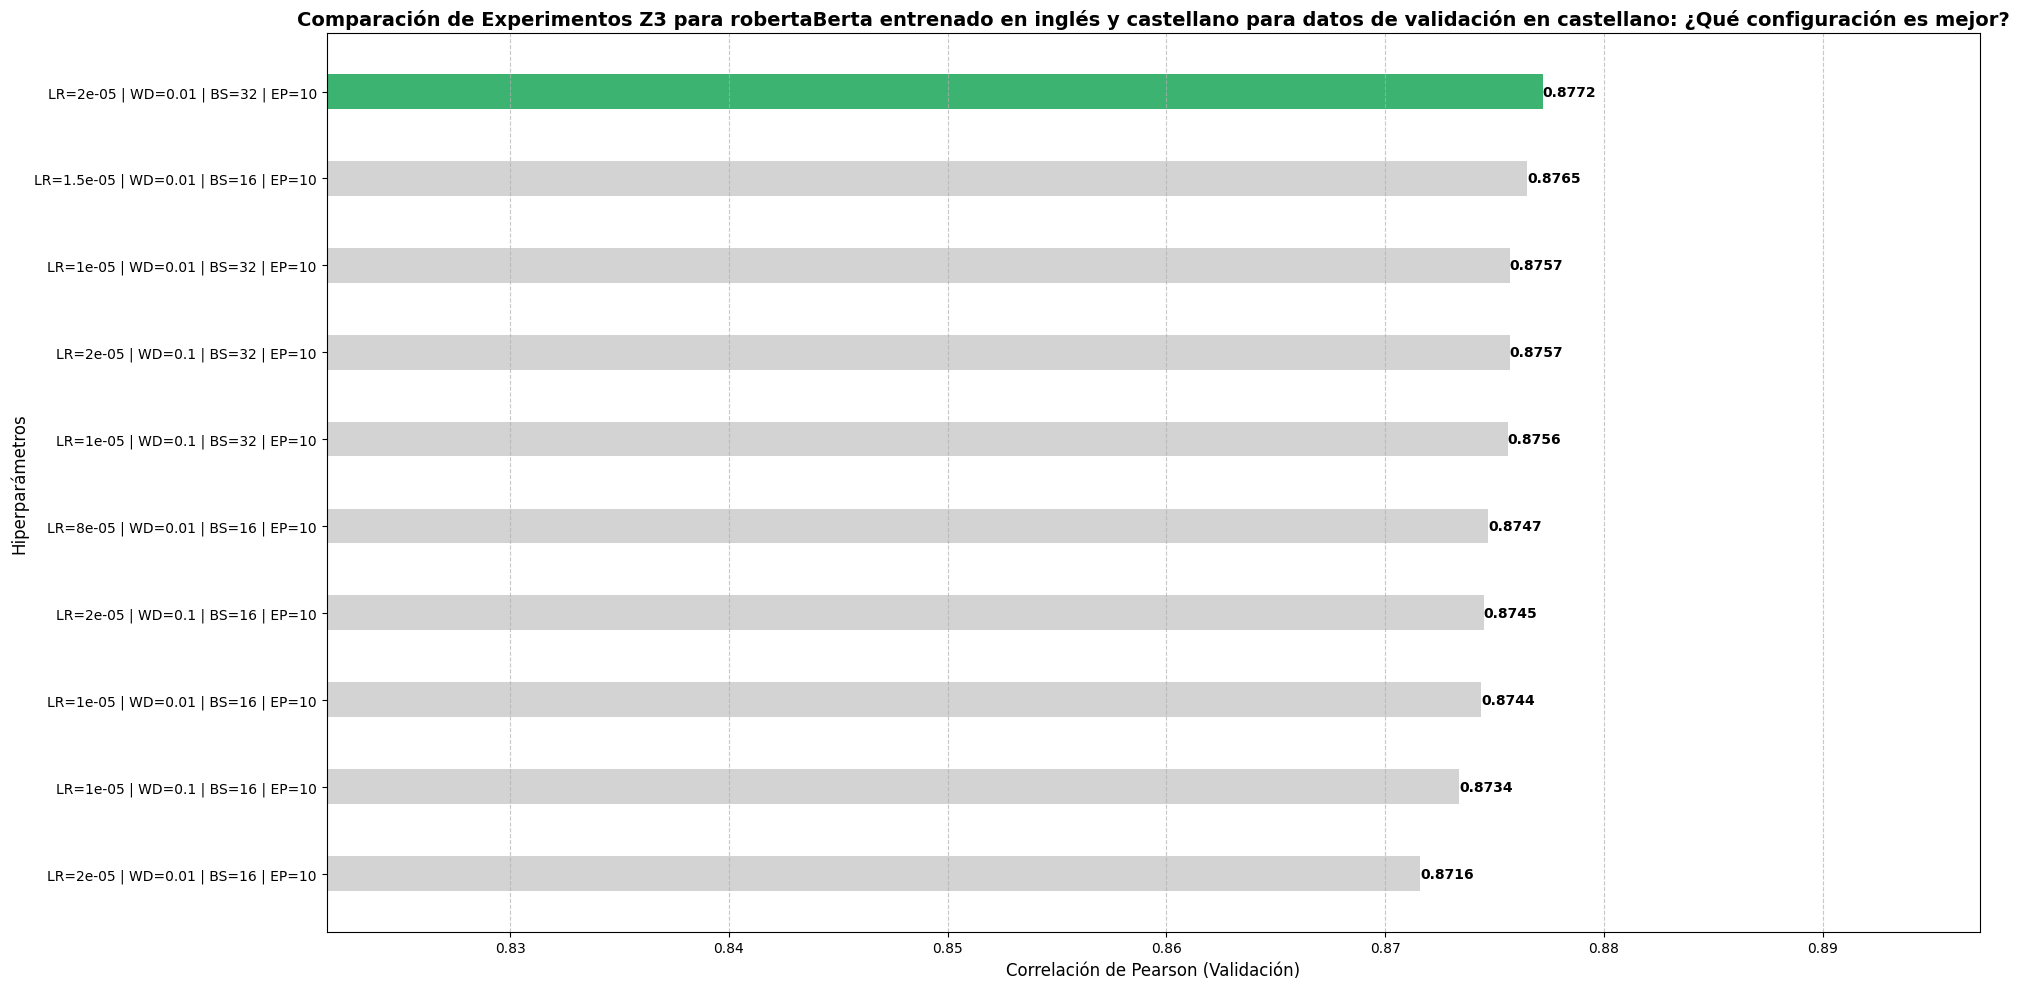

Gráfica guardada como 'grafica_grid_search_z3_roberta_ingcast.png'


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Recuperamos los datos (si existen)
if 'resultados_globales_roberta_ingcast' in globals() and resultados_globales_roberta_ingcast:
    df_plot = pd.DataFrame(resultados_globales_roberta_ingcast)

    # Creamos una etiqueta legible para cada barra
    df_plot['Config'] = df_plot.apply(lambda x: f"LR={x['LR']} | WD={x['Weight Decay']} | BS={x['Batch Size']} | EP={x['Epochs']}", axis=1)

    # Ordenamos de mejor a peor
    df_plot = df_plot.sort_values('Pearson (Val)', ascending=True)

    # 2. Configuración del Gráfico
    plt.figure(figsize=(20, 10))

    # Colores: Destacamos el mejor en verde, los demás en gris
    colores = ['lightgray'] * (len(df_plot) - 1) + ['mediumseagreen']

    barras = plt.barh(df_plot['Config'], df_plot['Pearson (Val)'], color=colores,height=0.4)

    # 3. Estética
    plt.xlabel('Correlación de Pearson (Validación)', fontsize=12)
    plt.ylabel('Hiperparámetros', fontsize=12)
    plt.title('Comparación de Experimentos Z3 para robertaBerta entrenado en inglés y castellano para datos de validación en castellano: ¿Qué configuración es mejor?', fontsize=14, fontweight='bold')

    # Ajustamos los límites del eje X para que se aprecien las diferencias
    # (Como todos estarán cerca de 0.8, empezamos en 0.7 para hacer "zoom")
    min_score = df_plot['Pearson (Val)'].min()
    plt.xlim(min_score - 0.05, df_plot['Pearson (Val)'].max() + 0.02)

    # 4. Añadir el valor exacto en cada barra
    for barra in barras:
        width = barra.get_width()
        plt.text(width, barra.get_y() + barra.get_height()/2,
                 f'{width:.4f}',
                 ha='left', va='center', fontweight='bold') # Removed padding=5

    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Mostrar y Guardar (para el informe)
    plt.savefig("grafica_grid_search_z3_roberta_ingcast.png", dpi=300) # Se guarda en la carpeta de archivos
    plt.show()
    print("Gráfica guardada como 'grafica_grid_search_z3_roberta_ingcast.png'")

else:
    print("No hay resultados en memoria. Ejecuta primero el entrenamiento (Grid Search).")

In [ ]:
resultados_val_cast.append({"Modelo": "RoBERTa (entrenado en inglés y castellano)", "Pearson (Val)": 0.8772})

#### Ajuste fino de un modelo ya ajustado con datos en inglés y en castellano para el italiano (para ver si mejora la tasa de acierto en castellano)

In [ ]:
dataset_it = load_dataset("mteb/stsb_multi_mt", name="it", download_mode="force_redownload")
print("\nEstructura del Dataset en Italiano:")
print(dataset_it)

train_df_it = pd.DataFrame(dataset_it['train'])
validation_df_it = pd.DataFrame(dataset_it['dev'])
test_df_it = pd.DataFrame(dataset_it['test'])

# Combinamos todos los scores para un análisis general
all_scores_it = pd.concat([train_df_it['similarity_score'], validation_df_it['similarity_score'], test_df_it['similarity_score']])

print("\n--- Estadísticas de 'similarity_score' (Todos los datos en italiano) ---")
print(all_scores_it.describe())

print("\nEstadísticas detalladas (train en italiano):")
print(train_df_it['similarity_score'].describe())

print("\n--- Ejemplo de datos (Train en italiano) ---")
# Mostramos los primeros 5 ejemplos para ver cómo son
print(train_df_it.head())

test/it.parquet:   0%|          | 0.00/78.6k [00:00<?, ?B/s]

train/it.parquet:   0%|          | 0.00/312k [00:00<?, ?B/s]

dev/it.parquet:   0%|          | 0.00/102k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/1379 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/5749 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/1500 [00:00<?, ? examples/s]


Estructura del Dataset en Italiano:
DatasetDict({
    test: Dataset({
        features: ['sentence1', 'sentence2', 'similarity_score', 'lang'],
        num_rows: 1379
    })
    train: Dataset({
        features: ['sentence1', 'sentence2', 'similarity_score', 'lang'],
        num_rows: 5749
    })
    dev: Dataset({
        features: ['sentence1', 'sentence2', 'similarity_score', 'lang'],
        num_rows: 1500
    })
})

--- Estadísticas de 'similarity_score' (Todos los datos en italiano) ---
count    8628.000000
mean        2.627518
std         1.485762
min         0.000000
25%         1.400000
50%         2.800000
75%         3.800000
max         5.000000
Name: similarity_score, dtype: float64

Estadísticas detalladas (train en italiano):
count    5749.000000
mean        2.700999
std         1.464398
min         0.000000
25%         1.500000
50%         3.000000
75%         3.800000
max         5.000000
Name: similarity_score, dtype: float64

--- Ejemplo de datos (Train en italiano

In [ ]:
model_checkpoint = "/content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z3_finetunning_roberta_ingcast"
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

# Función de preprocesamiento: Tokeniza las dos oraciones JUNTAS
def preprocess_function(examples):
    # El tokenizador de BERT añade automáticamente los tokens especiales:
    # [CLS] sentence1 [SEP] sentence2 [SEP]
    return tokenizer(examples['sentence1'], examples['sentence2'], truncation=True)

# Aplicamos la tokenización a todo el dataset
encoded_dataset_it = dataset_it.map(preprocess_function, batched=True)

# ¡IMPORTANTE! El 'Trainer' de Hugging Face espera que la etiqueta objetivo se llame 'labels'
# Renombramos la columna 'score' a 'labels'
encoded_dataset_it = encoded_dataset_it.rename_column("similarity_score", "labels")

# Eliminamos las columnas de texto originales para que no molesten al modelo
encoded_dataset_it = encoded_dataset_it.remove_columns(["sentence1", "sentence2", "lang"])
encoded_dataset_it.set_format("torch")

print("Datos procesados. Ejemplo de entrada:", encoded_dataset_it['train'][0])

pearson = evaluate.load("pearsonr")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    # El modelo devuelve una tupla, nos quedamos con el primer elemento (las predicciones)
    predictions = predictions[:, 0]
    return pearson.compute(predictions=predictions, references=labels)

# Lista para guardar resultados en memoria
resultados_globales_roberta_ingcastit = []

# --- Configuración de rutas ---
# Carpeta en Drive donde SIEMPRE estará el mejor modelo encontrado hasta el momento
ruta_mejor_modelo_drive = f"{base_path}/z3_finetunning_roberta_ingcastit"

def ejecutar_experimento_roberta_ingcastit(lr, bs, wd, ep):
    torch.cuda.empty_cache()
    print(f"\n Iniciando Experimento: LR={lr} | BS={bs} | WD={wd} | EP={ep}")

    # 1. Configuración de Rutas
    run_name = f"z3robertaingcastit_lr{lr}_bs{bs}_wd{wd}_ep{ep}"

    # GUARDA AQUÍ TEMPORALMENTE (Disco local de Colab, muy rápido, se borra al reiniciar)
    output_dir_temp = f"/content/temp_experiments/experiments/{run_name}"

    # 2. Reiniciar modelo
    model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=1).to(device)

    args = TrainingArguments(
        output_dir=output_dir_temp,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        learning_rate=lr,
        per_device_train_batch_size=bs,
        per_device_eval_batch_size=bs,
        num_train_epochs=ep,
        weight_decay=wd,
        load_best_model_at_end=True,
        metric_for_best_model="pearsonr",
        save_total_limit=1,
        report_to="none",
        fp16=True if device == "cuda" else False,
        overwrite_output_dir=True,
        dataloader_num_workers=0,
        dataloader_pin_memory=False
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=encoded_dataset_it["train"],
        eval_dataset=encoded_dataset_cast["dev"],
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    # 3. Entrenar
    trainer.train()

    # Guardamos explícitamente el modelo final en la carpeta temporal
    trainer.save_model(output_dir_temp)

    # 4. Evaluar
    eval_metrics = trainer.evaluate()
    nota = eval_metrics["eval_pearsonr"]
    print(f">>> Resultado Experimento: {nota:.4f}")

    # --- 5. LÓGICA DE "REY DE LA COLINA" ---
    # Buscamos cuál es la mejor nota que hemos conseguido hasta ahora en experimentos anteriores
    mejor_nota_historica = -1.0
    if resultados_globales_roberta_ingcastit:
        mejor_nota_historica = max(r["Pearson (Val)"] for r in resultados_globales_roberta_ingcastit)

    estado = ""
    if nota > mejor_nota_historica:
        print(f" ¡NUEVO RÉCORD! ({nota:.4f} supera a {mejor_nota_historica:.4f})")
        print(f" Guardando copia de seguridad en Drive: {ruta_mejor_modelo_drive}...")

        # Borramos el anterior campeón del Drive si existe para no ocupar espacio
        if os.path.exists(ruta_mejor_modelo_drive):
            shutil.rmtree(ruta_mejor_modelo_drive)

        # Copiamos el nuevo campeón de Temp -> Drive
        shutil.copytree(output_dir_temp, ruta_mejor_modelo_drive)
        estado = " Récord (Guardado en Drive)"
    else:
        print(f" No supera el récord ({nota:.4f} vs {mejor_nota_historica:.4f}).")
        print(" Descartando archivos de este modelo...")
        estado = "Descartado"

    # 6. Limpieza: Borramos SIEMPRE la carpeta temporal local para no llenar Colab
    if os.path.exists(output_dir_temp):
        shutil.rmtree(output_dir_temp)

    # 7. Guardar resultados en la tabla (Esto sí lo guardamos siempre)
    resultados_globales_roberta_ingcastit.append({
        "LR": lr, "Batch Size": bs, "Weight Decay": wd, "Epochs": ep,
        "Pearson (Val)": nota, "Estado": estado
    })

    return nota


Map:   0%|          | 0/1379 [00:00<?, ? examples/s]

Map:   0%|          | 0/5749 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Datos procesados. Ejemplo de entrada: {'labels': tensor(5.), 'input_ids': tensor([     0,    992,     10,   1357,     31,   1924,      8, 181989,    557,
             5,      2,      2,    992,     10,   1357,     31,   1924,      8,
        181989,    557,      5,      2]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])}


##### Experimentos

In [ ]:
#Experimento 1 (LR=1e-5, BS=32, WD=0.01, EP=10)
nota = ejecutar_experimento_roberta_ingcastit(lr=1e-5, bs=32, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=1e-05 | BS=32 | WD=0.01 | EP=10


/tmp/ipython-input-3156249846.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,0.459800,0.611550,0.868269
2,0.347700,0.585949,0.870785
3,0.282600,0.590110,0.869841
4,0.233700,0.604988,0.864650


>>> Resultado Experimento: 0.8708
 ¡NUEVO RÉCORD! (0.8708 supera a -1.0000)
 Guardando copia de seguridad en Drive: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z3_finetunning_roberta_ingcastit...
Nota obtenida: 0.8707850662996615


In [ ]:
#Experimento 2 (LR=1e-5, BS=16, WD=0.01, EP=10)
nota = ejecutar_experimento_roberta_ingcastit(lr=1e-5, bs=16, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=1e-05 | BS=16 | WD=0.01 | EP=10


/tmp/ipython-input-3156249846.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,0.484100,0.588996,0.871391
2,0.346400,0.611040,0.868928
3,0.262800,0.618116,0.865758


>>> Resultado Experimento: 0.8714
 ¡NUEVO RÉCORD! (0.8714 supera a 0.8708)
 Guardando copia de seguridad en Drive: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z3_finetunning_roberta_ingcastit...
Nota obtenida: 0.871390653458605


In [ ]:
#Experimento 3 (LR=1e-5, BS=16, WD=0.1, EP=10)
nota = ejecutar_experimento_roberta_ingcastit(lr=1e-5, bs=16, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=1e-05 | BS=16 | WD=0.1 | EP=10


/tmp/ipython-input-3156249846.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,0.482700,0.569416,0.873070
2,0.343200,0.619810,0.866701
3,0.266400,0.626892,0.862563


>>> Resultado Experimento: 0.8731
 ¡NUEVO RÉCORD! (0.8731 supera a 0.8714)
 Guardando copia de seguridad en Drive: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z3_finetunning_roberta_ingcastit...
Nota obtenida: 0.8730697398347468


In [ ]:
#Experimento 4 (LR=1e-5, BS=32, WD=0.1, EP=10)
nota = ejecutar_experimento_roberta_ingcastit(lr=1e-5, bs=32, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=1e-05 | BS=32 | WD=0.1 | EP=10


/tmp/ipython-input-3156249846.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,0.461000,0.605472,0.869218
2,0.346400,0.588585,0.869493
3,0.282400,0.586950,0.869408
4,0.231500,0.594783,0.865381


>>> Resultado Experimento: 0.8695
 No supera el récord (0.8695 vs 0.8731).
 Descartando archivos de este modelo...
Nota obtenida: 0.8694925478987315


In [ ]:
#Experimento 5 (LR=2e-5, BS=16, WD=0.01, EP=10)
nota = ejecutar_experimento_roberta_ingcastit(lr=2e-5, bs=16, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=2e-05 | BS=16 | WD=0.01 | EP=10


/tmp/ipython-input-3156249846.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,0.542000,0.850946,0.868770
2,0.384500,0.672658,0.856624
3,0.266100,0.605833,0.868123


>>> Resultado Experimento: 0.8688
 No supera el récord (0.8688 vs 0.8731).
 Descartando archivos de este modelo...
Nota obtenida: 0.8687699185660663


In [ ]:
#Experimento 6 (LR=2e-5, BS=32, WD=0.01, EP=10)
nota = ejecutar_experimento_roberta_ingcastit(lr=2e-5, bs=32, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=2e-05 | BS=32 | WD=0.01 | EP=10


/tmp/ipython-input-3156249846.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,0.506000,0.650148,0.866623
2,0.351300,0.656490,0.871577
3,0.262100,0.628495,0.869407
4,0.210600,0.577760,0.866669


>>> Resultado Experimento: 0.8716
 No supera el récord (0.8716 vs 0.8731).
 Descartando archivos de este modelo...
Nota obtenida: 0.8715772274824412


In [ ]:
#Experimento 7 (LR=2e-5, BS=16, WD=0.1, EP=10)
nota = ejecutar_experimento_roberta_ingcastit(lr=2e-5, bs=16, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=2e-05 | BS=16 | WD=0.1 | EP=10


/tmp/ipython-input-3156249846.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,0.544800,0.811210,0.868988
2,0.387900,0.665163,0.862630
3,0.276600,0.580248,0.868526


>>> Resultado Experimento: 0.8690
 No supera el récord (0.8690 vs 0.8731).
 Descartando archivos de este modelo...
Nota obtenida: 0.8689880778360151


In [ ]:
#Experimento 8 (LR=2e-5, BS=32, WD=0.1, EP=10)
nota = ejecutar_experimento_roberta_ingcastit(lr=2e-5, bs=32, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=2e-05 | BS=32 | WD=0.1 | EP=10


/tmp/ipython-input-3156249846.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,0.498500,0.606671,0.864065
2,0.350800,0.677671,0.869404
3,0.273000,0.639807,0.866312
4,0.205600,0.608646,0.862364


>>> Resultado Experimento: 0.8694
 No supera el récord (0.8694 vs 0.8731).
 Descartando archivos de este modelo...
Nota obtenida: 0.8694042828481312


In [ ]:
#Experimento 9 (LR=1.5e-5, BS=16, WD=0.01, EP=10)
nota = ejecutar_experimento_roberta_ingcastit(lr=1.5e-5, bs=16, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=1.5e-05 | BS=16 | WD=0.01 | EP=10


/tmp/ipython-input-3156249846.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,0.519300,0.659290,0.870378
2,0.360600,0.619802,0.864458
3,0.264000,0.610485,0.864692


>>> Resultado Experimento: 0.8704
 No supera el récord (0.8704 vs 0.8731).
 Descartando archivos de este modelo...
Nota obtenida: 0.870377915935082


In [ ]:
#Experimento 10 (LR=8e-6, BS=16, WD=0.01, EP=10)
nota = ejecutar_experimento_roberta_ingcastit(lr=8e-6, bs=16, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=8e-06 | BS=16 | WD=0.01 | EP=10


/tmp/ipython-input-3156249846.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,0.475400,0.585741,0.873501
2,0.343900,0.609953,0.868314
3,0.272400,0.625755,0.863274


>>> Resultado Experimento: 0.8735
 ¡NUEVO RÉCORD! (0.8735 supera a 0.8731)
 Guardando copia de seguridad en Drive: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z3_finetunning_roberta_ingcastit...
Nota obtenida: 0.8735006275925211


##### Resultados

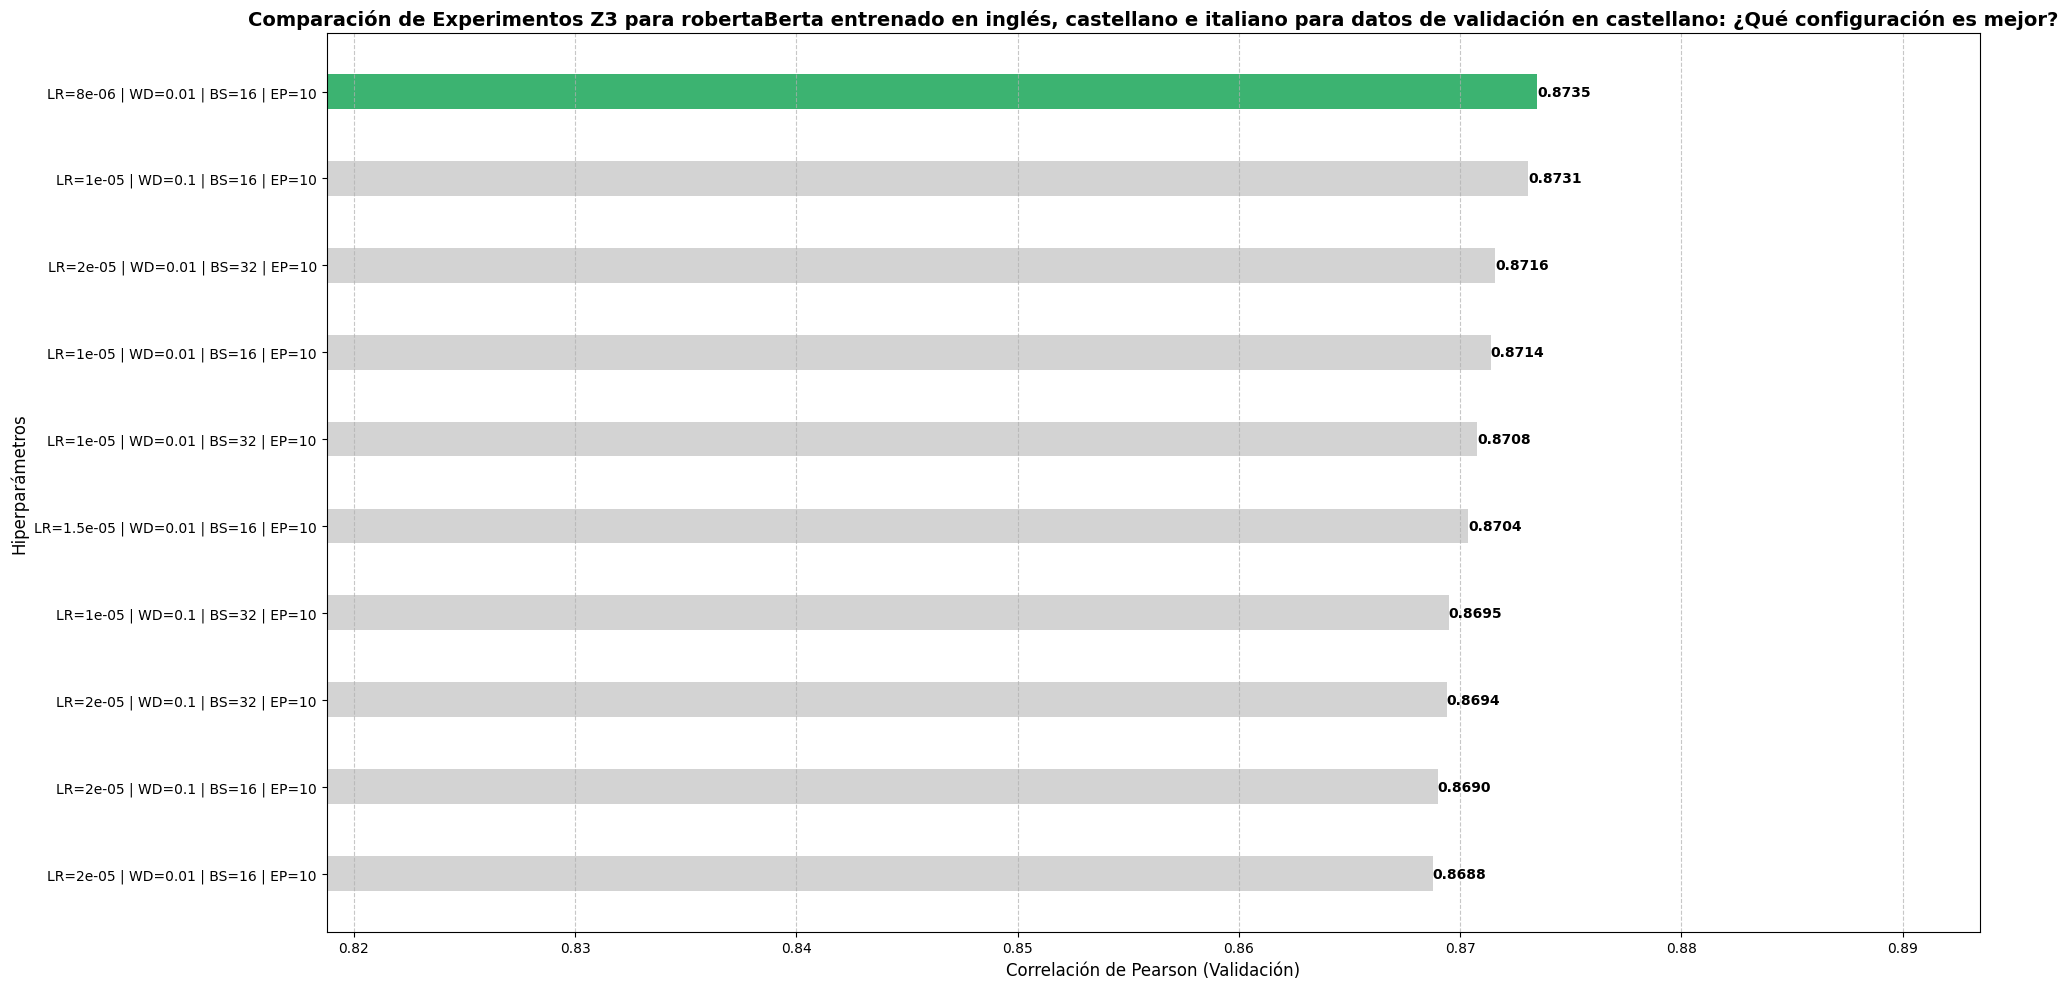

Gráfica guardada como 'grafica_grid_search_z3_roberta_ingcastit.png'


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Recuperamos los datos (si existen)
if 'resultados_globales_roberta_ingcastit' in globals() and resultados_globales_roberta_ingcastit:
    df_plot = pd.DataFrame(resultados_globales_roberta_ingcastit)

    # Creamos una etiqueta legible para cada barra
    df_plot['Config'] = df_plot.apply(lambda x: f"LR={x['LR']} | WD={x['Weight Decay']} | BS={x['Batch Size']} | EP={x['Epochs']}", axis=1)

    # Ordenamos de mejor a peor
    df_plot = df_plot.sort_values('Pearson (Val)', ascending=True)

    # 2. Configuración del Gráfico
    plt.figure(figsize=(20, 10))

    # Colores: Destacamos el mejor en verde, los demás en gris
    colores = ['lightgray'] * (len(df_plot) - 1) + ['mediumseagreen']

    barras = plt.barh(df_plot['Config'], df_plot['Pearson (Val)'], color=colores,height=0.4)

    # 3. Estética
    plt.xlabel('Correlación de Pearson (Validación)', fontsize=12)
    plt.ylabel('Hiperparámetros', fontsize=12)
    plt.title('Comparación de Experimentos Z3 para robertaBerta entrenado en inglés, castellano e italiano para datos de validación en castellano: ¿Qué configuración es mejor?', fontsize=14, fontweight='bold')

    # Ajustamos los límites del eje X para que se aprecien las diferencias
    # (Como todos estarán cerca de 0.8, empezamos en 0.7 para hacer "zoom")
    min_score = df_plot['Pearson (Val)'].min()
    plt.xlim(min_score - 0.05, df_plot['Pearson (Val)'].max() + 0.02)

    # 4. Añadir el valor exacto en cada barra
    for barra in barras:
        width = barra.get_width()
        plt.text(width, barra.get_y() + barra.get_height()/2,
                 f'{width:.4f}',
                 ha='left', va='center', fontweight='bold') # Removed padding=5

    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Mostrar y Guardar (para el informe)
    plt.savefig("grafica_grid_search_z3_roberta_ingcastit.png", dpi=300) # Se guarda en la carpeta de archivos
    plt.show()
    print("Gráfica guardada como 'grafica_grid_search_z3_roberta_ingcastit.png'")

else:
    print("No hay resultados en memoria. Ejecuta primero el entrenamiento (Grid Search).")

In [ ]:
resultados_val_cast.append({"Modelo": "RoBERTa (entrenado en inglés, italiano y castellano)", "Pearson (Val)": 0.8735})

#### Ajuste fino de un modelo multilingüe con un dataset en inglés y castellano

Ahora vamos a realizar el entrenamiento directamente con los datos en inglés y castellano, juntando los idiomas anteriormente, en lugar de realizar ajustes finos secuenciales, para ver como se comporta el modelo en este caso.

In [ ]:
print("--- Iniciando Experimento: Joint2 Training (Inglés y castellano) ---")

# Cargamos TODOS los datasets que nos interesan
langs_all = ['en', 'es']
datasets_all = []

for lang in langs_all:
    # Nota: Para inglés, el dataset multi_mt es traducción, pero sirve para este experimento.
    # Si quieres el original inglés de alta calidad, usa 'mteb/stsbenchmark-sts' y asegúrate
    # de que tenga las mismas columnas antes de concatenar.
    print(f"Cargando {lang}...")
    ds = load_dataset("mteb/stsb_multi_mt", name=lang, split="train")
    datasets_all.append(ds)

# Concatenamos todo
dataset_joint2_train = concatenate_datasets(datasets_all)
print(f"Dataset Joint2 creado (Massive). Total de ejemplos: {len(dataset_joint2_train)}")

--- Iniciando Experimento: Joint2 Training (Inglés y castellano) ---
Cargando en...


test/en.parquet:   0%|          | 0.00/71.8k [00:00<?, ?B/s]

train/en.parquet:   0%|          | 0.00/286k [00:00<?, ?B/s]

dev/en.parquet:   0%|          | 0.00/93.5k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/1379 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/5749 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/1500 [00:00<?, ? examples/s]

Cargando es...
Dataset Joint2 creado (Massive). Total de ejemplos: 11498


In [ ]:
model_checkpoint = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

# Función de preprocesamiento: Tokeniza las dos oraciones JUNTAS
def preprocess_function(examples):
    # El tokenizador de BERT añade automáticamente los tokens especiales:
    # [CLS] sentence1 [SEP] sentence2 [SEP]
    return tokenizer(examples['sentence1'], examples['sentence2'], truncation=True)

# Aplicamos la tokenización a todo el dataset
encoded_dataset_joint2_train = dataset_joint2_train.map(preprocess_function, batched=True)

# ¡IMPORTANTE! El 'Trainer' de Hugging Face espera que la etiqueta objetivo se llame 'labels'
# Renombramos la columna 'score' a 'labels'
encoded_dataset_joint2_train = encoded_dataset_joint2_train.rename_column("similarity_score", "labels")

# Eliminamos las columnas de texto originales para que no molesten al modelo
encoded_dataset_joint2_train = encoded_dataset_joint2_train.remove_columns(["sentence1", "sentence2", "lang"])
encoded_dataset_joint2_train.set_format("torch")

print("Datos procesados. Ejemplo de entrada:", encoded_dataset_joint2_train[0])

pearson = evaluate.load("pearsonr")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    # El modelo devuelve una tupla, nos quedamos con el primer elemento (las predicciones)
    predictions = predictions[:, 0]
    return pearson.compute(predictions=predictions, references=labels)

# Lista para guardar resultados en memoria
resultados_globales_roberta_joint2 = []

# --- Configuración de rutas ---
# Carpeta en Drive donde SIEMPRE estará el mejor modelo encontrado hasta el momento
ruta_mejor_modelo_drive = f"{base_path}/z3_finetunning_roberta_joint2"

def ejecutar_experimento_roberta_joint2(lr, bs, wd, ep):
    torch.cuda.empty_cache()
    print(f"\n Iniciando Experimento: LR={lr} | BS={bs} | WD={wd} | EP={ep}")

    # 1. Configuración de Rutas
    run_name = f"z3robertajoint2_lr{lr}_bs{bs}_wd{wd}_ep{ep}"

    # GUARDA AQUÍ TEMPORALMENTE (Disco local de Colab, muy rápido, se borra al reiniciar)
    output_dir_temp = f"/content/temp_experiments/experiments/{run_name}"

    # 2. Reiniciar modelo
    model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=1).to(device)

    args = TrainingArguments(
        output_dir=output_dir_temp,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        learning_rate=lr,
        per_device_train_batch_size=bs,
        per_device_eval_batch_size=bs,
        num_train_epochs=ep,
        weight_decay=wd,
        load_best_model_at_end=True,
        metric_for_best_model="pearsonr",
        save_total_limit=1,
        report_to="none",
        fp16=True if device == "cuda" else False,
        overwrite_output_dir=True,
        dataloader_num_workers=0,
        dataloader_pin_memory=False
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=encoded_dataset_joint2_train,
        eval_dataset=encoded_dataset_cast["dev"],
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    # 3. Entrenar
    trainer.train()

    # Guardamos explícitamente el modelo final en la carpeta temporal
    trainer.save_model(output_dir_temp)

    # 4. Evaluar
    eval_metrics = trainer.evaluate()
    nota = eval_metrics["eval_pearsonr"]
    print(f">>> Resultado Experimento: {nota:.4f}")

    # --- 5. LÓGICA DE "REY DE LA COLINA" ---
    # Buscamos cuál es la mejor nota que hemos conseguido hasta ahora en experimentos anteriores
    mejor_nota_historica = -1.0
    if resultados_globales_roberta_joint2:
        mejor_nota_historica = max(r["Pearson (Val)"] for r in resultados_globales_roberta_joint2)

    estado = ""
    if nota > mejor_nota_historica:
        print(f" ¡NUEVO RÉCORD! ({nota:.4f} supera a {mejor_nota_historica:.4f})")
        print(f" Guardando copia de seguridad en Drive: {ruta_mejor_modelo_drive}...")

        # Borramos el anterior campeón del Drive si existe para no ocupar espacio
        if os.path.exists(ruta_mejor_modelo_drive):
            shutil.rmtree(ruta_mejor_modelo_drive)

        # Copiamos el nuevo campeón de Temp -> Drive
        shutil.copytree(output_dir_temp, ruta_mejor_modelo_drive)
        estado = " Récord (Guardado en Drive)"
    else:
        print(f" No supera el récord ({nota:.4f} vs {mejor_nota_historica:.4f}).")
        print(" Descartando archivos de este modelo...")
        estado = "Descartado"

    # 6. Limpieza: Borramos SIEMPRE la carpeta temporal local para no llenar Colab
    if os.path.exists(output_dir_temp):
        shutil.rmtree(output_dir_temp)

    # 7. Guardar resultados en la tabla (Esto sí lo guardamos siempre)
    resultados_globales_roberta_joint2.append({
        "LR": lr, "Batch Size": bs, "Weight Decay": wd, "Epochs": ep,
        "Pearson (Val)": nota, "Estado": estado
    })

    return nota


Map:   0%|          | 0/11498 [00:00<?, ? examples/s]

Datos procesados. Ejemplo de entrada: {'labels': tensor(5.), 'input_ids': tensor([    0,    62, 47880,    83, 35971,  5773,     5,     2,     2,   893,
         1831, 47880,    83, 35971,  5773,     5,     2]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])}


##### Experimentos

In [ ]:
#Experimento 1 (LR=1e-5, BS=32, WD=0.01, EP=10)
nota = ejecutar_experimento_roberta_joint2(lr=1e-5, bs=32, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=1e-05 | BS=32 | WD=0.01 | EP=10


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2700236032.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.881400,0.758094,0.834022
2,0.625300,0.666145,0.847189
3,0.471200,0.639537,0.861844
4,0.390400,0.647264,0.863994
5,0.329600,0.628329,0.864955
6,0.285800,0.593001,0.866893
7,0.249400,0.593408,0.864233
8,0.216700,0.595038,0.863134


>>> Resultado Experimento: 0.8669
 ¡NUEVO RÉCORD! (0.8669 supera a -1.0000)
 Guardando copia de seguridad en Drive: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z3_finetunning_roberta_joint2...
Nota obtenida: 0.8668934264818481


In [ ]:
#Experimento 2 (LR=1e-5, BS=16, WD=0.01, EP=10)
nota = ejecutar_experimento_roberta_joint2(lr=1e-5, bs=16, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=1e-05 | BS=16 | WD=0.01 | EP=10


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2700236032.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.383700,0.823264,0.851675
2,0.563700,0.648512,0.860244
3,0.423900,0.702945,0.863790
4,0.326100,0.599447,0.867067
5,0.268600,0.642209,0.871462
6,0.220400,0.577489,0.872096
7,0.188700,0.576088,0.869132
8,0.167400,0.587208,0.871796


>>> Resultado Experimento: 0.8721
 ¡NUEVO RÉCORD! (0.8721 supera a 0.8669)
 Guardando copia de seguridad en Drive: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z3_finetunning_roberta_joint2...
Nota obtenida: 0.8720958345982704


In [ ]:
#Experimento 3 (LR=1e-5, BS=16, WD=0.1, EP=10)
nota = ejecutar_experimento_roberta_joint2(lr=1e-5, bs=16, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=1e-05 | BS=16 | WD=0.1 | EP=10


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2700236032.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.364500,0.879046,0.848679
2,0.567500,0.685634,0.860058
3,0.431200,0.652604,0.865293
4,0.331400,0.607301,0.865025
5,0.269600,0.610884,0.872578
6,0.223400,0.579028,0.872093
7,0.187500,0.556419,0.871908


>>> Resultado Experimento: 0.8726
 ¡NUEVO RÉCORD! (0.8726 supera a 0.8721)
 Guardando copia de seguridad en Drive: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z3_finetunning_roberta_joint2...
Nota obtenida: 0.8725783076754686


In [ ]:
#Experimento 4 (LR=1e-5, BS=32, WD=0.1, EP=10)
nota = ejecutar_experimento_roberta_joint2(lr=1e-5, bs=32, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=1e-05 | BS=32 | WD=0.1 | EP=10


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2700236032.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.704500,0.765751,0.818661
2,0.676500,0.654088,0.850725
3,0.503400,0.684712,0.861274
4,0.414500,0.667783,0.858198
5,0.348300,0.639988,0.862449
6,0.299400,0.620464,0.862964
7,0.261400,0.606932,0.860686
8,0.228700,0.614684,0.860986


>>> Resultado Experimento: 0.8630
 No supera el récord (0.8630 vs 0.8726).
 Descartando archivos de este modelo...
Nota obtenida: 0.8629640020763366


In [ ]:
#Experimento 5 (LR=2e-5, BS=16, WD=0.01, EP=10)
nota = ejecutar_experimento_roberta_joint2(lr=2e-5, bs=16, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=2e-05 | BS=16 | WD=0.01 | EP=10


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2700236032.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.211100,0.717482,0.839056
2,0.542700,0.696671,0.857340
3,0.396900,0.671062,0.861332
4,0.279100,0.643843,0.860704
5,0.208100,0.638720,0.863817
6,0.165000,0.602261,0.866783
7,0.130600,0.586315,0.864170
8,0.109000,0.616707,0.863916


>>> Resultado Experimento: 0.8668
 No supera el récord (0.8668 vs 0.8726).
 Descartando archivos de este modelo...
Nota obtenida: 0.8667828626355177


In [ ]:
#Experimento 6 (LR=2e-5, BS=32, WD=0.01, EP=10)
nota = ejecutar_experimento_roberta_joint2(lr=2e-5, bs=32, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=2e-05 | BS=32 | WD=0.01 | EP=10


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2700236032.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.337900,0.722860,0.846349
2,0.553500,0.632697,0.854137
3,0.390200,0.658341,0.857521
4,0.298900,0.603894,0.862534
5,0.226500,0.626668,0.863991
6,0.184800,0.604104,0.869431
7,0.149600,0.619136,0.865363
8,0.127700,0.588911,0.866982


>>> Resultado Experimento: 0.8694
 No supera el récord (0.8694 vs 0.8726).
 Descartando archivos de este modelo...
Nota obtenida: 0.869431338232303


In [ ]:
#Experimento 7 (LR=2e-5, BS=16, WD=0.1, EP=10)
nota = ejecutar_experimento_roberta_joint2(lr=2e-5, bs=16, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=2e-05 | BS=16 | WD=0.1 | EP=10


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2700236032.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.172600,0.821853,0.841028
2,0.528200,0.825554,0.844939
3,0.379900,0.691624,0.860702
4,0.267100,0.574326,0.867239
5,0.203400,0.685815,0.855905
6,0.159500,0.593426,0.864219


>>> Resultado Experimento: 0.8672
 No supera el récord (0.8672 vs 0.8726).
 Descartando archivos de este modelo...
Nota obtenida: 0.8672391398523503


In [ ]:
#Experimento 8 (LR=2e-5, BS=32, WD=0.1, EP=10)
nota = ejecutar_experimento_roberta_joint2(lr=2e-5, bs=32, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



 Iniciando Experimento: LR=2e-05 | BS=32 | WD=0.1 | EP=10


/tmp/ipython-input-2700236032.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.488100,0.795466,0.846780
2,0.565600,0.593745,0.860663
3,0.401600,0.608662,0.861156
4,0.301300,0.579404,0.865861
5,0.230100,0.581552,0.869135
6,0.182600,0.579929,0.867572
7,0.155100,0.570782,0.869717
8,0.128300,0.583671,0.869272
9,0.112100,0.558788,0.874684
10,0.104300,0.558484,0.874499


>>> Resultado Experimento: 0.8747
 ¡NUEVO RÉCORD! (0.8747 supera a 0.8726)
 Guardando copia de seguridad en Drive: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z3_finetunning_roberta_joint2...
Nota obtenida: 0.8746836741584063


In [ ]:
#Experimento 9 (LR=1.5e-5, BS=16, WD=0.01, EP=10)
nota = ejecutar_experimento_roberta_joint2(lr=1.5e-5, bs=16, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=1.5e-05 | BS=16 | WD=0.01 | EP=10


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2700236032.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.294000,0.830608,0.838281
2,0.541100,0.652071,0.861549
3,0.401800,0.669619,0.855764
4,0.285500,0.625205,0.860321


>>> Resultado Experimento: 0.8615
 No supera el récord (0.8615 vs 0.8747).
 Descartando archivos de este modelo...
Nota obtenida: 0.8615489297014295


In [ ]:
#Experimento 10 (LR=8e-6, BS=16, WD=0.01, EP=10)
nota = ejecutar_experimento_roberta_joint2(lr=8e-6, bs=16, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=8e-06 | BS=16 | WD=0.01 | EP=10


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2700236032.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.485600,0.727791,0.844260
2,0.612000,0.636907,0.852230
3,0.477400,0.672371,0.858266
4,0.380500,0.594803,0.862830
5,0.317500,0.614442,0.863732
6,0.271700,0.608947,0.866510
7,0.236500,0.598835,0.862141
8,0.212300,0.584769,0.866868
9,0.197300,0.593040,0.865729
10,0.183500,0.597560,0.865907


>>> Resultado Experimento: 0.8669
 No supera el récord (0.8669 vs 0.8747).
 Descartando archivos de este modelo...
Nota obtenida: 0.8668683407427346


##### Resultados

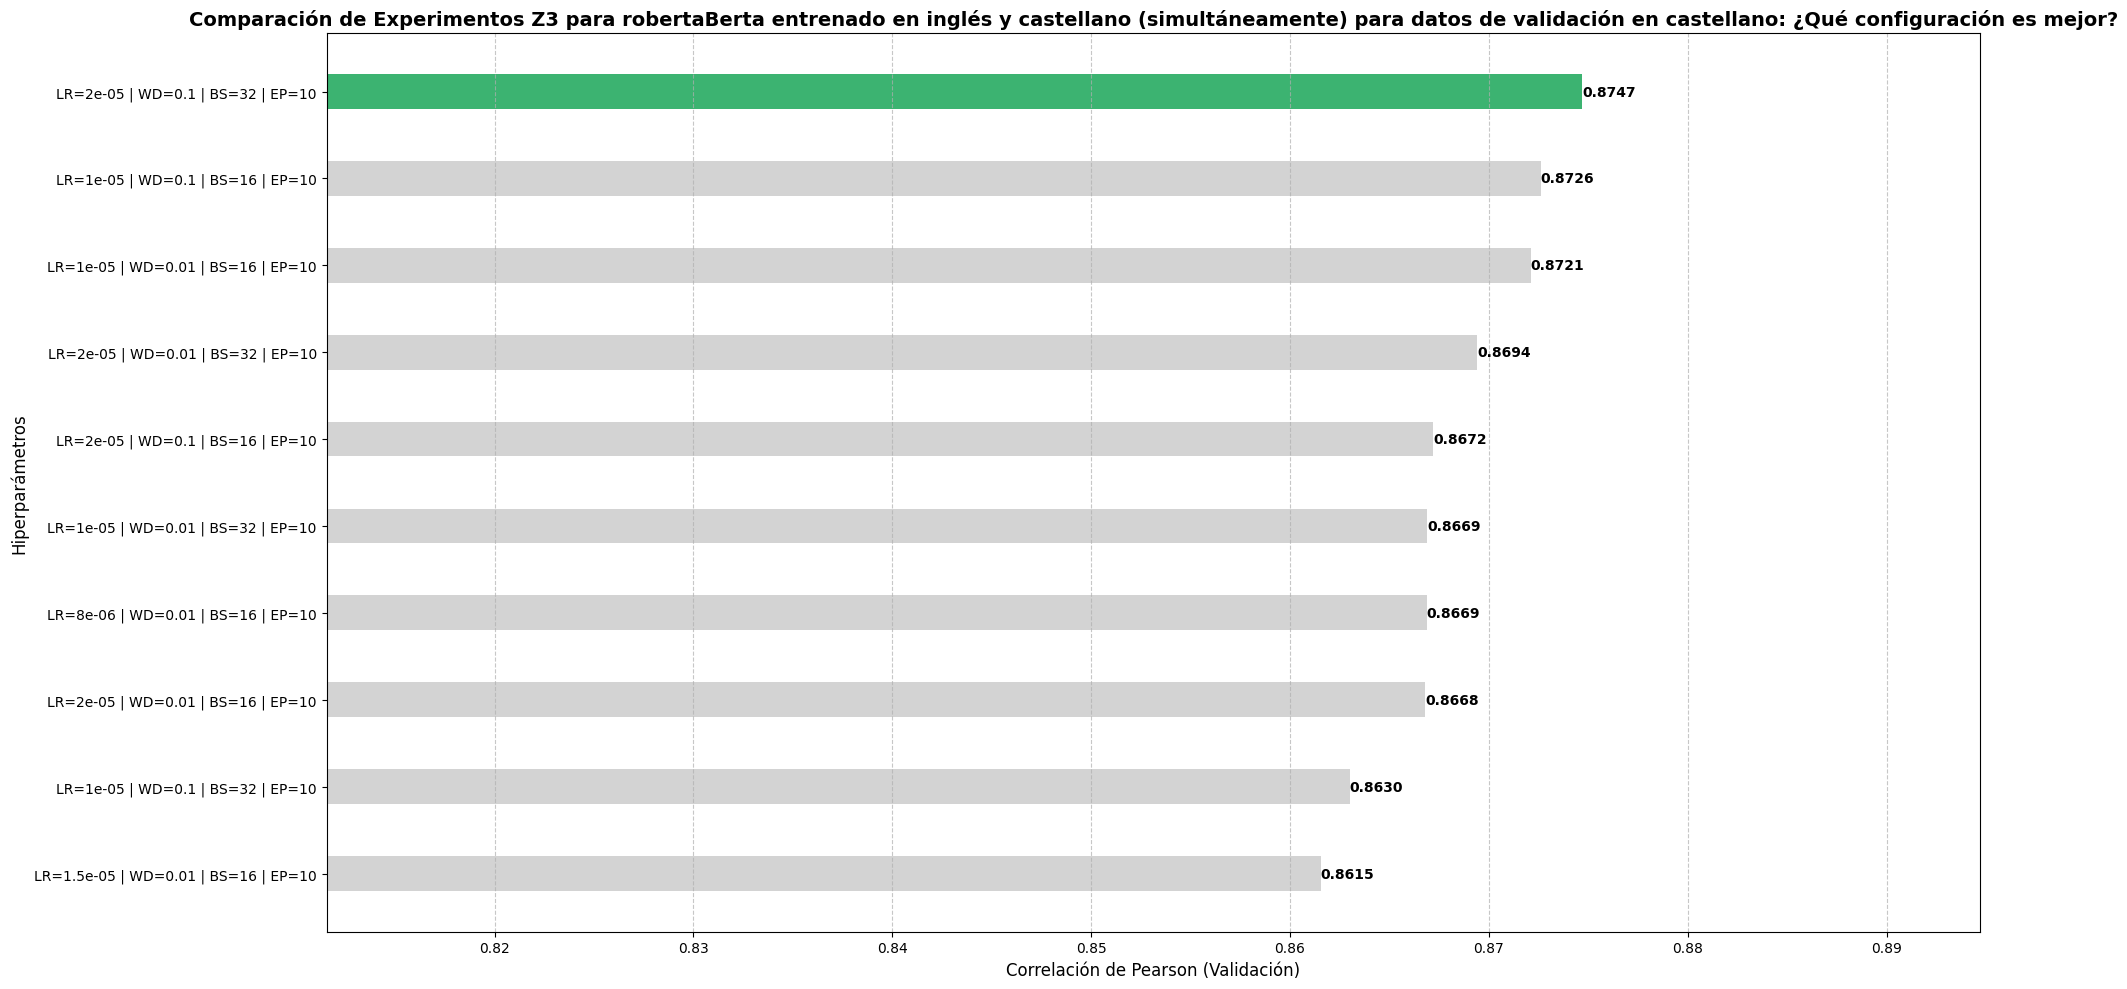

Gráfica guardada como 'grafica_grid_search_z3_roberta_joint2.png'


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Recuperamos los datos (si existen)
if 'resultados_globales_roberta_joint2' in globals() and resultados_globales_roberta_joint2:
    df_plot = pd.DataFrame(resultados_globales_roberta_joint2)

    # Creamos una etiqueta legible para cada barra
    df_plot['Config'] = df_plot.apply(lambda x: f"LR={x['LR']} | WD={x['Weight Decay']} | BS={x['Batch Size']} | EP={x['Epochs']}", axis=1)

    # Ordenamos de mejor a peor
    df_plot = df_plot.sort_values('Pearson (Val)', ascending=True)

    # 2. Configuración del Gráfico
    plt.figure(figsize=(20, 10))

    # Colores: Destacamos el mejor en verde, los demás en gris
    colores = ['lightgray'] * (len(df_plot) - 1) + ['mediumseagreen']

    barras = plt.barh(df_plot['Config'], df_plot['Pearson (Val)'], color=colores,height=0.4)

    # 3. Estética
    plt.xlabel('Correlación de Pearson (Validación)', fontsize=12)
    plt.ylabel('Hiperparámetros', fontsize=12)
    plt.title('Comparación de Experimentos Z3 para robertaBerta entrenado en inglés y castellano (simultáneamente) para datos de validación en castellano: ¿Qué configuración es mejor?', fontsize=14, fontweight='bold')

    # Ajustamos los límites del eje X para que se aprecien las diferencias
    # (Como todos estarán cerca de 0.8, empezamos en 0.7 para hacer "zoom")
    min_score = df_plot['Pearson (Val)'].min()
    plt.xlim(min_score - 0.05, df_plot['Pearson (Val)'].max() + 0.02)

    # 4. Añadir el valor exacto en cada barra
    for barra in barras:
        width = barra.get_width()
        plt.text(width, barra.get_y() + barra.get_height()/2,
                 f'{width:.4f}',
                 ha='left', va='center', fontweight='bold') # Removed padding=5

    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Mostrar y Guardar (para el informe)
    plt.savefig("grafica_grid_search_z3_roberta_joint2.png", dpi=300) # Se guarda en la carpeta de archivos
    plt.show()
    print("Gráfica guardada como 'grafica_grid_search_z3_roberta_joint2.png'")

else:
    print("No hay resultados en memoria. Ejecuta primero el entrenamiento (Grid Search).")

In [ ]:
resultados_val_cast.append({"Modelo": "RoBERTa (entrenado en inglés y castellano (simultáneamente))", "Pearson (Val)": 0.8747})

#### Ajuste fino de un modelo multilingüe con un dataset en varios idiomas

Ahora vamos a realizar el entrenamiento directamente con todos los datos, juntando los idiomas anteriormente, en lugar de realizar ajustes finos secuenciales, para ver como se comporta el modelo en este caso.

In [ ]:
print("--- Iniciando Experimento: Joint Training (Todos los idiomas) ---")

# Cargamos TODOS los datasets que nos interesan
langs_all = ['en', 'es', 'it']
datasets_all = []

for lang in langs_all:
    # Nota: Para inglés, el dataset multi_mt es traducción, pero sirve para este experimento.
    # Si quieres el original inglés de alta calidad, usa 'mteb/stsbenchmark-sts' y asegúrate
    # de que tenga las mismas columnas antes de concatenar.
    print(f"Cargando {lang}...")
    ds = load_dataset("mteb/stsb_multi_mt", name=lang, split="train")
    datasets_all.append(ds)

# Concatenamos todo
dataset_joint_train = concatenate_datasets(datasets_all)
print(f"Dataset Joint creado (Massive). Total de ejemplos: {len(dataset_joint_train)}")

--- Iniciando Experimento: Joint Training (Todos los idiomas) ---
Cargando en...


test/en.parquet:   0%|          | 0.00/71.8k [00:00<?, ?B/s]

train/en.parquet:   0%|          | 0.00/286k [00:00<?, ?B/s]

dev/en.parquet:   0%|          | 0.00/93.5k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/1379 [00:00<?, ? examples/s]

...

dev/it.parquet:   0%|          | 0.00/102k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/1379 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/5749 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/1500 [00:00<?, ? examples/s]

Dataset Joint creado (Massive). Total de ejemplos: 17247


In [ ]:
model_checkpoint = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

# Función de preprocesamiento: Tokeniza las dos oraciones JUNTAS
def preprocess_function(examples):
    # El tokenizador de BERT añade automáticamente los tokens especiales:
    # [CLS] sentence1 [SEP] sentence2 [SEP]
    return tokenizer(examples['sentence1'], examples['sentence2'], truncation=True)

# Aplicamos la tokenización a todo el dataset
encoded_dataset_joint_train = dataset_joint_train.map(preprocess_function, batched=True)

# ¡IMPORTANTE! El 'Trainer' de Hugging Face espera que la etiqueta objetivo se llame 'labels'
# Renombramos la columna 'score' a 'labels'
encoded_dataset_joint_train = encoded_dataset_joint_train.rename_column("similarity_score", "labels")

# Eliminamos las columnas de texto originales para que no molesten al modelo
encoded_dataset_joint_train = encoded_dataset_joint_train.remove_columns(["sentence1", "sentence2", "lang"])
encoded_dataset_joint_train.set_format("torch")

print("Datos procesados. Ejemplo de entrada:", encoded_dataset_joint_train[0])

pearson = evaluate.load("pearsonr")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    # El modelo devuelve una tupla, nos quedamos con el primer elemento (las predicciones)
    predictions = predictions[:, 0]
    return pearson.compute(predictions=predictions, references=labels)

# Lista para guardar resultados en memoria
resultados_globales_roberta_joint = []

# --- Configuración de rutas ---
# Carpeta en Drive donde SIEMPRE estará el mejor modelo encontrado hasta el momento
ruta_mejor_modelo_drive = f"{base_path}/z3_finetunning_roberta_joint"

def ejecutar_experimento_roberta_joint(lr, bs, wd, ep):
    torch.cuda.empty_cache()
    print(f"\n Iniciando Experimento: LR={lr} | BS={bs} | WD={wd} | EP={ep}")

    # 1. Configuración de Rutas
    run_name = f"z3robertajoint_lr{lr}_bs{bs}_wd{wd}_ep{ep}"

    # GUARDA AQUÍ TEMPORALMENTE (Disco local de Colab, muy rápido, se borra al reiniciar)
    output_dir_temp = f"/content/temp_experiments/experiments/{run_name}"

    # 2. Reiniciar modelo
    model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=1).to(device)

    args = TrainingArguments(
        output_dir=output_dir_temp,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        learning_rate=lr,
        per_device_train_batch_size=bs,
        per_device_eval_batch_size=bs,
        num_train_epochs=ep,
        weight_decay=wd,
        load_best_model_at_end=True,
        metric_for_best_model="pearsonr",
        save_total_limit=1,
        report_to="none",
        fp16=True if device == "cuda" else False,
        overwrite_output_dir=True,
        dataloader_num_workers=0,
        dataloader_pin_memory=False
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=encoded_dataset_joint_train,
        eval_dataset=encoded_dataset_cast["dev"],
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    # 3. Entrenar
    trainer.train()

    # Guardamos explícitamente el modelo final en la carpeta temporal
    trainer.save_model(output_dir_temp)

    # 4. Evaluar
    eval_metrics = trainer.evaluate()
    nota = eval_metrics["eval_pearsonr"]
    print(f">>> Resultado Experimento: {nota:.4f}")

    # --- 5. LÓGICA DE "REY DE LA COLINA" ---
    # Buscamos cuál es la mejor nota que hemos conseguido hasta ahora en experimentos anteriores
    mejor_nota_historica = -1.0
    if resultados_globales_roberta_joint:
        mejor_nota_historica = max(r["Pearson (Val)"] for r in resultados_globales_roberta_joint)

    estado = ""
    if nota > mejor_nota_historica:
        print(f" ¡NUEVO RÉCORD! ({nota:.4f} supera a {mejor_nota_historica:.4f})")
        print(f" Guardando copia de seguridad en Drive: {ruta_mejor_modelo_drive}...")

        # Borramos el anterior campeón del Drive si existe para no ocupar espacio
        if os.path.exists(ruta_mejor_modelo_drive):
            shutil.rmtree(ruta_mejor_modelo_drive)

        # Copiamos el nuevo campeón de Temp -> Drive
        shutil.copytree(output_dir_temp, ruta_mejor_modelo_drive)
        estado = " Récord (Guardado en Drive)"
    else:
        print(f" No supera el récord ({nota:.4f} vs {mejor_nota_historica:.4f}).")
        print(" Descartando archivos de este modelo...")
        estado = "Descartado"

    # 6. Limpieza: Borramos SIEMPRE la carpeta temporal local para no llenar Colab
    if os.path.exists(output_dir_temp):
        shutil.rmtree(output_dir_temp)

    # 7. Guardar resultados en la tabla (Esto sí lo guardamos siempre)
    resultados_globales_roberta_joint.append({
        "LR": lr, "Batch Size": bs, "Weight Decay": wd, "Epochs": ep,
        "Pearson (Val)": nota, "Estado": estado
    })

    return nota


Map:   0%|          | 0/17247 [00:00<?, ? examples/s]

Datos procesados. Ejemplo de entrada: {'labels': tensor(5.), 'input_ids': tensor([    0,    62, 47880,    83, 35971,  5773,     5,     2,     2,   893,
         1831, 47880,    83, 35971,  5773,     5,     2]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])}


##### Experimentos

In [ ]:
#Experimento 1 (LR=1e-5, BS=32, WD=0.01, EP=10)
nota = ejecutar_experimento_roberta_joint(lr=1e-5, bs=32, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=1e-05 | BS=32 | WD=0.01 | EP=10


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2491506039.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.435200,0.695064,0.852020
2,0.572600,0.659317,0.853968
3,0.442900,0.599058,0.866873
4,0.358600,0.645632,0.871754
5,0.289500,0.585175,0.872139
6,0.248100,0.558501,0.873108
7,0.213800,0.583119,0.873703
8,0.193300,0.562607,0.874345
9,0.174100,0.567448,0.874020
10,0.162900,0.580481,0.874012


>>> Resultado Experimento: 0.8743
 ¡NUEVO RÉCORD! (0.8743 supera a -1.0000)
 Guardando copia de seguridad en Drive: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z3_finetunning_roberta_joint...
Nota obtenida: 0.8743454619468941


In [ ]:
#Experimento 2 (LR=1e-5, BS=16, WD=0.01, EP=10)
nota = ejecutar_experimento_roberta_joint(lr=1e-5, bs=16, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=1e-05 | BS=16 | WD=0.01 | EP=10


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2491506039.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.132400,0.692254,0.852314
2,0.503400,0.642466,0.849176
3,0.360500,0.617185,0.868784
4,0.281000,0.559223,0.868887
5,0.218800,0.589523,0.870367
6,0.178500,0.584955,0.869762
7,0.152800,0.579293,0.866172


>>> Resultado Experimento: 0.8704
 No supera el récord (0.8704 vs 0.8743).
 Descartando archivos de este modelo...
Nota obtenida: 0.8703669450549217


In [ ]:
#Experimento 3 (LR=1e-5, BS=16, WD=0.1, EP=10)
nota = ejecutar_experimento_roberta_joint(lr=1e-5, bs=16, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=1e-05 | BS=16 | WD=0.1 | EP=10


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2491506039.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.283400,0.744429,0.836892
2,0.573100,0.700312,0.833834
3,0.421200,0.666444,0.862316
4,0.323800,0.635877,0.858497
5,0.259300,0.614793,0.862920
6,0.209500,0.620627,0.862023
7,0.182800,0.614218,0.858360


>>> Resultado Experimento: 0.8629
 No supera el récord (0.8629 vs 0.8743).
 Descartando archivos de este modelo...
Nota obtenida: 0.8629203155074594


In [ ]:
#Experimento 4 (LR=1e-5, BS=32, WD=0.1, EP=10)
nota = ejecutar_experimento_roberta_joint(lr=1e-5, bs=32, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=1e-05 | BS=32 | WD=0.1 | EP=10


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2491506039.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.396400,0.665220,0.843536
2,0.575100,0.668475,0.848382
3,0.444100,0.601858,0.859612
4,0.354000,0.633176,0.868215
5,0.290900,0.583448,0.867528
6,0.244700,0.584486,0.867657


>>> Resultado Experimento: 0.8682
 No supera el récord (0.8682 vs 0.8743).
 Descartando archivos de este modelo...
Nota obtenida: 0.8682145453271038


In [ ]:
#Experimento 5 (LR=2e-5, BS=16, WD=0.01, EP=10)
nota = ejecutar_experimento_roberta_joint(lr=2e-5, bs=16, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=2e-05 | BS=16 | WD=0.01 | EP=10


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2491506039.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.095500,0.628553,0.850056
2,0.518600,0.615456,0.858492
3,0.348300,0.612728,0.870684
4,0.242800,0.546817,0.875483
5,0.184200,0.569720,0.872003
6,0.137500,0.564681,0.870403


>>> Resultado Experimento: 0.8755
 ¡NUEVO RÉCORD! (0.8755 supera a 0.8743)
 Guardando copia de seguridad en Drive: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z3_finetunning_roberta_joint...
Nota obtenida: 0.8754829933310371


In [ ]:
#Experimento 6 (LR=2e-5, BS=32, WD=0.01, EP=10)
nota = ejecutar_experimento_roberta_joint(lr=2e-5, bs=32, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=2e-05 | BS=32 | WD=0.01 | EP=10


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2491506039.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.202900,0.814670,0.835538
2,0.517200,0.657733,0.863154
3,0.362600,0.602252,0.866239
4,0.267700,0.570210,0.867868
5,0.201300,0.605864,0.865738
6,0.162500,0.592336,0.865634


>>> Resultado Experimento: 0.8679
 No supera el récord (0.8679 vs 0.8755).
 Descartando archivos de este modelo...
Nota obtenida: 0.8678678358065464


In [ ]:
#Experimento 7 (LR=2e-5, BS=16, WD=0.1, EP=10)
nota = ejecutar_experimento_roberta_joint(lr=2e-5, bs=16, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=2e-05 | BS=16 | WD=0.1 | EP=10


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2491506039.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.087900,0.623260,0.852452
2,0.502300,0.652927,0.849647
3,0.335100,0.636960,0.863877
4,0.236300,0.603901,0.858715
5,0.175000,0.599966,0.861072


>>> Resultado Experimento: 0.8639
 No supera el récord (0.8639 vs 0.8755).
 Descartando archivos de este modelo...
Nota obtenida: 0.8638774423712102


In [ ]:
#Experimento 8 (LR=2e-5, BS=32, WD=0.1, EP=10)
nota = ejecutar_experimento_roberta_joint(lr=2e-5, bs=32, wd=0.1, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=2e-05 | BS=32 | WD=0.1 | EP=10


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2491506039.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.258900,0.713298,0.842853
2,0.537100,0.708563,0.846513
3,0.381400,0.619362,0.860710
4,0.274200,0.597756,0.865497
5,0.206400,0.589320,0.868859
6,0.165700,0.590839,0.867229
7,0.134300,0.582978,0.868415


>>> Resultado Experimento: 0.8689
 No supera el récord (0.8689 vs 0.8755).
 Descartando archivos de este modelo...
Nota obtenida: 0.8688594239792423


In [ ]:
#Experimento 9 (LR=1.5e-5, BS=16, WD=0.01, EP=10)
nota = ejecutar_experimento_roberta_joint(lr=1.5e-5, bs=16, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=1.5e-05 | BS=16 | WD=0.01 | EP=10


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2491506039.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.063100,0.619416,0.851999
2,0.507900,0.652419,0.845959
3,0.349800,0.652683,0.865350
4,0.252500,0.590608,0.861195
5,0.188800,0.620301,0.859473


>>> Resultado Experimento: 0.8654
 No supera el récord (0.8654 vs 0.8755).
 Descartando archivos de este modelo...
Nota obtenida: 0.865350290292983


In [ ]:
#Experimento 10 (LR=8e-6, BS=16, WD=0.01, EP=10)
nota = ejecutar_experimento_roberta_joint(lr=8e-6, bs=16, wd=0.01, ep=10)
print(f"Nota obtenida: {nota}")


 Iniciando Experimento: LR=8e-06 | BS=16 | WD=0.01 | EP=10


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2491506039.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Pearsonr
1,1.312700,0.727839,0.854339
2,0.546700,0.627193,0.854217
3,0.409000,0.599037,0.872235
4,0.324900,0.541601,0.873602
5,0.262400,0.542356,0.874499
6,0.214800,0.582979,0.877015
7,0.191000,0.561715,0.871643
8,0.168000,0.569699,0.872496


>>> Resultado Experimento: 0.8770
 ¡NUEVO RÉCORD! (0.8770 supera a 0.8755)
 Guardando copia de seguridad en Drive: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z3_finetunning_roberta_joint...
Nota obtenida: 0.8770149618245139


##### Resultados

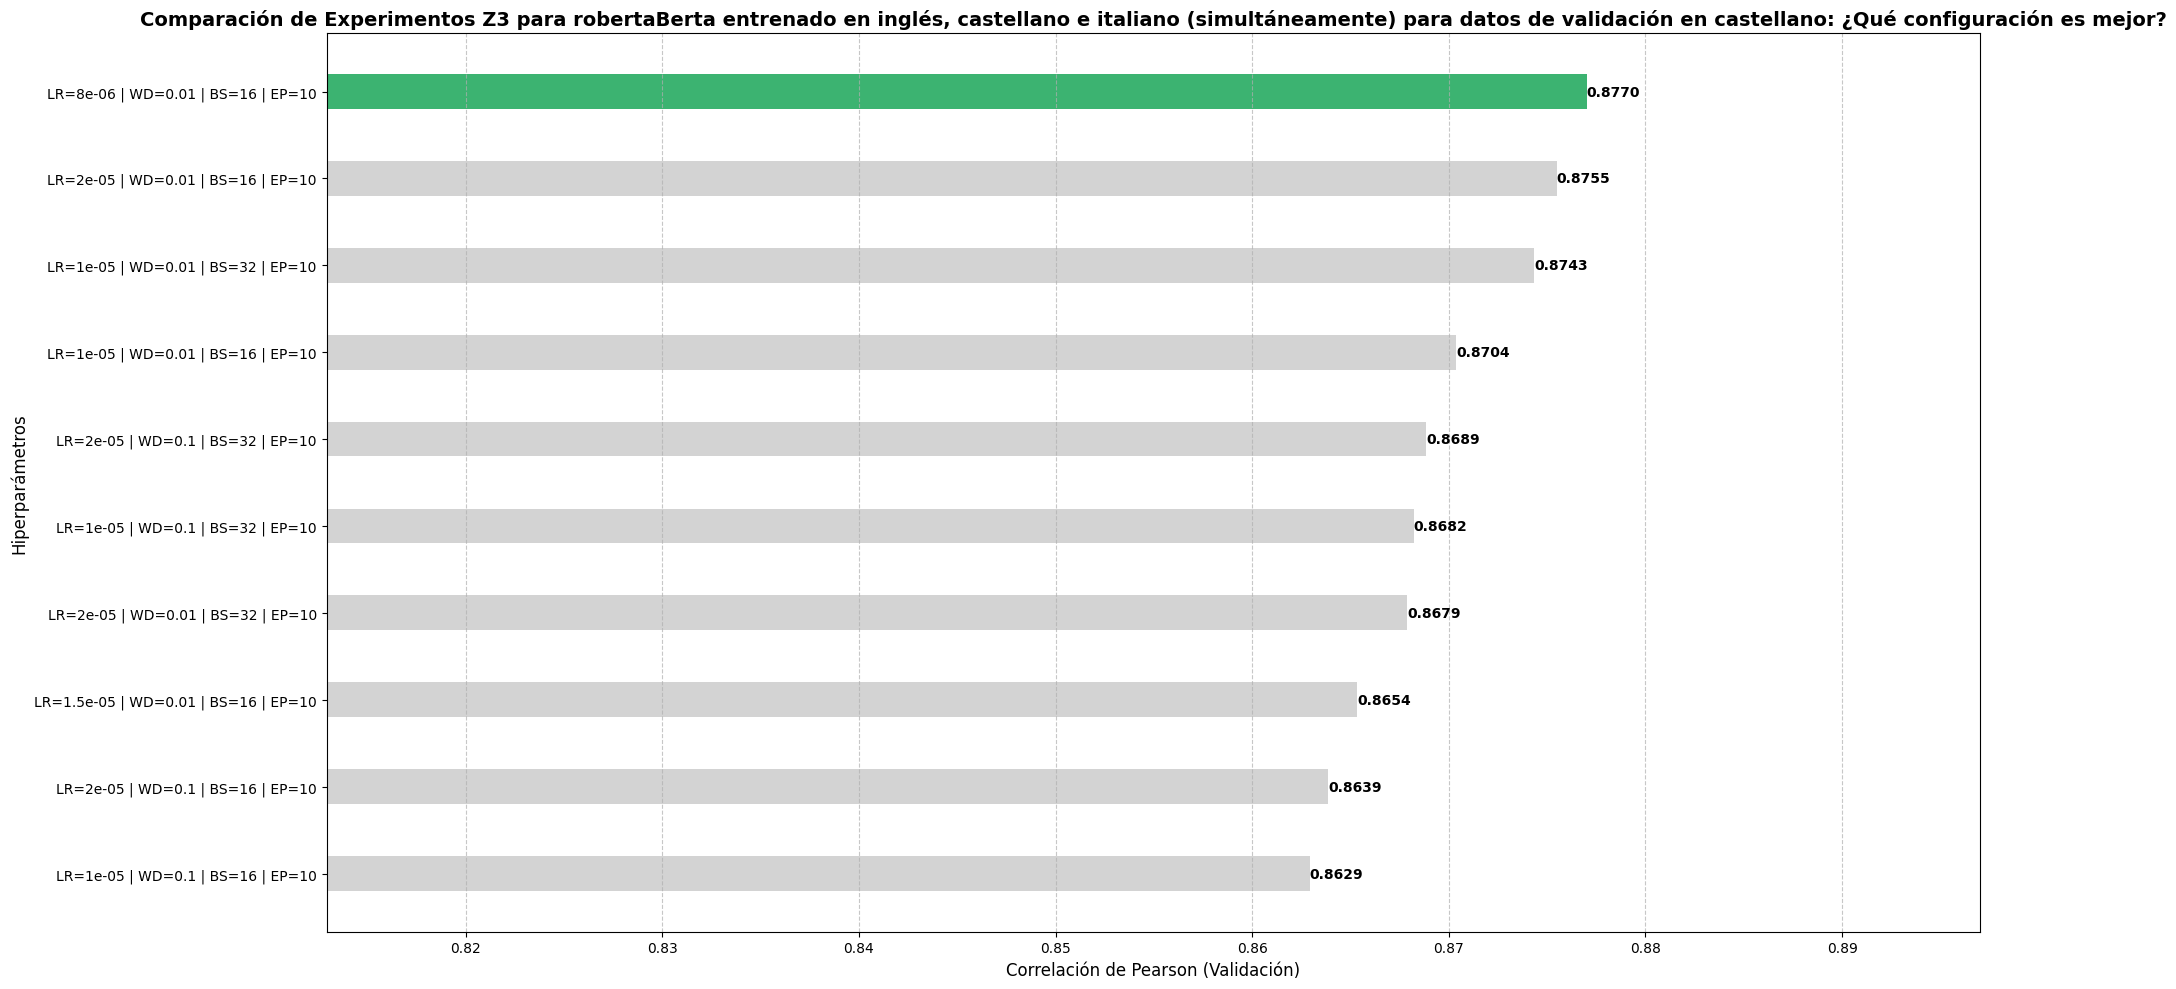

Gráfica guardada como 'grafica_grid_search_z3_roberta_joint.png'


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Recuperamos los datos (si existen)
if 'resultados_globales_roberta_joint' in globals() and resultados_globales_roberta_joint:
    df_plot = pd.DataFrame(resultados_globales_roberta_joint)

    # Creamos una etiqueta legible para cada barra
    df_plot['Config'] = df_plot.apply(lambda x: f"LR={x['LR']} | WD={x['Weight Decay']} | BS={x['Batch Size']} | EP={x['Epochs']}", axis=1)

    # Ordenamos de mejor a peor
    df_plot = df_plot.sort_values('Pearson (Val)', ascending=True)

    # 2. Configuración del Gráfico
    plt.figure(figsize=(20, 10))

    # Colores: Destacamos el mejor en verde, los demás en gris
    colores = ['lightgray'] * (len(df_plot) - 1) + ['mediumseagreen']

    barras = plt.barh(df_plot['Config'], df_plot['Pearson (Val)'], color=colores,height=0.4)

    # 3. Estética
    plt.xlabel('Correlación de Pearson (Validación)', fontsize=12)
    plt.ylabel('Hiperparámetros', fontsize=12)
    plt.title('Comparación de Experimentos Z3 para robertaBerta entrenado en inglés, castellano e italiano (simultáneamente) para datos de validación en castellano: ¿Qué configuración es mejor?', fontsize=14, fontweight='bold')

    # Ajustamos los límites del eje X para que se aprecien las diferencias
    # (Como todos estarán cerca de 0.8, empezamos en 0.7 para hacer "zoom")
    min_score = df_plot['Pearson (Val)'].min()
    plt.xlim(min_score - 0.05, df_plot['Pearson (Val)'].max() + 0.02)

    # 4. Añadir el valor exacto en cada barra
    for barra in barras:
        width = barra.get_width()
        plt.text(width, barra.get_y() + barra.get_height()/2,
                 f'{width:.4f}',
                 ha='left', va='center', fontweight='bold') # Removed padding=5

    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Mostrar y Guardar (para el informe)
    plt.savefig("grafica_grid_search_z3_roberta_joint.png", dpi=300) # Se guarda en la carpeta de archivos
    plt.show()
    print("Gráfica guardada como 'grafica_grid_search_z3_roberta_joint.png'")

else:
    print("No hay resultados en memoria. Ejecuta primero el entrenamiento (Grid Search).")

In [ ]:
resultados_val_cast.append({"Modelo": "RoBERTa (entrenado en inglés, italiano y castellano (simultáneamente))", "Pearson (Val)": 0.877})

#### Comparación de modelos para los resultados de validación del dataset en castellano

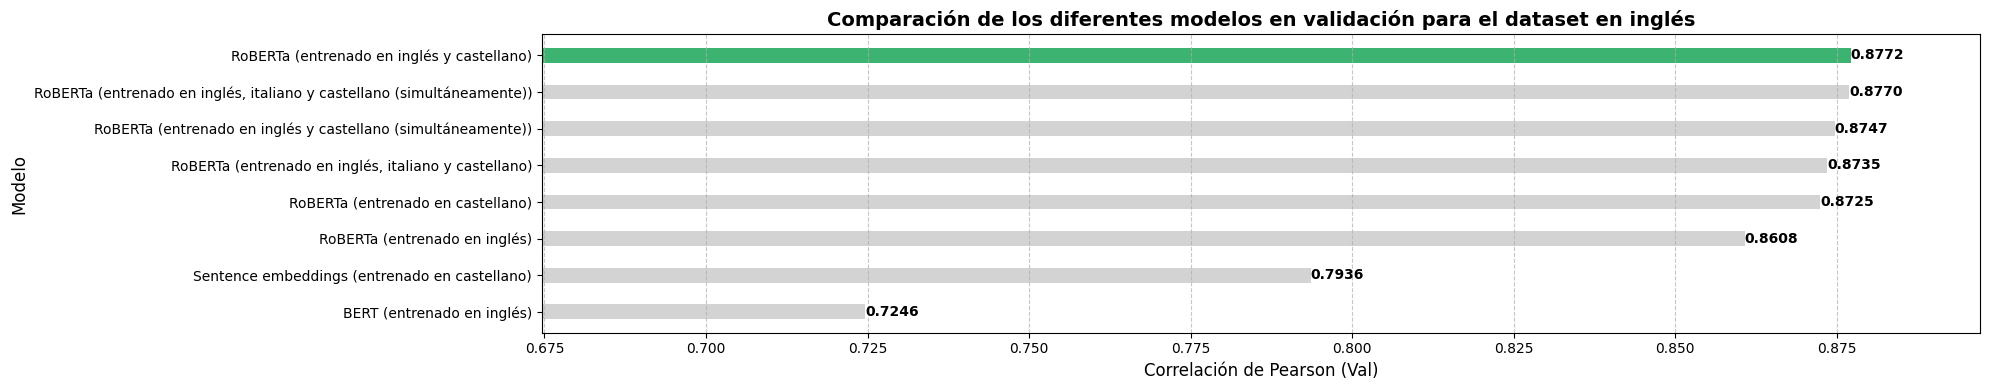

Gráfica guardada como 'grafica_resultados_val_ing.png'


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Recuperamos los datos (si existen)
if 'resultados_val_cast' in globals() and resultados_val_cast:
    df_plot = pd.DataFrame(resultados_val_cast)

    # Creamos una etiqueta legible para cada barra
    df_plot['Config'] = df_plot.apply(lambda x: f"{x['Modelo']}", axis=1)

    # Ordenamos de mejor a peor
    df_plot = df_plot.sort_values('Pearson (Val)', ascending=True)

    # 2. Configuración del Gráfico
    plt.figure(figsize=(20, 4))

    # Colores: Destacamos el mejor en verde, los demás en gris
    colores = ['lightgray'] * (len(df_plot) - 1) + ['mediumseagreen']

    barras = plt.barh(df_plot['Config'], df_plot['Pearson (Val)'], color=colores,height=0.4)

    # 3. Estética
    plt.xlabel('Correlación de Pearson (Val)', fontsize=12)
    plt.ylabel('Modelo', fontsize=12)
    plt.title('Comparación de los diferentes modelos en validación para el dataset en inglés', fontsize=14, fontweight='bold')

    # Ajustamos los límites del eje X para que se aprecien las diferencias
    # (Como todos estarán cerca de 0.8, empezamos en 0.7 para hacer "zoom")
    min_score = df_plot['Pearson (Val)'].min()
    plt.xlim(min_score - 0.05, df_plot['Pearson (Val)'].max() + 0.02)

    # 4. Añadir el valor exacto en cada barra
    for barra in barras:
        width = barra.get_width()
        plt.text(width, barra.get_y() + barra.get_height()/2,
                 f'{width:.4f}',
                 ha='left', va='center', fontweight='bold') # Removed padding=5

    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Mostrar y Guardar (para el informe)
    plt.savefig("grafica_resultados_val_ing.png", dpi=300) # Se guarda en la carpeta de archivos
    plt.show()
    print("Gráfica guardada como 'grafica_resultados_val_ing.png'")

else:
    print("No hay resultados en memoria. Ejecuta primero la validación.")

## Pruebas finales sobre el conjunto de test y comparación de los modelos

### Z1: Similitud semántica no supervisada

#### Representación basada en n-grams

In [11]:
model_path = "/content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z1_ngrams/vectorizer.pkl"

# Cargar el modelo guardado
loaded_vectorizer = joblib.load(model_path)
print(f"Modelo de ngrams cargado desde: {model_path}")

# Generar vectores para el conjunto de TEST
# IMPORTANTE: Usamos .transform(), NO .fit() o .fit_transform()
# Esto usa el vocabulario que el modelo ya aprendió durante el entrenamiento.
vectores_test_s1 = loaded_vectorizer.transform(test_df['sentence1'])
vectores_test_s2 = loaded_vectorizer.transform(test_df['sentence2'])

# Calcular Similitud del Coseno
# cosine_similarity devuelve una matriz, tomamos la diagonal para comparar pares (s1[0] con s2[0], s1[1] con s2[1]...)
similitudes_test = cosine_similarity(vectores_test_s1, vectores_test_s2).diagonal()

# Evaluar con Pearson
# Los scores originales están en el rango 0-5. La correlación de Pearson no se ve afectada por la escala,
# así que podemos comparar directamente nuestras similitudes (0-1) con los scores (0-5).
referencias_test = test_df['score']
pearson_score = pearson_metric.compute(predictions=similitudes_test, references=referencias_test)

nota = pearson_score['pearsonr']

print(f"RESULTADO FINAL EN TEST PARA EL DATASET EN INGLÉS (Z1 - N-Gramas)")
print(f"Correlación de Pearson: {nota:.4f}")

Modelo de ngrams cargado desde: /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z1_ngrams/vectorizer.pkl
RESULTADO FINAL EN TEST PARA EL DATASET EN INGLÉS (Z1 - N-Gramas)
Correlación de Pearson: 0.5428


#### Representación basada en sentence embeddings

In [12]:
path_z1_st = "/content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z1_sentence_transformer"

# Cargar el modelo
model_st = SentenceTransformer(path_z1_st)
print(f"Modelo de sentence embeddings para el inglés cargado desde {path_z1_st}")

# Generar Embeddings para el conjunto de TEST
# (Asumimos que ya tienes cargado el dataframe 'df_test' de la celda anterior.
#  Si no, vuelve a ejecutar la carga del dataset test con pandas).

# .encode() convierte automáticamente la lista de textos a vectores (numpy arrays)
embeddings_s1 = model_st.encode(test_df['sentence1'].tolist(), show_progress_bar=True)
embeddings_s2 = model_st.encode(test_df['sentence2'].tolist(), show_progress_bar=True)

# Calcular Similitud del Coseno
# Igual que antes, usamos la diagonal para comparar pares correspondientes
similitudes_test_st = cosine_similarity(embeddings_s1, embeddings_s2).diagonal()

# Evaluar con Pearson
# La métrica de Pearson evalúa la correlación lineal, por lo que no importa que
# tus predicciones vayan de -1 a 1 y los labels de 0 a 5.
pearson_score_st = pearson_metric.compute(predictions=similitudes_test_st, references=test_df['score'])

nota = pearson_score_st['pearsonr']

print(f"RESULTADO FINAL EN TEST PARA EL DATASET EN INGLÉS (Z1 - Sentence Transformer)")
print(f"Correlación de Pearson: {nota:.4f}")

Modelo de sentence embeddings para el inglés cargado desde /content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z1_sentence_transformer


Batches:   0%|          | 0/44 [00:00<?, ?it/s]

Batches:   0%|          | 0/44 [00:00<?, ?it/s]

RESULTADO FINAL EN TEST PARA EL DATASET EN INGLÉS (Z1 - Sentence Transformer)
Correlación de Pearson: 0.8274


### Z2: Fine-Tunning Supervisado

In [13]:
resultados_ing = []
resultados_cast = []

#### Modelo BERT

In [14]:
path_z2_bert = "/content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z2_finetunning_bert"
# Load the model and tokenizer from the final output_dir for evaluation
model_z2_bert = AutoModelForSequenceClassification.from_pretrained(path_z2_bert)
tokenizer_z2_bert = AutoTokenizer.from_pretrained(path_z2_bert)

#  Preprocesar datos en Español
# Usamos el tokenizador cargado (el de Z2 Bert) para procesar el texto en español.
def preprocess_function(examples):
    return tokenizer_z2_bert(examples['sentence1'], examples['sentence2'], truncation=True, max_length=128)

encoded_dataset_ing = dataset.map(preprocess_function, batched=True)
encoded_dataset_cast = dataset_cast.map(preprocess_function, batched=True)

# Renombramos la columna 'similarity_score' a 'labels'
encoded_dataset_ing = encoded_dataset_ing.rename_column("score", "labels")
encoded_dataset_ing.set_format("torch") # Ensure format is set after renaming
encoded_dataset_cast = encoded_dataset_cast.rename_column("similarity_score", "labels")
encoded_dataset_cast.set_format("torch") # Ensure format is set after renaming

# Configurar Evaluador
pearson_metric = evaluate.load("pearsonr")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    # En regresión, las predicciones pueden tener forma (N, 1), aplanamos a (N,)
    predictions = predictions[:, 0]
    return pearson_metric.compute(predictions=predictions, references=labels)

# Create minimal TrainingArguments for evaluation to ensure metrics are computed
eval_args = TrainingArguments(
    output_dir="/tmp/eval_output_z3", # Temporary directory for evaluation logs
    do_train=False,
    do_eval=True,
    per_device_eval_batch_size=32, # Use a reasonable batch size for evaluation
    metric_for_best_model="pearsonr", # Explicitly state the metric
    report_to="none", # Disable reporting to external services like Weights & Biases
    dataloader_num_workers=0,
    dataloader_pin_memory=False
)

trainer_eval = Trainer(
    model=model_z2_bert,
    args=eval_args, # Pass the evaluation arguments
    tokenizer=tokenizer_z2_bert,
    compute_metrics=compute_metrics,
)

# Ejecutar Evaluación y Predicciones
predicciones_ing = trainer_eval.predict(encoded_dataset_ing['test']).predictions[:, 0]
predicciones_cast = trainer_eval.predict(encoded_dataset_cast['test']).predictions[:, 0]

referencias_ing = encoded_dataset_ing['test']['labels']
computed_pearson_score_ing = pearson_metric.compute(predictions=predicciones_ing, references=referencias_ing)
referencias_cast = encoded_dataset_cast['test']['labels']
computed_pearson_score_cast = pearson_metric.compute(predictions=predicciones_cast, references=referencias_cast)

nota_ing = computed_pearson_score_ing['pearsonr']
nota_cast = computed_pearson_score_cast['pearsonr']

print(f"RESULTADO FINAL EN TEST PARA EL CONJUNTO EN INGLÉS (Z2 - BERT entrenado en inglés)")
print(f" Correlación de Pearson: {nota_ing:.4f}")
resultados_ing.append({"Modelo": "Z2-BERT (entrenado en inglés)",  "Pearson (Test)": nota_ing})

print(f"RESULTADO FINAL EN TEST PARA EL CONJUNTO EN CASTELLANO (Z2 - BERT entrenado en inglés)")
print(f" Correlación de Pearson: {nota_cast:.4f}")
resultados_cast.append({"Modelo": "Z2-BERT (entrenado en inglés)",  "Pearson (Test)": nota_cast})

Map:   0%|          | 0/5749 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1379 [00:00<?, ? examples/s]

Map:   0%|          | 0/1379 [00:00<?, ? examples/s]

Map:   0%|          | 0/5749 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

/tmp/ipython-input-1309206523.py:41: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_eval = Trainer(


RESULTADO FINAL EN TEST PARA EL CONJUNTO EN INGLÉS (Z2 - BERT entrenado en inglés)
 Correlación de Pearson: 0.8597
RESULTADO FINAL EN TEST PARA EL CONJUNTO EN CASTELLANO (Z2 - BERT entrenado en inglés)
 Correlación de Pearson: 0.6447


#### Modelo xmlRoBERTa

In [15]:
path_z2_roberta_ing = "/content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z2_finetunning_roberta"
# Load the model and tokenizer from the final output_dir for evaluation
model_z2_roberta_ing = AutoModelForSequenceClassification.from_pretrained(path_z2_roberta_ing)
tokenizer_z2_roberta_ing = AutoTokenizer.from_pretrained(path_z2_roberta_ing)

#  Preprocesar datos en Español
# Usamos el tokenizador cargado (el de Z2 Bert) para procesar el texto en español.
def preprocess_function(examples):
    return tokenizer_z2_roberta_ing(examples['sentence1'], examples['sentence2'], truncation=True, max_length=128)

encoded_dataset_ing = dataset.map(preprocess_function, batched=True)
encoded_dataset_cast = dataset_cast.map(preprocess_function, batched=True)

# Renombramos la columna 'similarity_score' a 'labels'
encoded_dataset_ing = encoded_dataset_ing.rename_column("score", "labels")
encoded_dataset_ing.set_format("torch") # Ensure format is set after renaming
encoded_dataset_cast = encoded_dataset_cast.rename_column("similarity_score", "labels")
encoded_dataset_cast.set_format("torch") # Ensure format is set after renaming

# Configurar Evaluador
pearson_metric = evaluate.load("pearsonr")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    # En regresión, las predicciones pueden tener forma (N, 1), aplanamos a (N,)
    predictions = predictions[:, 0]
    return pearson_metric.compute(predictions=predictions, references=labels)

# Create minimal TrainingArguments for evaluation to ensure metrics are computed
eval_args = TrainingArguments(
    output_dir="/tmp/eval_output_z3", # Temporary directory for evaluation logs
    do_train=False,
    do_eval=True,
    per_device_eval_batch_size=32, # Use a reasonable batch size for evaluation
    metric_for_best_model="pearsonr", # Explicitly state the metric
    report_to="none", # Disable reporting to external services like Weights & Biases
    dataloader_num_workers=0,
    dataloader_pin_memory=False
)

trainer_eval = Trainer(
    model=model_z2_roberta_ing,
    args=eval_args, # Pass the evaluation arguments
    tokenizer=tokenizer_z2_roberta_ing,
    compute_metrics=compute_metrics,
)

# Ejecutar Evaluación y Predicciones
predicciones_ing = trainer_eval.predict(encoded_dataset_ing['test']).predictions[:, 0]
predicciones_cast = trainer_eval.predict(encoded_dataset_cast['test']).predictions[:, 0]

referencias_ing = encoded_dataset_ing['test']['labels']
computed_pearson_score_ing = pearson_metric.compute(predictions=predicciones_ing, references=referencias_ing)
referencias_cast = encoded_dataset_cast['test']['labels']
computed_pearson_score_cast = pearson_metric.compute(predictions=predicciones_cast, references=referencias_cast)

nota_ing = computed_pearson_score_ing['pearsonr']
nota_cast = computed_pearson_score_cast['pearsonr']

print(f"RESULTADO FINAL EN TEST PARA EL CONJUNTO EN INGLÉS (Z2 - RoBERTa entrenado en inglés)")
print(f" Correlación de Pearson: {nota_ing:.4f}")
resultados_ing.append({"Modelo": "Z2-RoBERTa (entrenado en inglés)",  "Pearson (Test)": nota_ing})

print(f"RESULTADO FINAL EN TEST PARA EL CONJUNTO EN CASTELLANO (Z2 - RoBERTa entrenado en inglés)")
print(f" Correlación de Pearson: {nota_cast:.4f}")
resultados_cast.append({"Modelo": "Z2-RoBERTa (entrenado en inglés)",  "Pearson (Test)": nota_cast})

Map:   0%|          | 0/5749 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1379 [00:00<?, ? examples/s]

Map:   0%|          | 0/1379 [00:00<?, ? examples/s]

Map:   0%|          | 0/5749 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

/tmp/ipython-input-2392549584.py:41: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_eval = Trainer(


RESULTADO FINAL EN TEST PARA EL CONJUNTO EN INGLÉS (Z2 - RoBERTa entrenado en inglés)
 Correlación de Pearson: 0.8501
RESULTADO FINAL EN TEST PARA EL CONJUNTO EN CASTELLANO (Z2 - RoBERTa entrenado en inglés)
 Correlación de Pearson: 0.8255


In [16]:
path_z3_roberta_finetuned_cast = f"{base_path}/z3_finetunning_roberta_cast" # Correct path to the RoBERTa fine-tuned on Spanish data

# Load the model and tokenizer from the fine-tuned checkpoint for evaluation
model_z3_roberta_cast = AutoModelForSequenceClassification.from_pretrained(path_z3_roberta_finetuned_cast)
tokenizer_z3_roberta_cast = AutoTokenizer.from_pretrained(path_z3_roberta_finetuned_cast)

#  Preprocesar datos en Español
# Usamos el tokenizador cargado (el de Z2 Bert) para procesar el texto en español.
def preprocess_function(examples):
    return tokenizer_z3_roberta_cast(examples['sentence1'], examples['sentence2'], truncation=True, max_length=128)

encoded_dataset_ing = dataset.map(preprocess_function, batched=True)
encoded_dataset_cast = dataset_cast.map(preprocess_function, batched=True)

# Renombramos la columna 'similarity_score' a 'labels'
encoded_dataset_ing = encoded_dataset_ing.rename_column("score", "labels")
encoded_dataset_ing.set_format("torch") # Ensure format is set after renaming
encoded_dataset_cast = encoded_dataset_cast.rename_column("similarity_score", "labels")
encoded_dataset_cast.set_format("torch") # Ensure format is set after renaming

# Configurar Evaluador
pearson_metric = evaluate.load("pearsonr")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    # En regresión, las predicciones pueden tener forma (N, 1), aplanamos a (N,)
    predictions = predictions[:, 0]
    return pearson_metric.compute(predictions=predictions, references=labels)

# Create minimal TrainingArguments for evaluation to ensure metrics are computed
eval_args = TrainingArguments(
    output_dir="/tmp/eval_output_z3", # Temporary directory for evaluation logs
    do_train=False,
    do_eval=True,
    per_device_eval_batch_size=32, # Use a reasonable batch size for evaluation
    metric_for_best_model="pearsonr", # Explicitly state the metric
    report_to="none", # Disable reporting to external services like Weights & Biases
    dataloader_num_workers=0,
    dataloader_pin_memory=False
)

trainer_eval = Trainer(
    model=model_z3_roberta_cast,
    args=eval_args, # Pass the evaluation arguments
    tokenizer=tokenizer_z3_roberta_cast,
    compute_metrics=compute_metrics,
)

# Ejecutar Evaluación y Predicciones
predicciones_ing = trainer_eval.predict(encoded_dataset_ing['test']).predictions[:, 0]
predicciones_cast = trainer_eval.predict(encoded_dataset_cast['test']).predictions[:, 0]

referencias_ing = encoded_dataset_ing['test']['labels']
computed_pearson_score_ing = pearson_metric.compute(predictions=predicciones_ing, references=referencias_ing)
referencias_cast = encoded_dataset_cast['test']['labels']
computed_pearson_score_cast = pearson_metric.compute(predictions=predicciones_cast, references=referencias_cast)

nota_ing = computed_pearson_score_ing['pearsonr']
nota_cast = computed_pearson_score_cast['pearsonr']

print(f"RESULTADO FINAL EN TEST PARA EL CONJUNTO EN INGLÉS (Z3 - RoBERTa entrenado en castellano)")
print(f" Correlación de Pearson: {nota_ing:.4f}")
resultados_ing.append({"Modelo": "Z3-RoBERTa (entrenado en castellano)",  "Pearson (Test)": nota_ing})

print(f"RESULTADO FINAL EN TEST PARA EL CONJUNTO EN CASTELLANO (Z2 - RoBERTa entrenado en castellano)")
print(f" Correlación de Pearson: {nota_cast:.4f}")
resultados_cast.append({"Modelo": "Z3-RoBERTa (entrenado en castellano)",  "Pearson (Test)": nota_cast})

Map:   0%|          | 0/5749 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1379 [00:00<?, ? examples/s]

Map:   0%|          | 0/1379 [00:00<?, ? examples/s]

Map:   0%|          | 0/5749 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

/tmp/ipython-input-785828228.py:42: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_eval = Trainer(


RESULTADO FINAL EN TEST PARA EL CONJUNTO EN INGLÉS (Z3 - RoBERTa entrenado en castellano)
 Correlación de Pearson: 0.8405
RESULTADO FINAL EN TEST PARA EL CONJUNTO EN CASTELLANO (Z2 - RoBERTa entrenado en castellano)
 Correlación de Pearson: 0.8277


In [17]:
path_z3_roberta_ingcast = f"{base_path}/z3_finetunning_roberta_ingcast"
# Load the model and tokenizer from the final output_dir for evaluation
model_z3_roberta_ingcast = AutoModelForSequenceClassification.from_pretrained(path_z3_roberta_ingcast)
tokenizer_z3_roberta_ingcast = AutoTokenizer.from_pretrained(path_z3_roberta_ingcast)

#  Preprocesar datos en Español
# Usamos el tokenizador cargado (el de Z2 Bert) para procesar el texto en español.
def preprocess_function(examples):
    return tokenizer_z3_roberta_ingcast(examples['sentence1'], examples['sentence2'], truncation=True, max_length=128)

encoded_dataset_ing = dataset.map(preprocess_function, batched=True)
encoded_dataset_cast = dataset_cast.map(preprocess_function, batched=True)

# Renombramos la columna 'similarity_score' a 'labels'
encoded_dataset_ing = encoded_dataset_ing.rename_column("score", "labels")
encoded_dataset_ing.set_format("torch") # Ensure format is set after renaming
encoded_dataset_cast = encoded_dataset_cast.rename_column("similarity_score", "labels")
encoded_dataset_cast.set_format("torch") # Ensure format is set after renaming

# Configurar Evaluador
pearson_metric = evaluate.load("pearsonr")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    # En regresión, las predicciones pueden tener forma (N, 1), aplanamos a (N,)
    predictions = predictions[:, 0]
    return pearson_metric.compute(predictions=predictions, references=labels)

# Create minimal TrainingArguments for evaluation to ensure metrics are computed
eval_args = TrainingArguments(
    output_dir="/tmp/eval_output_z3", # Temporary directory for evaluation logs
    do_train=False,
    do_eval=True,
    per_device_eval_batch_size=32, # Use a reasonable batch size for evaluation
    metric_for_best_model="pearsonr", # Explicitly state the metric
    report_to="none", # Disable reporting to external services like Weights & Biases
    dataloader_num_workers=0,
    dataloader_pin_memory=False
)

trainer_eval = Trainer(
    model=model_z3_roberta_ingcast,
    args=eval_args, # Pass the evaluation arguments
    tokenizer=tokenizer_z3_roberta_ingcast,
    compute_metrics=compute_metrics,
)

# Ejecutar Evaluación y Predicciones
predicciones_ing = trainer_eval.predict(encoded_dataset_ing['test']).predictions[:, 0]
predicciones_cast = trainer_eval.predict(encoded_dataset_cast['test']).predictions[:, 0]

referencias_ing = encoded_dataset_ing['test']['labels']
computed_pearson_score_ing = pearson_metric.compute(predictions=predicciones_ing, references=referencias_ing)
referencias_cast = encoded_dataset_cast['test']['labels']
computed_pearson_score_cast = pearson_metric.compute(predictions=predicciones_cast, references=referencias_cast)

nota_ing = computed_pearson_score_ing['pearsonr']
nota_cast = computed_pearson_score_cast['pearsonr']

print(f"RESULTADO FINAL EN TEST PARA EL CONJUNTO EN INGLÉS (Z3 - RoBERTa entrenado en inglés y en castellano)")
print(f" Correlación de Pearson: {nota_ing:.4f}")
resultados_ing.append({"Modelo": "Z3-RoBERTa (entrenado en inglés y castellano)",  "Pearson (Test)": nota_ing})

print(f"RESULTADO FINAL EN TEST PARA EL CONJUNTO EN CASTELLANO (Z3 - RoBERTa entrenado en inglés y en castellano)")
print(f" Correlación de Pearson: {nota_cast:.4f}")
resultados_cast.append({"Modelo": "Z3-RoBERTa (entrenado en inglés y castellano)",  "Pearson (Test)": nota_cast})

Map:   0%|          | 0/5749 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1379 [00:00<?, ? examples/s]

Map:   0%|          | 0/1379 [00:00<?, ? examples/s]

Map:   0%|          | 0/5749 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

/tmp/ipython-input-2554654490.py:41: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_eval = Trainer(


RESULTADO FINAL EN TEST PARA EL CONJUNTO EN INGLÉS (Z3 - RoBERTa entrenado en inglés y en castellano)
 Correlación de Pearson: 0.8473
RESULTADO FINAL EN TEST PARA EL CONJUNTO EN CASTELLANO (Z3 - RoBERTa entrenado en inglés y en castellano)
 Correlación de Pearson: 0.8340


In [18]:
path_z3_roberta_ingcastit = f"{base_path}/z3_finetunning_roberta_ingcastit"
# Load the model and tokenizer from the final output_dir for evaluation
model_z3_roberta_ingcastit = AutoModelForSequenceClassification.from_pretrained(path_z3_roberta_ingcastit)
tokenizer_z3_roberta_ingcastit = AutoTokenizer.from_pretrained(path_z3_roberta_ingcastit)

#  Preprocesar datos en Español
# Usamos el tokenizador cargado (el de Z2 Bert) para procesar el texto en español.
def preprocess_function(examples):
    return tokenizer_z3_roberta_ingcastit(examples['sentence1'], examples['sentence2'], truncation=True, max_length=128)

encoded_dataset_ing = dataset.map(preprocess_function, batched=True)
encoded_dataset_cast = dataset_cast.map(preprocess_function, batched=True)

# Renombramos la columna 'similarity_score' a 'labels'
encoded_dataset_ing = encoded_dataset_ing.rename_column("score", "labels")
encoded_dataset_ing.set_format("torch") # Ensure format is set after renaming
encoded_dataset_cast = encoded_dataset_cast.rename_column("similarity_score", "labels")
encoded_dataset_cast.set_format("torch") # Ensure format is set after renaming

# Configurar Evaluador
pearson_metric = evaluate.load("pearsonr")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    # En regresión, las predicciones pueden tener forma (N, 1), aplanamos a (N,)
    predictions = predictions[:, 0]
    return pearson_metric.compute(predictions=predictions, references=labels)

# Create minimal TrainingArguments for evaluation to ensure metrics are computed
eval_args = TrainingArguments(
    output_dir="/tmp/eval_output_z3", # Temporary directory for evaluation logs
    do_train=False,
    do_eval=True,
    per_device_eval_batch_size=32, # Use a reasonable batch size for evaluation
    metric_for_best_model="pearsonr", # Explicitly state the metric
    report_to="none", # Disable reporting to external services like Weights & Biases
    dataloader_num_workers=0,
    dataloader_pin_memory=False
)

trainer_eval = Trainer(
    model=model_z3_roberta_ingcastit,
    args=eval_args, # Pass the evaluation arguments
    tokenizer=tokenizer_z3_roberta_ingcastit,
    compute_metrics=compute_metrics,
)

# Ejecutar Evaluación y Predicciones
predicciones_ing = trainer_eval.predict(encoded_dataset_ing['test']).predictions[:, 0]
predicciones_cast = trainer_eval.predict(encoded_dataset_cast['test']).predictions[:, 0]

referencias_ing = encoded_dataset_ing['test']['labels']
computed_pearson_score_ing = pearson_metric.compute(predictions=predicciones_ing, references=referencias_ing)
referencias_cast = encoded_dataset_cast['test']['labels']
computed_pearson_score_cast = pearson_metric.compute(predictions=predicciones_cast, references=referencias_cast)

nota_ing = computed_pearson_score_ing['pearsonr']
nota_cast = computed_pearson_score_cast['pearsonr']

print(f"RESULTADO FINAL EN TEST PARA EL CONJUNTO EN INGLÉS (Z3 - RoBERTa entrenado en inglés, italiano y castellano)")
print(f" Correlación de Pearson: {nota_ing:.4f}")
resultados_ing.append({"Modelo": "Z3-RoBERTa (entrenado en inglés, italiano y castellano)",  "Pearson (Test)": nota_ing})

print(f"RESULTADO FINAL EN TEST PARA EL CONJUNTO EN CASTELLANO (Z3 - RoBERTa entrenado en inglés, italiano y castellano)")
print(f" Correlación de Pearson: {nota_cast:.4f}")
resultados_cast.append({"Modelo": "Z3-RoBERTa (entrenado en inglés, italiano y castellano)",  "Pearson (Test)": nota_cast})

The tokenizer you are loading from '/content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z3_finetunning_roberta_ingcastit' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Map:   0%|          | 0/5749 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1379 [00:00<?, ? examples/s]

Map:   0%|          | 0/1379 [00:00<?, ? examples/s]

Map:   0%|          | 0/5749 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

/tmp/ipython-input-2772278567.py:41: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_eval = Trainer(


RESULTADO FINAL EN TEST PARA EL CONJUNTO EN INGLÉS (Z3 - RoBERTa entrenado en inglés, italiano y castellano)
 Correlación de Pearson: 0.8490
RESULTADO FINAL EN TEST PARA EL CONJUNTO EN CASTELLANO (Z3 - RoBERTa entrenado en inglés, italiano y castellano)
 Correlación de Pearson: 0.8323


In [19]:
path_z3_roberta_joint2 = f"{base_path}/z3_finetunning_roberta_joint2"
# Load the model and tokenizer from the final output_dir for evaluation
model_z3_roberta_joint2 = AutoModelForSequenceClassification.from_pretrained(path_z3_roberta_joint2)
tokenizer_z3_roberta_joint2 = AutoTokenizer.from_pretrained(path_z3_roberta_joint2)

#  Preprocesar datos en Español
# Usamos el tokenizador cargado (el de Z2 Bert) para procesar el texto en español.
def preprocess_function(examples):
    return tokenizer_z3_roberta_joint2(examples['sentence1'], examples['sentence2'], truncation=True, max_length=128)

encoded_dataset_ing = dataset.map(preprocess_function, batched=True)
encoded_dataset_cast = dataset_cast.map(preprocess_function, batched=True)

# Renombramos la columna 'similarity_score' a 'labels'
encoded_dataset_ing = encoded_dataset_ing.rename_column("score", "labels")
encoded_dataset_ing.set_format("torch") # Ensure format is set after renaming
encoded_dataset_cast = encoded_dataset_cast.rename_column("similarity_score", "labels")
encoded_dataset_cast.set_format("torch") # Ensure format is set after renaming

# Configurar Evaluador
pearson_metric = evaluate.load("pearsonr")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    # En regresión, las predicciones pueden tener forma (N, 1), aplanamos a (N,)
    predictions = predictions[:, 0]
    return pearson_metric.compute(predictions=predictions, references=labels)

# Create minimal TrainingArguments for evaluation to ensure metrics are computed
eval_args = TrainingArguments(
    output_dir="/tmp/eval_output_z3", # Temporary directory for evaluation logs
    do_train=False,
    do_eval=True,
    per_device_eval_batch_size=32, # Use a reasonable batch size for evaluation
    metric_for_best_model="pearsonr", # Explicitly state the metric
    report_to="none", # Disable reporting to external services like Weights & Biases
    dataloader_num_workers=0,
    dataloader_pin_memory=False
)

trainer_eval = Trainer(
    model=model_z3_roberta_joint2,
    args=eval_args, # Pass the evaluation arguments
    tokenizer=tokenizer_z3_roberta_joint2,
    compute_metrics=compute_metrics,
)

# Ejecutar Evaluación y Predicciones
predicciones_ing = trainer_eval.predict(encoded_dataset_ing['test']).predictions[:, 0]
predicciones_cast = trainer_eval.predict(encoded_dataset_cast['test']).predictions[:, 0]

referencias_ing = encoded_dataset_ing['test']['labels']
computed_pearson_score_ing = pearson_metric.compute(predictions=predicciones_ing, references=referencias_ing)
referencias_cast = encoded_dataset_cast['test']['labels']
computed_pearson_score_cast = pearson_metric.compute(predictions=predicciones_cast, references=referencias_cast)

nota_ing = computed_pearson_score_ing['pearsonr']
nota_cast = computed_pearson_score_cast['pearsonr']

print(f"RESULTADO FINAL EN TEST PARA EL CONJUNTO EN INGLÉS (Z3 - RoBERTa entrenado en inglés y castellano (simultáneamente))")
print(f" Correlación de Pearson: {nota_ing:.4f}")
resultados_ing.append({"Modelo": "Z3-RoBERTa (entrenado en inglés y castellano (simultáneamente))",  "Pearson (Test)": nota_ing})

print(f"RESULTADO FINAL EN TEST PARA EL CONJUNTO EN CASTELLANO (Z3 - RoBERTa entrenado en inglés y castellano (simultáneamente))")
print(f" Correlación de Pearson: {nota_cast:.4f}")
resultados_cast.append({"Modelo": "Z3-RoBERTa (entrenado en inglés y castellano (simultáneamente))",  "Pearson (Test)": nota_cast})

The tokenizer you are loading from '/content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z3_finetunning_roberta_joint2' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Map:   0%|          | 0/5749 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1379 [00:00<?, ? examples/s]

Map:   0%|          | 0/1379 [00:00<?, ? examples/s]

Map:   0%|          | 0/5749 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

/tmp/ipython-input-3331885244.py:41: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_eval = Trainer(


RESULTADO FINAL EN TEST PARA EL CONJUNTO EN INGLÉS (Z3 - RoBERTa entrenado en inglés y castellano (simultáneamente))
 Correlación de Pearson: 0.8535
RESULTADO FINAL EN TEST PARA EL CONJUNTO EN CASTELLANO (Z3 - RoBERTa entrenado en inglés y castellano (simultáneamente))
 Correlación de Pearson: 0.8270


In [20]:
path_z3_roberta_joint = f"{base_path}/z3_finetunning_roberta_joint"
# Load the model and tokenizer from the final output_dir for evaluation
model_z3_roberta_joint = AutoModelForSequenceClassification.from_pretrained(path_z3_roberta_joint)
tokenizer_z3_roberta_joint = AutoTokenizer.from_pretrained(path_z3_roberta_joint)

#  Preprocesar datos en Español
# Usamos el tokenizador cargado (el de Z2 Bert) para procesar el texto en español.
def preprocess_function(examples):
    return tokenizer_z3_roberta_joint(examples['sentence1'], examples['sentence2'], truncation=True, max_length=128)

encoded_dataset_ing = dataset.map(preprocess_function, batched=True)
encoded_dataset_cast = dataset_cast.map(preprocess_function, batched=True)

# Renombramos la columna 'similarity_score' a 'labels'
encoded_dataset_ing = encoded_dataset_ing.rename_column("score", "labels")
encoded_dataset_ing.set_format("torch") # Ensure format is set after renaming
encoded_dataset_cast = encoded_dataset_cast.rename_column("similarity_score", "labels")
encoded_dataset_cast.set_format("torch") # Ensure format is set after renaming

# Configurar Evaluador
pearson_metric = evaluate.load("pearsonr")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    # En regresión, las predicciones pueden tener forma (N, 1), aplanamos a (N,)
    predictions = predictions[:, 0]
    return pearson_metric.compute(predictions=predictions, references=labels)

# Create minimal TrainingArguments for evaluation to ensure metrics are computed
eval_args = TrainingArguments(
    output_dir="/tmp/eval_output_z3", # Temporary directory for evaluation logs
    do_train=False,
    do_eval=True,
    per_device_eval_batch_size=32, # Use a reasonable batch size for evaluation
    metric_for_best_model="pearsonr", # Explicitly state the metric
    report_to="none", # Disable reporting to external services like Weights & Biases
    dataloader_num_workers=0,
    dataloader_pin_memory=False
)

trainer_eval = Trainer(
    model=model_z3_roberta_joint,
    args=eval_args, # Pass the evaluation arguments
    tokenizer=tokenizer_z3_roberta_joint,
    compute_metrics=compute_metrics,
)

# Ejecutar Evaluación y Predicciones
predicciones_ing = trainer_eval.predict(encoded_dataset_ing['test']).predictions[:, 0]
predicciones_cast = trainer_eval.predict(encoded_dataset_cast['test']).predictions[:, 0]

referencias_ing = encoded_dataset_ing['test']['labels']
computed_pearson_score_ing = pearson_metric.compute(predictions=predicciones_ing, references=referencias_ing)
referencias_cast = encoded_dataset_cast['test']['labels']
computed_pearson_score_cast = pearson_metric.compute(predictions=predicciones_cast, references=referencias_cast)

nota_ing = computed_pearson_score_ing['pearsonr']
nota_cast = computed_pearson_score_cast['pearsonr']

print(f"RESULTADO FINAL EN TEST PARA EL CONJUNTO EN INGLÉS (Z3 - RoBERTa entrenado en inglés, italiano y castellano (simultáneamente))")
print(f" Correlación de Pearson: {nota_ing:.4f}")
resultados_ing.append({"Modelo": "Z3-RoBERTa (entrenado en inglés, italiano y castellano (simultáneamente))",  "Pearson (Test)": nota_ing})

print(f"RESULTADO FINAL EN TEST PARA EL CONJUNTO EN CASTELLANO (Z3 - RoBERTa entrenado en inglés, italiano y castellano (simultáneamente))")
print(f" Correlación de Pearson: {nota_cast:.4f}")
resultados_cast.append({"Modelo": "Z3-RoBERTa (entrenado en inglés, italiano y castellano (simultáneamente))",  "Pearson (Test)": nota_cast})

The tokenizer you are loading from '/content/drive/MyDrive/Colab Notebooks/PLN/proyectoSTS/modelos/z3_finetunning_roberta_joint' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Map:   0%|          | 0/5749 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1379 [00:00<?, ? examples/s]

Map:   0%|          | 0/1379 [00:00<?, ? examples/s]

Map:   0%|          | 0/5749 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

/tmp/ipython-input-1013609612.py:41: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_eval = Trainer(


RESULTADO FINAL EN TEST PARA EL CONJUNTO EN INGLÉS (Z3 - RoBERTa entrenado en inglés, italiano y castellano (simultáneamente))
 Correlación de Pearson: 0.8591
RESULTADO FINAL EN TEST PARA EL CONJUNTO EN CASTELLANO (Z3 - RoBERTa entrenado en inglés, italiano y castellano (simultáneamente))
 Correlación de Pearson: 0.8345


#### Gráficas

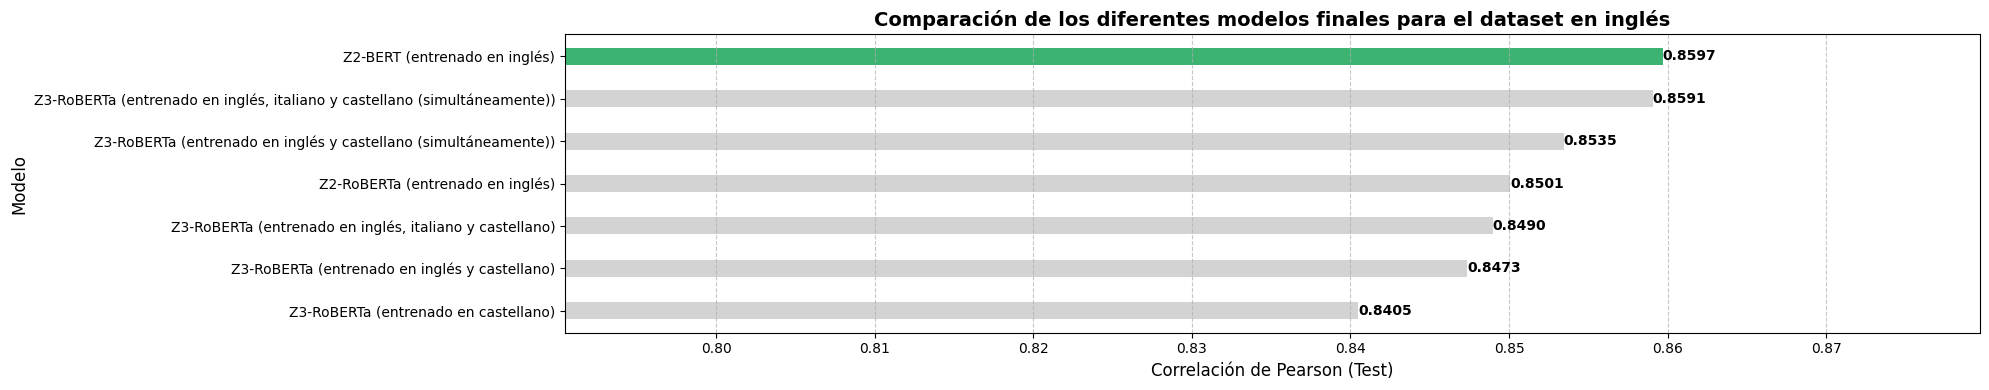

Gráfica guardada como 'grafica_resultados_finales_ing.png'


In [21]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Recuperamos los datos (si existen)
if 'resultados_ing' in globals() and resultados_ing:
    df_plot = pd.DataFrame(resultados_ing)

    # Creamos una etiqueta legible para cada barra
    df_plot['Config'] = df_plot.apply(lambda x: f"{x['Modelo']}", axis=1)

    # Ordenamos de mejor a peor
    df_plot = df_plot.sort_values('Pearson (Test)', ascending=True)

    # 2. Configuración del Gráfico
    plt.figure(figsize=(20, 4))

    # Colores: Destacamos el mejor en verde, los demás en gris
    colores = ['lightgray'] * (len(df_plot) - 1) + ['mediumseagreen']

    barras = plt.barh(df_plot['Config'], df_plot['Pearson (Test)'], color=colores,height=0.4)

    # 3. Estética
    plt.xlabel('Correlación de Pearson (Test)', fontsize=12)
    plt.ylabel('Modelo', fontsize=12)
    plt.title('Comparación de los diferentes modelos finales para el dataset en inglés', fontsize=14, fontweight='bold')

    # Ajustamos los límites del eje X para que se aprecien las diferencias
    # (Como todos estarán cerca de 0.8, empezamos en 0.7 para hacer "zoom")
    min_score = df_plot['Pearson (Test)'].min()
    plt.xlim(min_score - 0.05, df_plot['Pearson (Test)'].max() + 0.02)

    # 4. Añadir el valor exacto en cada barra
    for barra in barras:
        width = barra.get_width()
        plt.text(width, barra.get_y() + barra.get_height()/2,
                 f'{width:.4f}',
                 ha='left', va='center', fontweight='bold') # Removed padding=5

    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Mostrar y Guardar (para el informe)
    plt.savefig("grafica_resultados_finales_ing.png", dpi=300) # Se guarda en la carpeta de archivos
    plt.show()
    print("Gráfica guardada como 'grafica_resultados_finales_ing.png'")

else:
    print("No hay resultados en memoria. Ejecuta primero el test.")

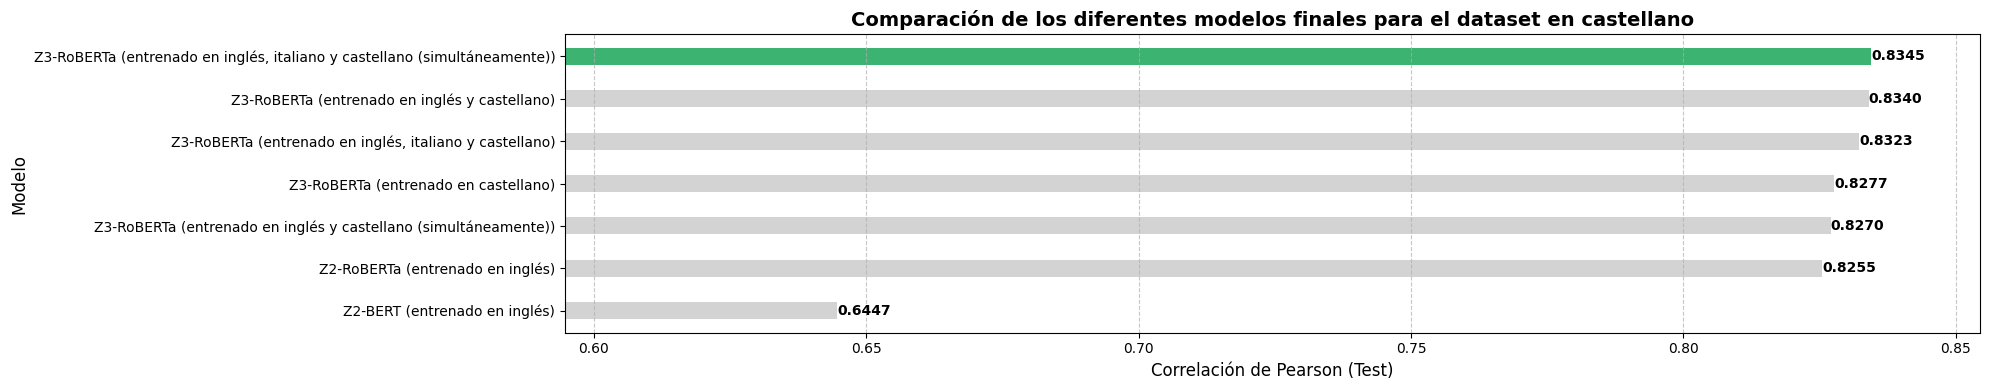

Gráfica guardada como 'grafica_resultados_finales_cast.png'


In [22]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Recuperamos los datos (si existen)
if 'resultados_cast' in globals() and resultados_cast:
    df_plot = pd.DataFrame(resultados_cast)

    # Creamos una etiqueta legible para cada barra
    df_plot['Config'] = df_plot.apply(lambda x: f"{x['Modelo']}", axis=1)

    # Ordenamos de mejor a peor
    df_plot = df_plot.sort_values('Pearson (Test)', ascending=True)

    # 2. Configuración del Gráfico
    plt.figure(figsize=(20, 4))

    # Colores: Destacamos el mejor en verde, los demás en gris
    colores = ['lightgray'] * (len(df_plot) - 1) + ['mediumseagreen']

    barras = plt.barh(df_plot['Config'], df_plot['Pearson (Test)'], color=colores,height=0.4)

    # 3. Estética
    plt.xlabel('Correlación de Pearson (Test)', fontsize=12)
    plt.ylabel('Modelo', fontsize=12)
    plt.title('Comparación de los diferentes modelos finales para el dataset en castellano', fontsize=14, fontweight='bold')

    # Ajustamos los límites del eje X para que se aprecien las diferencias
    # (Como todos estarán cerca de 0.8, empezamos en 0.7 para hacer "zoom")
    min_score = df_plot['Pearson (Test)'].min()
    plt.xlim(min_score - 0.05, df_plot['Pearson (Test)'].max() + 0.02)

    # 4. Añadir el valor exacto en cada barra
    for barra in barras:
        width = barra.get_width()
        plt.text(width, barra.get_y() + barra.get_height()/2,
                 f'{width:.4f}',
                 ha='left', va='center', fontweight='bold') # Removed padding=5

    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Mostrar y Guardar (para el informe)
    plt.savefig("grafica_resultados_finales_cast.png", dpi=300) # Se guarda en la carpeta de archivos
    plt.show()
    print("Gráfica guardada como 'grafica_resultados_finales_cast.png'")

else:
    print("No hay resultados en memoria. Ejecuta primero el test.")